In [1481]:
# df = pd.read_csv(r"processed_outputs\all_rudder_cases_combined.csv")
# df_prop_off = pd.read_csv(r"AERODYNAMIC_DATA_propoff\propOff.csv")
import os
import pandas as pd

df = pd.read_csv(r"CORRECTIONS_FINAL\results_propOn_FINAL\propOn_final.csv")
df_prop_off = pd.read_csv(r"CORRECTIONS_FINAL\results_propOff_FINAL\propOff_final.csv")
import matplotlib as mpl

# ── Global plot configuration ─────────────────────────────────────────────────
SAVE_RES = 300                  # DPI for saved figures (300 for publication, 150 for reports)
SHOW_TITLE = False          # True  → titles shown on all figures
                            # False → titles suppressed (clean for report)
AOA_COL = "AoA_FINAL"      # "AoA_FINAL" → corrected AoA on x-axis
                            # "AoA_round" → nominal tunnel set-point
PLOT_DIR = os.path.join(
    os.path.dirname(os.path.abspath("__file__")),
    "new_plot_images"
)                           # <notebook directory>/plot_images/
os.makedirs(PLOT_DIR, exist_ok=True)

mpl.rcParams['axes.labelsize']  = 12   # x/y axis label font size
mpl.rcParams['legend.fontsize'] = 10   # legend font size
mpl.rcParams['xtick.labelsize'] = 10   # tick number font size
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['axes.titlesize']  = 12   # title font size (when shown)

# ── Colour palette — uncomment one line to switch all plots ──────────────────
import seaborn as sns

# PALETTE = "colorblind"  # accessible, best for publication (default)
PALETTE = "muted"       # soft, good for reports
# PALETTE = "deep"        # richer / bolder
# PALETTE = "tab10"       # matplotlib default
#PALETTE = "colorblind"

sns.set_palette(PALETTE)          # sets matplotlib colour cycle globally
COLORS = sns.color_palette(PALETTE).as_hex()  # for explicit colour indexing



T_avg   = 289.977 K
rho_avg = 1.215456 kg/m³
mu_avg  = 1.7981e-05 Pa·s
      V_round          V             Re        CL
775      20.0  19.990762  222966.359083  0.488349
2176     30.0  29.987056  334459.717862  0.494837
3631     40.0  39.986616  445989.506842  0.496582


C:\Users\douwe\AppData\Local\Temp\ipykernel_29240\1095385327.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_re = df_re.groupby("V_round", group_keys=False).apply(pick_row)


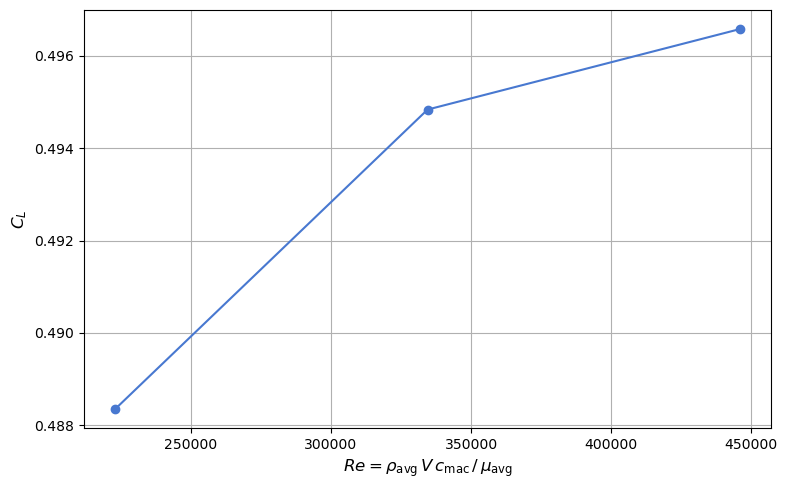

In [1482]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sutherland's law ---
mu_ref = 1.716e-5  # Pa·s
T_ref  = 273.15    # K
S      = 110.4     # K

def sutherland_viscosity(T):
    return mu_ref * (T / T_ref)**1.5 * (T_ref + S) / (T + S)

# --- Representative tunnel conditions (averaged from prop-on data) ---
temps = [
    290.81, 290.5, 290.63, 290.71, 290.45, 290.68, 290.57, 290.54, 290.56,
    290.77, 290.76, 290.54, 290.61, 290.53, 290.53, 290.38, 290.77, 290.42,
    290.82, 290.31, 290.83, 290.77, 290.83, 290.59, 290.69, 289.29, 289.89,
    289.33, 289.37, 289.75, 289.05, 289.33, 289.45, 289.41, 289.41, 289.39,
    289.18, 289.41, 289.48, 289.55, 289.09, 289.4,  289.11, 289.29, 289.24,
    289.39, 289.55, 289.31, 289.75, 289.81, 289.23, 289.71, 289.86, 289.23,
    289.85
]
rhos = [
    1.2111837665772662, 1.2124162911880931, 1.211909932667162,
    1.211564445727421,  1.2134526039979827, 1.2123845995887763,
    1.2128315782593753, 1.213028753275484,  1.2129332677003728,
    1.211985376693565,  1.2120390414597149, 1.2130047723183783,
    1.2127125926478157, 1.213034532873517,  1.2130705055473072,
    1.2136371492818563, 1.212021319675703,  1.2134939840084806,
    1.2117650239582876, 1.2139537833203915, 1.211735336730007,
    1.2113024600329465, 1.2110765180038419, 1.21206476484882,
    1.2116478035619338, 1.2185471305276716, 1.2160731113350067,
    1.2183907064735384, 1.2182343256648152, 1.2166486644737404,
    1.2197155774698278, 1.218474990839042,  1.2179096580800357,
    1.2180779880835713, 1.2180659507882505, 1.218162170535493,
    1.2191672579972812, 1.2181261372648537, 1.2178195442593014,
    1.2175010680190128, 1.219558861881395,  1.2181682287001427,
    1.2194624456700003, 1.2186675534126223, 1.2188902649715678,
    1.2182103230444081, 1.2175251309693753, 1.2184869752778251,
    1.2166486644737404, 1.216432841075817,  1.2187878701265824,
    1.216816646064224,  1.2162230099778601, 1.2187999149132185,
    1.2162289133388524
]

T_avg   = np.mean(temps)
rho_avg = np.mean(rhos)
mu_avg  = sutherland_viscosity(T_avg)

print(f"T_avg   = {T_avg:.3f} K")
print(f"rho_avg = {rho_avg:.6f} kg/m³")
print(f"mu_avg  = {mu_avg:.4e} Pa·s")

# --- Wing MAC from manual ---
c_mac = 0.165  # m

# --- Filter prop-off: alpha=2.5, beta=0, rudder=0, elevator=0 ---
df_re = df_prop_off[
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["AoS_round"] == 0)   &
    (df_prop_off["dR"]        == 0)   &
    (df_prop_off["dE"]        == 0)
].copy()
# Keep only the first sweep (lower original row indices)
df_re = df_re[df_re.index < 8000]

# Re varies through V; rho and mu are fixed representative averages
df_re["Re"] = rho_avg * df_re["V"] * c_mac / mu_avg
df_re = df_re.sort_values("Re")
def pick_row(group):
    v = group["V_round"].iloc[0]
    if v == 30.0:
        return group.iloc[[1]]  # second occurrence
    else:
        return group.iloc[[0]]  # first occurrence

df_re = df_re.groupby("V_round", group_keys=False).apply(pick_row)
print(df_re[["V_round", "V", "Re", "CL"]].to_string())

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_re["Re"], df_re["CL"], marker="o", linestyle="-")

ax.set_xlabel(r"$Re = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
ax.set_ylabel(r"$C_L$")
if SHOW_TITLE:
    ax.set_title(r"$C_L$ vs $Re$ (Prop-off, $\alpha=2.5°$, $\beta=0°$, $\delta_r=0°$, $\delta_e=0°$)")
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CL_vs_Re_propoff_AoA2.5.png"), dpi=SAVE_RES)
plt.show()

CYaw_FINAL | J = 1.6 | Fit (excluding dR=-20): y = 0.0039x + -0.0098
CYaw_FINAL | J = 1.6 | Correlation (r): 1.0000, R^2: 1.0000\n
CYaw_FINAL | J = 2.0 | Fit (excluding dR=-20): y = 0.0040x + -0.0083
CYaw_FINAL | J = 2.0 | Correlation (r): 0.9986, R^2: 0.9972\n
CYaw_FINAL | J = 2.4 | Fit (excluding dR=-20): y = 0.0045x + -0.0080
CYaw_FINAL | J = 2.4 | Correlation (r): 1.0000, R^2: 1.0000\n
CYaw_FINAL | Prop-off | Fit (excluding dR=-20): y = 0.0034x + -0.0117
CYaw_FINAL | Prop-off | Correlation (r): 0.9971, R^2: 0.9943\n


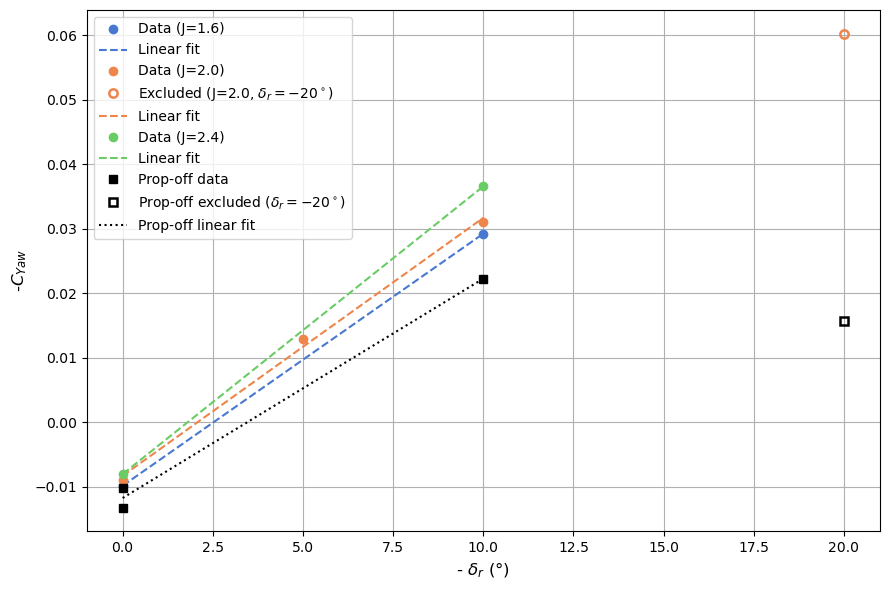

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\rudder_vs_CY_V40_AoS0_AoA2.5_J1p6_J2_J2p4_with_propOff_negRudderOnly.png
Functions can be accessed via cy_from_dr_funcs[J_value](dr_neg), and cy_from_dr_funcs['prop_off'](dr_neg)
CMyaw | J = 1.6 | Fit (excluding dR=-20): y = 0.0018x + -0.0049
CMyaw | J = 1.6 | Correlation (r): 1.0000, R^2: 1.0000\n
CMyaw | J = 2.0 | Fit (excluding dR=-20): y = 0.0018x + -0.0041
CMyaw | J = 2.0 | Correlation (r): 0.9975, R^2: 0.9951\n
CMyaw | J = 2.4 | Fit (excluding dR=-20): y = 0.0018x + -0.0039
CMyaw | J = 2.4 | Correlation (r): 1.0000, R^2: 1.0000\n
CMyaw | Prop-off | Fit (excluding dR=-20): y = 0.0015x + -0.0066
CMyaw | Prop-off | Correlation (r): 0.9992, R^2: 0.9984\n


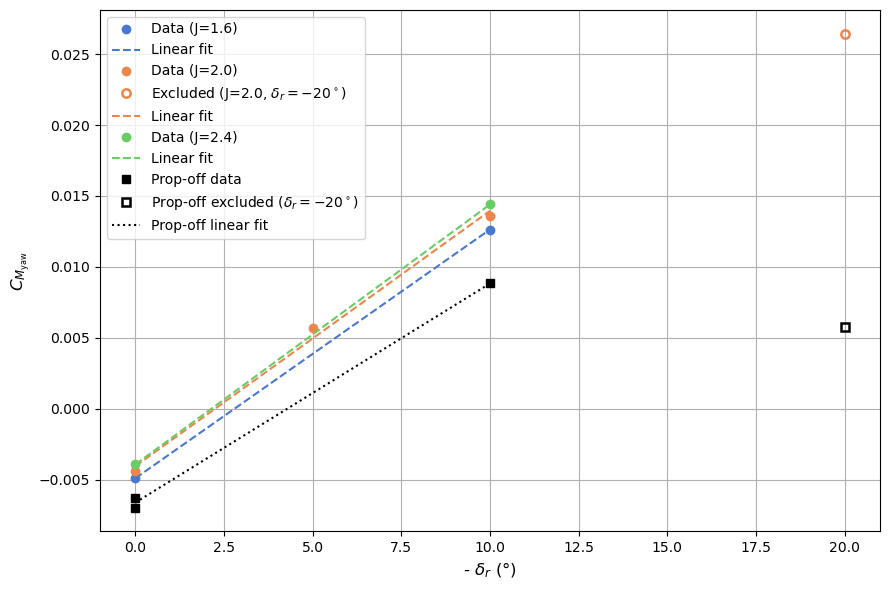

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\rudder_vs_CMyaw_V40_AoS0_AoA2.5_J1p6_J2_J2p4_with_propOff_negRudderOnly.png
Functions can be accessed via cmyaw_from_dr_funcs[J_value](dr_neg), and cmyaw_from_dr_funcs['prop_off'](dr_neg)


In [1483]:
import matplotlib.pyplot as plt
import numpy as np

# Conditions
v_target = 40
aos_target = 0
aoa_target = 2.5
j_values = [1.6, 2.0, 2.4]

# Ensure rounded helper columns exist for prop-off data too
if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()
if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()
if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)


def plot_metric_vs_dr(
    metric_col,
    y_transform,
    y_label,
    title,
    save_path,
    funcs_dict,
    funcs_print_name,
):
    fig, ax = plt.subplots(figsize=(9, 6))

    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1", "C2"])

    for idx, j_val in enumerate(j_values):
        df_filtered = df[
            (df["V_round"] == v_target) &
            (df["AoS_round"] == aos_target) &
            (df["AoA_round"] == aoa_target) &
            (df["J_round"] == j_val) &
            (df["dR"] <= 0)
        ]

        group_sorted = df_filtered.sort_values("dR")

        x_all = -group_sorted["dR"].to_numpy(dtype=float)
        y_all = y_transform(group_sorted[metric_col].to_numpy(dtype=float))

        finite_mask = np.isfinite(x_all) & np.isfinite(y_all)
        x_all = x_all[finite_mask]
        y_all = y_all[finite_mask]

        # Exclude delta_r = -20 deg from interpolation, keep visible as hollow marker.
        # x = -dR, so dR = -20 corresponds to x = 20.
        out_mask = np.isclose(x_all, 20.0)
        in_mask = ~out_mask

        color = colors[idx % len(colors)]

        # Plot used data (filled)
        if np.any(in_mask):
            ax.plot(
                x_all[in_mask],
                y_all[in_mask],
                marker="o",
                linestyle="None",
                color=color,
                label=fr"Data (J={j_val})",
            )

        # Plot excluded outlier(s) as hollow marker(s)
        if np.any(out_mask):
            ax.plot(
                x_all[out_mask],
                y_all[out_mask],
                marker="o",
                linestyle="None",
                markerfacecolor="none",
                markeredgecolor=color,
                markeredgewidth=1.8,
                label=fr"Excluded (J={j_val}, $\delta_r=-20^\circ$)",
            )

        if np.sum(in_mask) < 2:
            print(f"{metric_col} | J = {j_val}: not enough inlier points for linear fit.")
            continue

        x = x_all[in_mask]
        y = y_all[in_mask]

        # Calculate linear fit on inliers only
        slope, intercept = np.polyfit(x, y, 1)
        r_matrix = np.corrcoef(x, y)
        r_val = r_matrix[0, 1]
        r_squared = r_val**2

        print(f"{metric_col} | J = {j_val} | Fit (excluding dR=-20): y = {slope:.4f}x + {intercept:.4f}")
        print(f"{metric_col} | J = {j_val} | Correlation (r): {r_val:.4f}, R^2: {r_squared:.4f}\\n")

        # Define and store function for later use
        funcs_dict[j_val] = lambda dr_neg, m=slope, c=intercept: m * dr_neg + c

        # Plot fit (same color as data)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = funcs_dict[j_val](x_fit)
        ax.plot(
            x_fit,
            y_fit,
            linestyle="--",
            color=color,
            label=r"Linear fit",
        )

    # Add prop-off data (same V, AoS, AoA; dE fixed at 0 when available), non-positive rudder only
    df_prop_off_filtered = df_prop_off[
        (df_prop_off["V_round"] == v_target) &
        (df_prop_off["AoS_round"] == aos_target) &
        (df_prop_off["AoA_round"] == aoa_target) &
        (df_prop_off["dR"] <= 0)
    ].copy()
    if "dE" in df_prop_off_filtered.columns:
        df_prop_off_filtered = df_prop_off_filtered[df_prop_off_filtered["dE"] == 0]

    group_off_sorted = df_prop_off_filtered.sort_values("dR")
    x_off_all = -group_off_sorted["dR"].to_numpy(dtype=float)
    y_off_all = y_transform(group_off_sorted[metric_col].to_numpy(dtype=float))

    finite_off = np.isfinite(x_off_all) & np.isfinite(y_off_all)
    x_off_all = x_off_all[finite_off]
    y_off_all = y_off_all[finite_off]

    out_mask_off = np.isclose(x_off_all, 20.0)
    in_mask_off = ~out_mask_off

    if np.any(in_mask_off):
        ax.plot(
            x_off_all[in_mask_off],
            y_off_all[in_mask_off],
            marker="s",
            linestyle="None",
            color="black",
            label="Prop-off data",
        )

    if np.any(out_mask_off):
        ax.plot(
            x_off_all[out_mask_off],
            y_off_all[out_mask_off],
            marker="s",
            linestyle="None",
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=1.8,
            label=r"Prop-off excluded ($\delta_r=-20^\circ$)",
        )

    if np.sum(in_mask_off) >= 2:
        x_off = x_off_all[in_mask_off]
        y_off = y_off_all[in_mask_off]

        slope_off, intercept_off = np.polyfit(x_off, y_off, 1)
        r_matrix_off = np.corrcoef(x_off, y_off)
        r_val_off = r_matrix_off[0, 1]
        r_squared_off = r_val_off**2

        print(f"{metric_col} | Prop-off | Fit (excluding dR=-20): y = {slope_off:.4f}x + {intercept_off:.4f}")
        print(f"{metric_col} | Prop-off | Correlation (r): {r_val_off:.4f}, R^2: {r_squared_off:.4f}\\n")

        funcs_dict["prop_off"] = lambda dr_neg, m=slope_off, c=intercept_off: m * dr_neg + c

        x_fit_off = np.linspace(x_off.min(), x_off.max(), 100)
        y_fit_off = funcs_dict["prop_off"](x_fit_off)
        ax.plot(
            x_fit_off,
            y_fit_off,
            linestyle=":",
            color="black",
            label=r"Prop-off linear fit",
        )
    else:
        print(f"{metric_col} | Prop-off: not enough inlier points for linear fit.")

    ax.set_xlabel(r"- $\delta_r$ (°)")
    ax.set_ylabel(y_label)
    if SHOW_TITLE:
        ax.set_title(title)
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=SAVE_RES)
    plt.show()
    print(f"Saved to {save_path}")
    print(f"Functions can be accessed via {funcs_print_name}[J_value](dr_neg), and {funcs_print_name}['prop_off'](dr_neg)")


# CY vs -delta_r (non-positive rudder deflections only)
cy_from_dr_funcs = {}
plot_metric_vs_dr(
    metric_col="CYaw_FINAL",
    y_transform=lambda arr: -arr,
    y_label=r"-$C_{Yaw}$",
    title=(
        r"Rudder Deflection Angle vs $C_{Yaw}$ "
        r"(V = 40 m/s, AoS = 0°, AoA = 2.5°, J = 1.6, 2.0, 2.4, prop-off; $\delta_r\leq0$ only)"
    ),
    save_path=os.path.join(PLOT_DIR, "rudder_vs_CY_V40_AoS0_AoA2.5_J1p6_J2_J2p4_with_propOff_negRudderOnly.png"),
    funcs_dict=cy_from_dr_funcs,
    funcs_print_name="cy_from_dr_funcs",
)

# CMyaw vs -delta_r (same data selection, non-positive rudder deflections only)
cmyaw_from_dr_funcs = {}
plot_metric_vs_dr(
    metric_col="CMyaw",
    y_transform=lambda arr: arr,
    y_label=r"$C_{M_\mathrm{yaw}}$",
    title=(
        r"Rudder Deflection Angle vs $C_{M_\mathrm{yaw}}$ "
        r"(V = 40 m/s, AoS = 0°, AoA = 2.5°, J = 1.6, 2.0, 2.4, prop-off; $\delta_r\leq0$ only)"
    ),
    save_path=os.path.join(PLOT_DIR, "rudder_vs_CMyaw_V40_AoS0_AoA2.5_J1p6_J2_J2p4_with_propOff_negRudderOnly.png"),
    funcs_dict=cmyaw_from_dr_funcs,
    funcs_print_name="cmyaw_from_dr_funcs",
)

dR = -20.0° | Fit Function: y = -0.0047x + 0.0262 | r = -0.9983, R^2 = 0.9966
dR = -10.0° | Fit Function: y = -0.0049x + 0.0132 | r = -0.9987, R^2 = 0.9974
dR = -5.0° | Fit Function: y = -0.0049x + 0.0054 | r = -0.9989, R^2 = 0.9978
dR = 0.0° | Fit Function: y = -0.0049x + -0.0051 | r = -0.9995, R^2 = 0.9990

(Functions can be accessed via `cmyaw_from_aos_funcs[dR_value](aos)`)


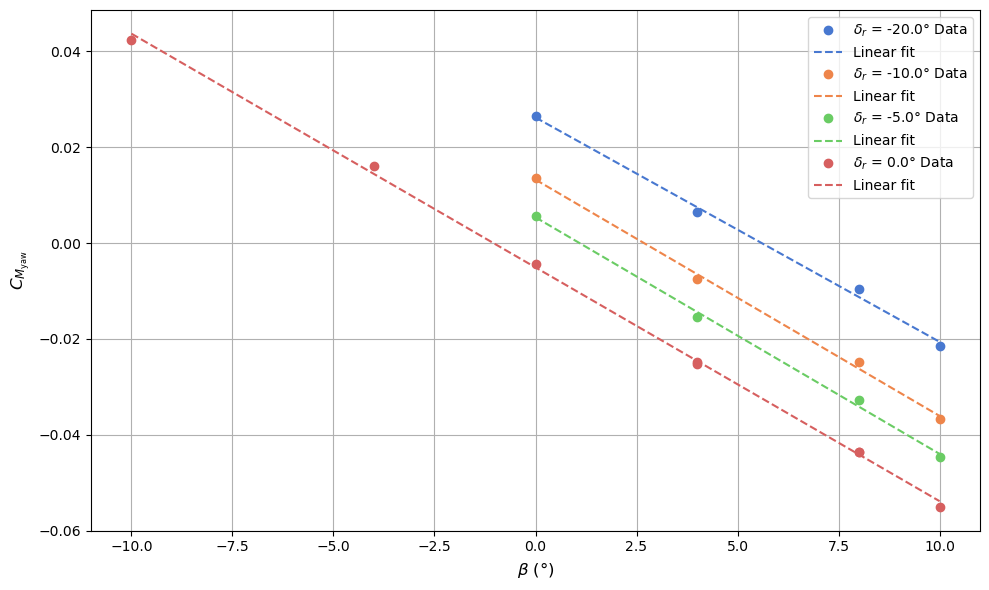

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png


In [1484]:
import matplotlib.pyplot as plt
import numpy as np

df_filtered = df[(df["V_round"] == 40) & (df["AoA_round"] == 2.5) & (df["J_round"] == 2)]

fig, ax = plt.subplots(figsize=(10, 6))

# Dictionary to store interpolation functions for each rudder
cmyaw_from_aos_funcs = {}

for rudder, group in df_filtered.groupby("dR"):
    group_sorted = group.sort_values("AoS_round")
    
    x = group_sorted["AoS_round"].values
    y = group_sorted["CMyaw"].values
    
    # Calculate linear fit
    slope, intercept = np.polyfit(x, y, 1)
    r_matrix = np.corrcoef(x, y)
    r_val = r_matrix[0, 1]
    r_squared = r_val**2
    
    print(f"dR = {rudder}° | Fit Function: y = {slope:.4f}x + {intercept:.4f} | r = {r_val:.4f}, R^2 = {r_squared:.4f}")
    
    # Store function in dictionary for later use
    cmyaw_from_aos_funcs[rudder] = lambda aos, m=slope, c=intercept: m * aos + c
    
    # Plot original data
    # Compatible with newer matplotlib (avoid private ax._get_lines.prop_cycler)
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0"])
    color = colors[(len(cmyaw_from_aos_funcs) - 1) % len(colors)]
    ax.plot(
        x, y,
        marker="o",
        linestyle="None",
        color=color,
        label=fr"$\delta_r$ = {rudder}° Data",
    )
    
    # Plot linear fit
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(
        x_fit, y_fit,
        linestyle="--",
        color=color,
        label=r"Linear fit",
    )

print("\n(Functions can be accessed via `cmyaw_from_aos_funcs[dR_value](aos)`)")

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{yaw}}$")
if SHOW_TITLE:
    ax.set_title(r"Angle of Sideslip vs $C_{M_\mathrm{yaw}}$ (V = 40 m/s, AoA = 2.5°, $J$ = 2)")

# Place legend outside due to many elements
ax.legend(loc='best')
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved to {os.path.join(PLOT_DIR, 'AoS_vs_CMyaw_V40_AoA2.5_J2_all_rudders.png')}")



=== CL_FINAL interpolation (degree 1) ===
CL_FINAL | J=1.6, dR=-10.0: y(alpha) = 0.1083*x + 0.1875 | R^2 = 0.99979
CL_FINAL | J=1.6, dR=0.0: y(alpha) = 0.1081*x + 0.1911 | R^2 = 0.99978
CL_FINAL | J=2.4, dR=-10.0: y(alpha) = 0.1062*x + 0.1817 | R^2 = 0.99981
CL_FINAL | J=2.4, dR=0.0: y(alpha) = 0.1061*x + 0.1835 | R^2 = 0.99975
CL_FINAL | Prop-off: y(alpha) = 0.1022*x + 0.1894 | R^2 = 0.99926


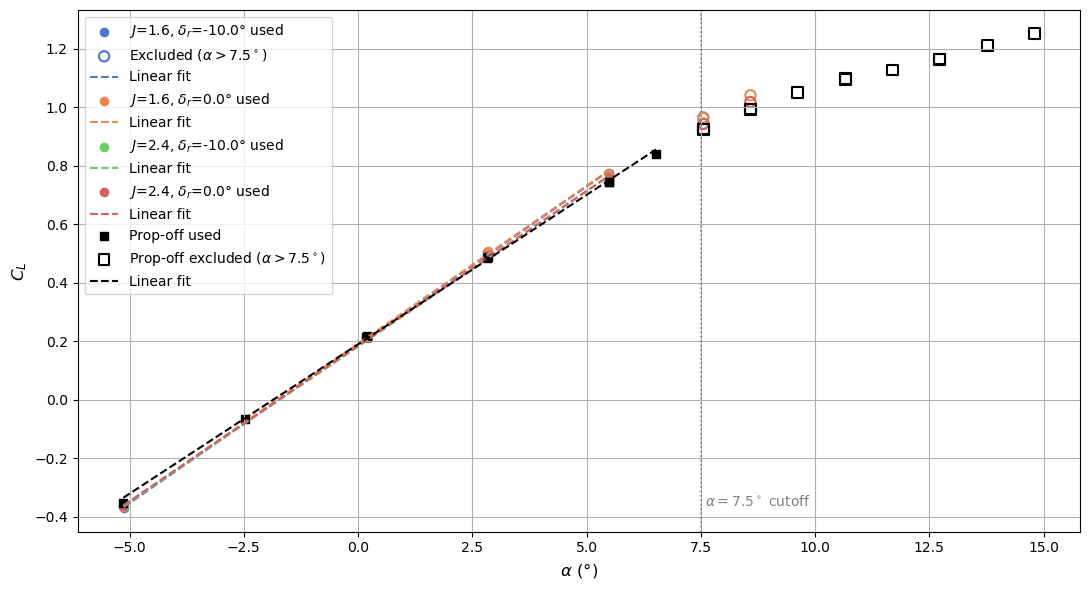

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CL_vs_alpha_linear_interp_upto7p5.png

=== CD_FINAL interpolation (degree 2) ===
CD_FINAL | J=1.6, dR=-10.0: y(alpha) = 0.0006*x^2 + 0.0008*x + 0.0475 | R^2 = 1.00000
CD_FINAL | J=1.6, dR=0.0: y(alpha) = 0.0005*x^2 + 0.0008*x + 0.0453 | R^2 = 1.00000
CD_FINAL | J=2.4, dR=-10.0: y(alpha) = 0.0005*x^2 + 0.0010*x + 0.0490 | R^2 = 1.00000
CD_FINAL | J=2.4, dR=0.0: y(alpha) = 0.0006*x^2 + 0.0011*x + 0.0448 | R^2 = 1.00000
CD_FINAL | Prop-off: y(alpha) = 0.0005*x^2 + 0.0010*x + 0.0456 | R^2 = 0.99944


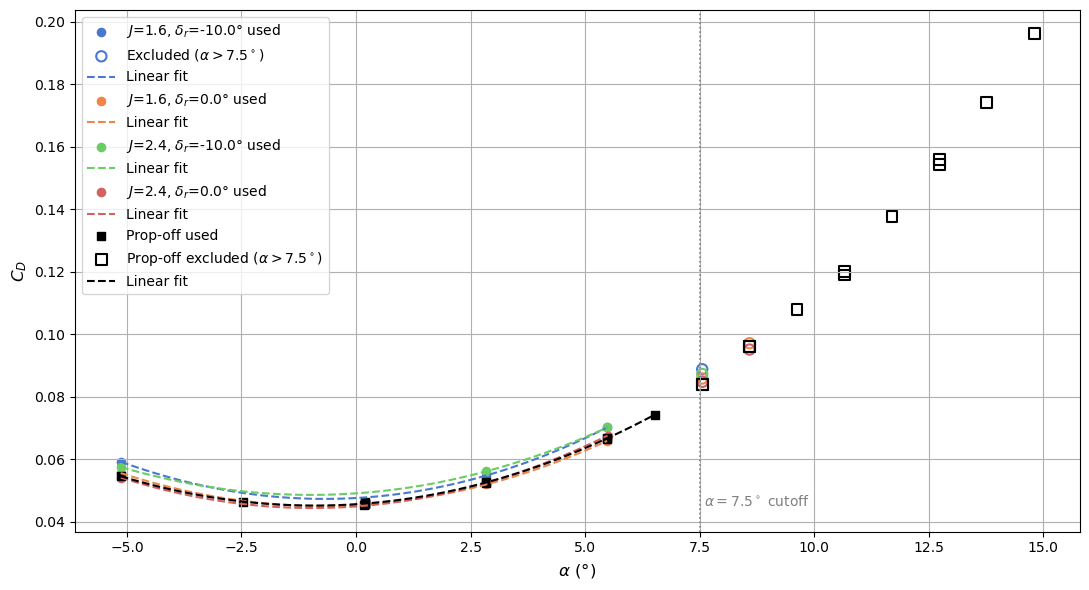

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CD_vs_alpha_quadratic_interp_upto7p5.png

=== CLCD interpolation (degree 2) ===
CLCD | J=1.6, dR=-10.0: y(alpha) = -0.1183*x^2 + 1.6720*x + 5.4246 | R^2 = 1.00000
CLCD | J=1.6, dR=0.0: y(alpha) = -0.1224*x^2 + 1.7746*x + 5.7405 | R^2 = 1.00000
CLCD | J=2.4, dR=-10.0: y(alpha) = -0.1071*x^2 + 1.6544*x + 4.9428 | R^2 = 1.00000
CLCD | J=2.4, dR=0.0: y(alpha) = -0.1279*x^2 + 1.7361*x + 5.5530 | R^2 = 1.00000
CLCD | Prop-off: y(alpha) = -0.0959*x^2 + 1.7500*x + 4.4532 | R^2 = 0.99306


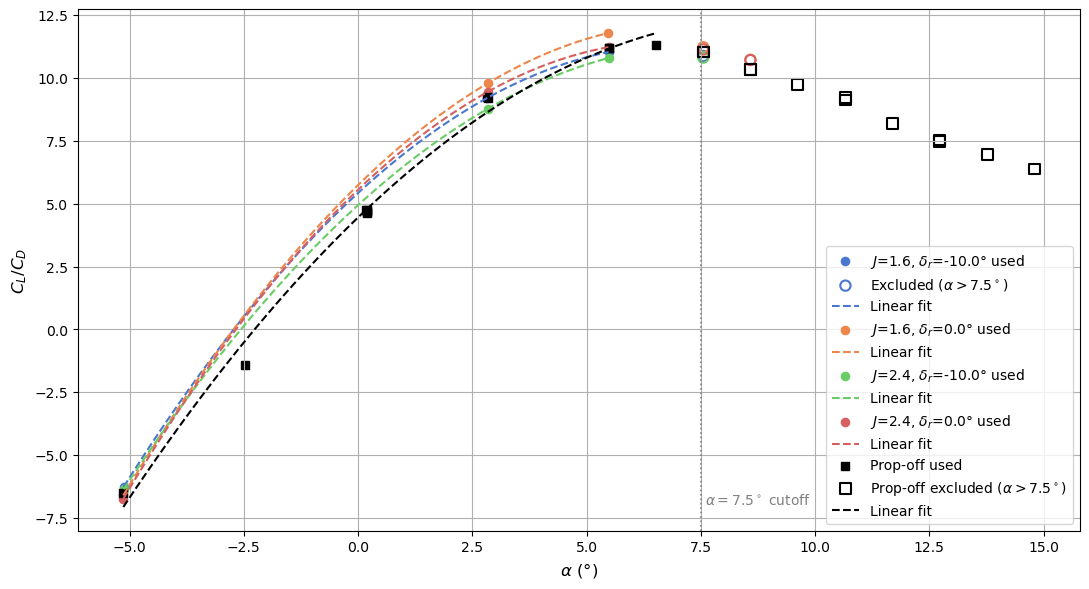

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CLCD_vs_alpha_quadratic_interp_upto7p5.png

Interpolation functions are stored in `interpolation_functions`.
Example usage: interpolation_functions['CL_FINAL'][(1.6, 0)](4.0)


In [1485]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Make sure output folder exists
os.makedirs(PLOT_DIR, exist_ok=True)

# -----------------------------------
# Create rounded columns if missing
# -----------------------------------
if "V_round" not in df.columns:
    df["V_round"] = df["V"].round()

if "AoS_round" not in df.columns:
    df["AoS_round"] = df["AoS"].round()

if "AoA_round" not in df.columns:
    df["AoA_round"] = df["AoA"].round(1)

if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()

if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()

if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)

# -----------------------------------
# Filter data
# -----------------------------------
df_filtered = df[
    (df["V_round"] == 40) &
    (df["J_round"] != 2) &
    (df["AoS_round"] == 0)
] .copy()

df_prop_off_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0) &
    (df_prop_off["dE"] == 0)
] .copy()

valid_groups = (
    df_filtered.groupby(["J_round", "dR"])["AoA_round"]
    .nunique()
    .reset_index()
)
valid_groups = valid_groups[valid_groups["AoA_round"] > 1]

df_prop_off_filtered = df_prop_off_filtered.sort_values("AoA_round")

# -----------------------------------
# Build CL/CD and interpolation containers
# -----------------------------------
df_filtered = df_filtered.copy()
df_prop_off_filtered = df_prop_off_filtered.copy()

df_filtered["CLCD"] = df_filtered["CL_FINAL"] / df_filtered["CD_FINAL"].replace(0, np.nan)
df_prop_off_filtered["CLCD"] = df_prop_off_filtered["CL_FINAL"] / df_prop_off_filtered["CD_FINAL"].replace(0, np.nan)

alpha_fit_max = 7.5
interpolation_functions = {
    "CL_FINAL": {},
    "CD_FINAL": {},
    "CLCD": {},
}
interpolation_coeffs = {
    "CL_FINAL": {},
    "CD_FINAL": {},
    "CLCD": {},
}

def poly_eqn_string(coeffs):
    degree = len(coeffs) - 1
    terms = []
    for i, c in enumerate(coeffs):
        power = degree - i
        if power == 0:
            terms.append(f"{c:.4f}")
        elif power == 1:
            terms.append(f"{c:.4f}*x")
        else:
            terms.append(f"{c:.4f}*x^{power}")
    return " + ".join(terms).replace("+ -", "- ")

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if np.isclose(ss_tot, 0.0):
        return np.nan
    return 1.0 - ss_res / ss_tot

def fit_and_plot_vs_alpha(y_col, y_label, title, save_path, degree):
    fig, ax = plt.subplots(figsize=(11, 6))
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0"] * 10)

    shown_excluded_label = False
    print(f"\n=== {y_col} interpolation (degree {degree}) ===")

    for idx, (_, row) in enumerate(valid_groups.iterrows()):
        j_val = row["J_round"]
        rudder_val = row["dR"]

        group = df_filtered[
            (df_filtered["J_round"] == j_val) &
            (df_filtered["dR"] == rudder_val)
        ].sort_values("AoA_round")

        x_all = group[AOA_COL].to_numpy(dtype=float)
        y_all = group[y_col].to_numpy(dtype=float)
        finite_mask = np.isfinite(x_all) & np.isfinite(y_all)
        x_all = x_all[finite_mask]
        y_all = y_all[finite_mask]

        used_mask = x_all <= alpha_fit_max
        x_used, y_used = x_all[used_mask], y_all[used_mask]
        x_excl, y_excl = x_all[~used_mask], y_all[~used_mask]

        color = colors[idx % len(colors)]
        base_label = fr"$J$={j_val}, $\delta_r$={rudder_val}°"

        ax.scatter(x_used, y_used, color=color, s=35, label=base_label + " used")
        if len(x_excl) > 0:
            excl_label = r"Excluded ($\alpha > 7.5^\circ$)" if not shown_excluded_label else None
            ax.scatter(
                x_excl, y_excl,
                facecolors="none",
                edgecolors=color,
                s=55,
                linewidths=1.5,
                label=excl_label,
            )
            shown_excluded_label = True

        min_points = degree + 1
        if len(x_used) < min_points:
            print(
                f"{y_col} | J={j_val}, dR={rudder_val}: skipped, "
                f"need >= {min_points} points with alpha <= {alpha_fit_max}"
            )
            continue

        coeffs = np.polyfit(x_used, y_used, degree)
        fit_func = np.poly1d(coeffs)
        y_hat = fit_func(x_used)
        r2 = compute_r2(y_used, y_hat)
        eqn_str = poly_eqn_string(coeffs)

        interpolation_coeffs[y_col][(j_val, rudder_val)] = coeffs
        interpolation_functions[y_col][(j_val, rudder_val)] = (
            lambda alpha, c=coeffs: np.polyval(c, np.asarray(alpha, dtype=float))
        )

        x_fit = np.linspace(x_used.min(), x_used.max(), 100)
        y_fit = fit_func(x_fit)
        ax.plot(
            x_fit, y_fit,
            linestyle="--",
            color=color,
            label=r"Linear fit"
        )

        print(
            f"{y_col} | J={j_val}, dR={rudder_val}: "
            f"y(alpha) = {eqn_str} | R^2 = {r2:.5f}"
        )

    # Prop-off interpolation for reference
    x_off_all = df_prop_off_filtered[AOA_COL].to_numpy(dtype=float)
    y_off_all = df_prop_off_filtered[y_col].to_numpy(dtype=float)
    finite_off = np.isfinite(x_off_all) & np.isfinite(y_off_all)
    x_off_all = x_off_all[finite_off]
    y_off_all = y_off_all[finite_off]

    used_off = x_off_all <= alpha_fit_max
    x_off_used, y_off_used = x_off_all[used_off], y_off_all[used_off]
    x_off_excl, y_off_excl = x_off_all[~used_off], y_off_all[~used_off]

    ax.scatter(
        x_off_used, y_off_used,
        color="black",
        marker="s",
        s=35,
        label="Prop-off used",
    )
    if len(x_off_excl) > 0:
        excl_label = r"Prop-off excluded ($\alpha > 7.5^\circ$)"
        ax.scatter(
            x_off_excl, y_off_excl,
            facecolors="none",
            edgecolors="black",
            marker="s",
            s=60,
            linewidths=1.5,
            label=excl_label,
        )

    min_points = degree + 1
    if len(x_off_used) >= min_points:
        coeffs_off = np.polyfit(x_off_used, y_off_used, degree)
        fit_off = np.poly1d(coeffs_off)
        y_hat_off = fit_off(x_off_used)
        r2_off = compute_r2(y_off_used, y_hat_off)
        eqn_off_str = poly_eqn_string(coeffs_off)

        interpolation_coeffs[y_col][("prop_off", 0)] = coeffs_off
        interpolation_functions[y_col][("prop_off", 0)] = (
            lambda alpha, c=coeffs_off: np.polyval(c, np.asarray(alpha, dtype=float))
        )

        x_fit_off = np.linspace(x_off_used.min(), x_off_used.max(), 100)
        y_fit_off = fit_off(x_fit_off)
        ax.plot(
            x_fit_off, y_fit_off,
            linestyle="--",
            color="black",
            label=r"Linear fit"
        )

        print(
            f"{y_col} | Prop-off: y(alpha) = {eqn_off_str} "
            f"| R^2 = {r2_off:.5f}"
        )
    else:
        print(
            f"{y_col} | Prop-off: skipped, need >= {min_points} points "
            f"with alpha <= {alpha_fit_max}"
        )

    ax.axvline(alpha_fit_max, color="gray", linestyle=":", linewidth=1.2)
    ax.text(
        alpha_fit_max + 0.1,
        ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
        r"$\alpha=7.5^\circ$ cutoff",
        color="gray",
    )

    ax.set_xlabel(r"$\alpha$ (°)")
    ax.set_ylabel(y_label)
    if SHOW_TITLE:
        ax.set_title(title)
    ax.legend(ncol=1, loc="best")
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=SAVE_RES)
    plt.show()
    print(f"Saved to {save_path}")

# Store which AOA_COL was used to build these functions
interpolation_meta = {"AOA_COL": AOA_COL}

# -----------------------------------
# Plot 1: CL vs alpha (linear interpolation)
# -----------------------------------
fit_and_plot_vs_alpha(
    y_col="CL_FINAL",
    y_label=r"$C_L$",
    title=r"$C_L$ vs $\alpha$ (linear fit, V = 40 m/s, AoS = 0°)",
    save_path=os.path.join(PLOT_DIR, "CL_vs_alpha_linear_interp_upto7p5.png"),
    degree=1
)

# -----------------------------------
# Plot 2: CD vs alpha (quadratic interpolation)
# -----------------------------------
fit_and_plot_vs_alpha(
    y_col="CD_FINAL",
    y_label=r"$C_D$",
    title=r"$C_D$ vs $\alpha$ (quadratic fit, V = 40 m/s, AoS = 0°)",
    save_path=os.path.join(PLOT_DIR, "CD_vs_alpha_quadratic_interp_upto7p5.png"),
    degree=2
)

# -----------------------------------
# Plot 3: CL/CD vs alpha (quadratic interpolation)
# -----------------------------------
fit_and_plot_vs_alpha(
    y_col="CLCD",
    y_label=r"$C_L / C_D$",
    title=r"$C_L / C_D$ vs $\alpha$ (quadratic fit, V = 40 m/s, AoS = 0°)",
    save_path=os.path.join(PLOT_DIR, "CLCD_vs_alpha_quadratic_interp_upto7p5.png"),
    degree=2
)

print("\nInterpolation functions are stored in `interpolation_functions`.")
print("Example usage: interpolation_functions['CL_FINAL'][(1.6, 0)](4.0)")

CYaw_FINAL | dR = -10.0 deg | Fit Function: y = -0.0034x + -0.0240 | r = -0.9922, R^2 = 0.9845
  Excluded outlier J values: [2.4]
CYaw_FINAL | dR = 0.0 deg | Fit Function: y = -0.0018x + 0.0126 | r = -0.9774, R^2 = 0.9554
CYaw_FINAL | Prop-off avg (dE=0): 0.000395 from n=3 points

(Functions can be accessed via cy_from_j_funcs[dR_value](j))


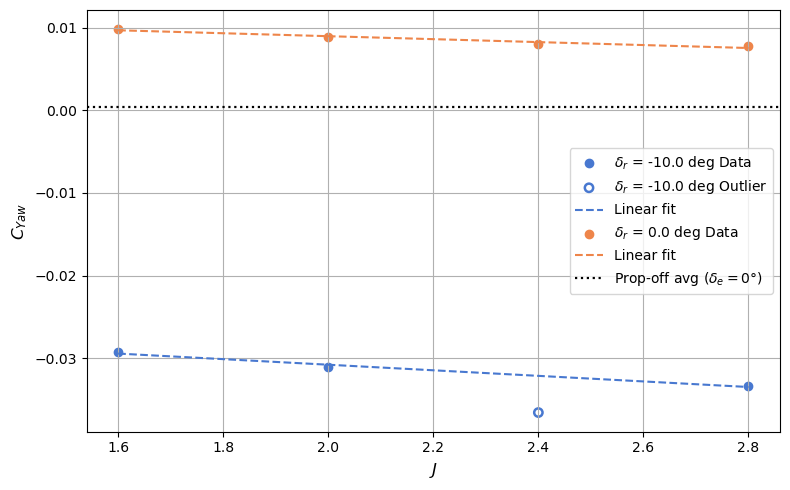

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\J_vs_CY_V40_AoS0_AoA2.5_rudder0_m10_linear_fit_outliers_marked.png
CMyaw | dR = -10.0 deg | Fit Function: y = 0.0018x + 0.0098 | r = 0.9947, R^2 = 0.9894
  Excluded outlier J values: [2.4]
CMyaw | dR = 0.0 deg | Fit Function: y = 0.0010x + -0.0065 | r = 0.9893, R^2 = 0.9788
CMyaw | Prop-off avg (dE=0): -0.001474 from n=3 points

(Functions can be accessed via cmyaw_from_j_funcs[dR_value](j))


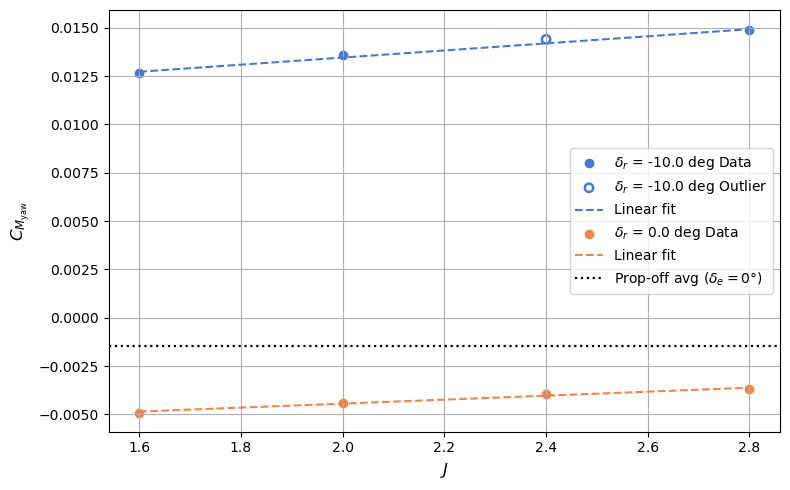

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\J_vs_CMyaw_V40_AoS0_AoA2.5_rudder0_m10_linear_fit_outliers_marked.png


In [1486]:
import matplotlib.pyplot as plt
import numpy as np

df_filtered = df[
    (df["V_round"] == 40) &
    (df["AoS_round"] == 0) &
    (df["AoA_round"] == 2.5) &
    (df["dR"].isin([0, -10]))
]

# Matching prop-off reference data (same V, AoS, AoA and rudder set), with elevator fixed at 0
df_prop_off_ref = df_prop_off[
    (df_prop_off["V_round"] == 40) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["dE"] == 0) &
    (df_prop_off["dR"].isin(sorted(df_filtered["dR"].unique())))
]

def outlier_mask_j(x, rudder_val):
    """Outliers are excluded from fit but still shown as hollow markers."""
    mask = np.zeros(len(x), dtype=bool)

    # Selected outlier(s) for this J-based plot
    if np.isclose(rudder_val, -10.0):
        mask |= np.isclose(x, 2.4)

    return mask

def plot_vs_j(y_col, y_label, title, save_path, funcs_dict, funcs_name):
    fig, ax = plt.subplots(figsize=(8, 5))

    for rudder_val, group in df_filtered.groupby("dR"):
        group_sorted = group.sort_values("J_round")

        x = group_sorted["J_round"].to_numpy(dtype=float)
        y = group_sorted[y_col].to_numpy(dtype=float)

        finite_mask = np.isfinite(x) & np.isfinite(y)
        x = x[finite_mask]
        y = y[finite_mask]
        if len(x) < 2:
            continue

        out_mask = outlier_mask_j(x, rudder_val)
        in_mask = ~out_mask

        if np.sum(in_mask) < 2:
            print(f"{y_col} | dR = {rudder_val} deg: not enough inlier points for fit.")
            continue

        x_in, y_in = x[in_mask], y[in_mask]

        # Calculate linear fit on inliers only
        slope, intercept = np.polyfit(x_in, y_in, 1)
        r_matrix = np.corrcoef(x_in, y_in)
        r_val = r_matrix[0, 1]
        r_squared = r_val**2

        print(
            f"{y_col} | dR = {rudder_val} deg | Fit Function: y = {slope:.4f}x + {intercept:.4f} "
            f"| r = {r_val:.4f}, R^2 = {r_squared:.4f}"
        )
        if np.any(out_mask):
            print(f"  Excluded outlier J values: {x[out_mask].tolist()}")

        # Store function in dictionary for later use
        funcs_dict[rudder_val] = lambda j, m=slope, c=intercept: m * j + c

        # Plot original data (inliers: filled)
        colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0"])
        color = colors[(len(funcs_dict) - 1) % len(colors)]

        ax.scatter(
            x_in, y_in,
            marker="o",
            color=color,
            label=fr"$\delta_r$ = {rudder_val} deg Data",
        )

        # Plot outliers as hollow markers
        if np.any(out_mask):
            x_out, y_out = x[out_mask], y[out_mask]
            ax.scatter(
                x_out, y_out,
                marker="o",
                facecolors="none",
                edgecolors=color,
                linewidths=1.8,
                label=fr"$\delta_r$ = {rudder_val} deg Outlier",
            )

        # Plot linear fit
        x_fit = np.linspace(x_in.min(), x_in.max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(
            x_fit, y_fit,
            linestyle="--",
            color=color,
            label=r"Linear fit",
        )

    # Prop-off average reference line (same conditions, dE=0)
    y_off = df_prop_off_ref[y_col].to_numpy(dtype=float) if y_col in df_prop_off_ref.columns else np.array([])
    y_off = y_off[np.isfinite(y_off)]
    if len(y_off) > 0:
        y_off_avg = float(np.mean(y_off))
        ax.axhline(
            y=y_off_avg,
            color="black",
            linestyle=":",
            linewidth=1.6,
            label=r"Prop-off avg ($\delta_e=0°$)",
        )
        print(f"{y_col} | Prop-off avg (dE=0): {y_off_avg:.6f} from n={len(y_off)} points")
    else:
        print(f"{y_col} | Prop-off avg (dE=0): no valid points found for reference line")

    print(f"\n(Functions can be accessed via {funcs_name}[dR_value](j))")

    ax.set_xlabel(r"$J$")
    ax.set_ylabel(y_label)
    if SHOW_TITLE:
        ax.set_title(title)
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=SAVE_RES)
    plt.show()
    print(f"Saved to {save_path}")

# Dictionary to store interpolation functions for each rudder (CY)
cy_from_j_funcs = {}
plot_vs_j(
    y_col="CYaw_FINAL",
    y_label=r"$C_{Yaw}$",
    title=r"$J$ vs $C_{Yaw}$ (V = 40 m/s, AoS = 0 deg, $\alpha$ = 2.5 deg, $\delta_r$ = 0 deg and -10 deg)",
    save_path=os.path.join(PLOT_DIR, "J_vs_CY_V40_AoS0_AoA2.5_rudder0_m10_linear_fit_outliers_marked.png"),
    funcs_dict=cy_from_j_funcs,
    funcs_name="cy_from_j_funcs",
)

# Dictionary to store interpolation functions for each rudder (CMyaw)
cmyaw_from_j_funcs = {}
plot_vs_j(
    y_col="CMyaw",
    y_label=r"$C_{M_\mathrm{yaw}}$",
    title=r"$J$ vs $C_{M_\mathrm{yaw}}$ (V = 40 m/s, AoS = 0 deg, $\alpha$ = 2.5 deg, $\delta_r$ = 0 deg and -10 deg)",
    save_path=os.path.join(PLOT_DIR, "J_vs_CMyaw_V40_AoS0_AoA2.5_rudder0_m10_linear_fit_outliers_marked.png"),
    funcs_dict=cmyaw_from_j_funcs,
    funcs_name="cmyaw_from_j_funcs",
)

CD Fit Function (excluding dR=-20): y = -0.000284x + 0.050646
Correlation (r): -1.0000, R^2: 0.9999
Excluded outlier dR values: [-20.0]


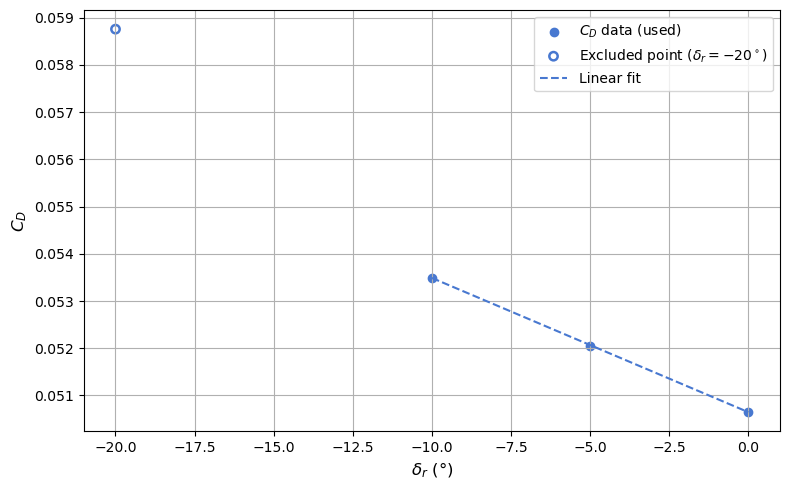

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CD_vs_rudder_V40_J2_AoA2p5_AoS0_linear_fit_outlier_marked.png


In [1487]:
import matplotlib.pyplot as plt
import numpy as np

# CD vs rudder deflection for: J=2, V=40 m/s, AoA=2.5 deg, AoS=0 deg
cd_rudder_df = df[
    (df["V_round"] == 40) &
    (df["J_round"] == 2) &
    (df["AoA_round"] == 2.5) &
    (df["AoS_round"] == 0)
].copy()

cd_rudder_df = cd_rudder_df.sort_values("dR")

if cd_rudder_df.empty:
    print("No data found for V=40, J=2, AoA=2.5, AoS=0.")
else:
    x = cd_rudder_df["dR"].to_numpy(dtype=float)
    y = cd_rudder_df["CD_FINAL"].to_numpy(dtype=float)

    finite_mask = np.isfinite(x) & np.isfinite(y)
    x = x[finite_mask]
    y = y[finite_mask]

    # Exclude delta_r = -20 deg from interpolation, but keep it visible in the plot.
    out_mask = np.isclose(x, -20.0)
    in_mask = ~out_mask

    if np.sum(in_mask) < 2:
        print("Not enough inlier points for linear interpolation after excluding dR = -20 deg.")
    else:
        x_in, y_in = x[in_mask], y[in_mask]

        # Linear interpolation (fit) on inliers only
        slope, intercept = np.polyfit(x_in, y_in, 1)
        r_matrix = np.corrcoef(x_in, y_in)
        r_val = r_matrix[0, 1]
        r_squared = r_val**2

        print(f"CD Fit Function (excluding dR=-20): y = {slope:.6f}x + {intercept:.6f}")
        print(f"Correlation (r): {r_val:.4f}, R^2: {r_squared:.4f}")
        if np.any(out_mask):
            print(f"Excluded outlier dR values: {x[out_mask].tolist()}")

        fig, ax = plt.subplots(figsize=(8, 5))

        # Inliers: filled markers
        ax.scatter(x_in, y_in, marker="o", color=COLORS[0], label=r"$C_D$ data (used)")

        # Excluded point(s): hollow marker
        if np.any(out_mask):
            x_out, y_out = x[out_mask], y[out_mask]
            ax.scatter(
                x_out,
                y_out,
                marker="o",
                facecolors="none",
                edgecolors=COLORS[0],
                linewidths=1.8,
                label=r"Excluded point ($\delta_r=-20^\circ$)",
            )

        # Fit line
        x_fit = np.linspace(x_in.min(), x_in.max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(
            x_fit,
            y_fit,
            linestyle="--",
            color=COLORS[0],
            label=r"Linear fit",
        )

        ax.set_xlabel(r"$\delta_r$ (°)")
        ax.set_ylabel(r"$C_D$")
        if SHOW_TITLE:
            ax.set_title(r"$C_D$ vs $\delta_r$ (V=40 m/s, $J=2$, $\alpha=2.5^\circ$, $\beta=0^\circ$)")
        ax.grid(True)
        ax.legend()

        plt.tight_layout()
        plt.savefig(os.path.join(PLOT_DIR, "CD_vs_rudder_V40_J2_AoA2p5_AoS0_linear_fit_outlier_marked.png"), dpi=SAVE_RES)
        plt.show()
        print(f"Saved to {os.path.join(PLOT_DIR, 'CD_vs_rudder_V40_J2_AoA2p5_AoS0_linear_fit_outlier_marked.png')}")

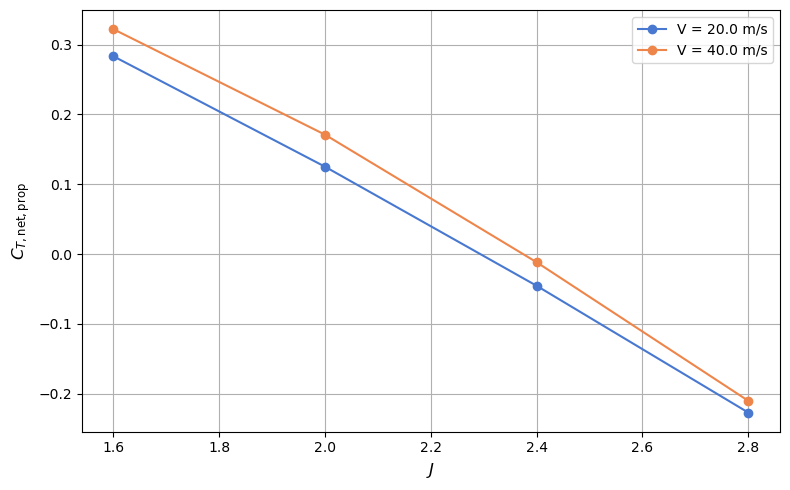

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png


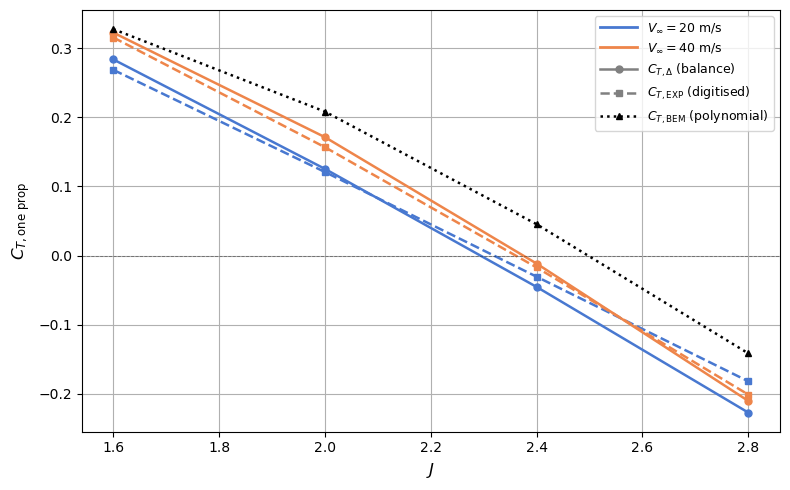

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0_BEM_EXP.png


In [1488]:
import matplotlib.pyplot as plt
import numpy as np

df_filtered = df[
    (df["V_round"].isin([20, 40])) &
    (df["AoS_round"] == 0) &
    (df["AoA_round"] == 2.5) &
    (df["dR"] == 0)
]

# ── Plot 1: original — CT_one_prop_delta vs J ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for v_val, group in df_filtered.groupby("V_round"):
    group_sorted = group.sort_values("J_round")
    ax.plot(
        group_sorted["J_round"],
        group_sorted["CT_one_prop_delta"],
        marker="o",
        linestyle="-",
        label=f"V = {v_val} m/s",
    )

ax.set_xlabel(r"$J$")
ax.set_ylabel(r"$C_{T,\mathrm{net,prop}}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{T,\mathrm{net,prop}}$ vs $J$ ($\delta_r$ = 0°, AoS = 0°, $\alpha$ = 2.5°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved to {os.path.join(PLOT_DIR, 'CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0.png')}")

# ── Plot 2: delta + EXP per V, BEM once (V-independent) ──────────────────────
v_colors = {20: COLORS[0], 40: COLORS[1]}

v_sources = {
    "CT_one_prop_delta": ("-",  "o", r"$C_{T,\Delta}$ (balance)"),
    "CT_one_prop_EXP":   ("--", "s", r"$C_{T,\mathrm{EXP}}$ (digitised)"),
}

fig, ax = plt.subplots(figsize=(8, 5))

for v_val, group in df_filtered.groupby("V_round"):
    group_sorted = group.sort_values("J_round")
    c = v_colors[v_val]
    for col, (ls, mk, _) in v_sources.items():
        ax.plot(
            group_sorted["J_round"],
            group_sorted[col].to_numpy(dtype=float),
            color=c,
            linestyle=ls,
            linewidth=1.8,
            marker=mk,
            markersize=5,
        )

# BEM drawn once in black — purely a function of J, independent of V
bem_group = df_filtered[df_filtered["V_round"] == 40].sort_values("J_round")
ax.plot(
    bem_group["J_round"],
    bem_group["CT_one_prop_BEM"].to_numpy(dtype=float),
    color="k",
    linestyle=":",
    linewidth=1.8,
    marker="^",
    markersize=5,
)

# Legend: colour proxies for V, style+marker proxies for source
for v_val, c in v_colors.items():
    ax.plot([], [], color=c, lw=2, label=fr"$V_\infty = {v_val}$ m/s")
for col, (ls, mk, label) in v_sources.items():
    ax.plot([], [], color="grey", ls=ls, marker=mk, markersize=5, lw=1.8, label=label)
ax.plot([], [], color="k", ls=":", marker="^", markersize=5, lw=1.8,
        label=r"$C_{T,\mathrm{BEM}}$ (polynomial)")

ax.axhline(0, color="k", lw=0.6, ls="--", alpha=0.4)
ax.set_xlabel(r"$J$")
ax.set_ylabel(r"$C_{T,\mathrm{one\ prop}}$")
if SHOW_TITLE:
    ax.set_title(
        r"$C_T$ per prop vs $J$: balance $\Delta$, EXP and BEM"
        "\n"
        r"($\delta_r = 0°$, AoS = 0°, $\alpha = 2.5°$)"
    )
ax.legend(fontsize=9, handlelength=3)
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0_BEM_EXP.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved to {os.path.join(PLOT_DIR, 'CT_vs_J_V20_V40_AoS0_AoA2.5_rudder0_BEM_EXP.png')}")

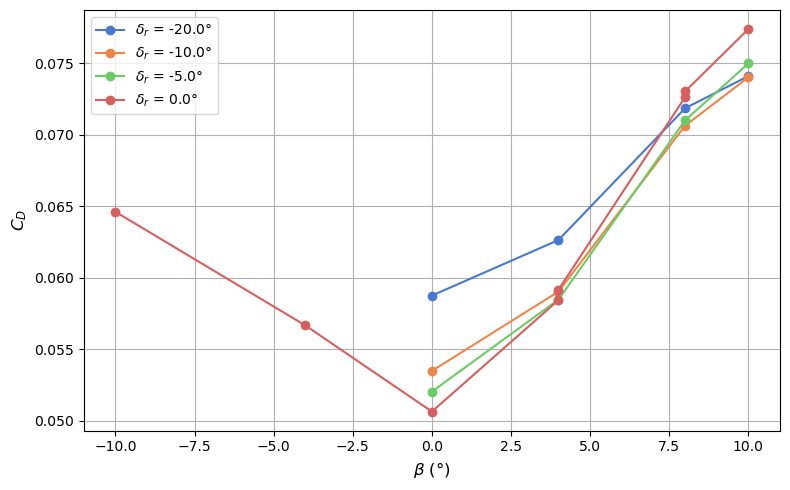

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png


In [1489]:
import matplotlib.pyplot as plt

df_filtered = df[
    (df["V_round"] == 40) &
    (df["AoA_round"] == 2.5) &
    (df["J_round"] == 2)
]

fig, ax = plt.subplots(figsize=(8, 5))

for rudder_val, group in df_filtered.groupby("dR"):
    group_sorted = group.sort_values("AoS_round")
    ax.plot(
        group_sorted["AoS_round"],
        group_sorted["CD_FINAL"],
        marker="o",
        linestyle="-",
        label=fr"$\delta_r$ = {rudder_val}°",
    )

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(r"$C_D$ vs $\beta$ (V = 40 m/s, $\alpha$ = 2.5°, $J$ = 2)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png"), dpi=150)
plt.show()
print(f"Saved to {os.path.join(PLOT_DIR, 'CD_vs_AoS_V40_AoA2.5_J2_all_rudders.png')}")


Prop-on | V=20.0, dR=-10.0: y(beta) = 0.0189*beta + -0.0328 | r = 0.9913, R^2 = 0.9827
  Excluded outlier beta values: [10.0]
Prop-on | V=20.0, dR=0.0: y(beta) = 0.0166*beta + 0.0267 | r = 0.9948, R^2 = 0.9895
  Excluded outlier beta values: [-8.0, 10.0]
Prop-on | V=40.0, dR=-10.0: y(beta) = 0.0185*beta + -0.0272 | r = 0.9969, R^2 = 0.9937
Prop-on | V=40.0, dR=0.0: y(beta) = 0.0186*beta + 0.0134 | r = 0.9991, R^2 = 0.9982
Prop-off | V=40, dR=0: y(beta) = 0.0165*beta + 0.0124 | r = 0.9975, R^2 = 0.9950
  Excluded outlier beta values: [-10.0, 10.0]

(Functions can be accessed via cy_from_aos_funcs[(case, V, dR)](aos))


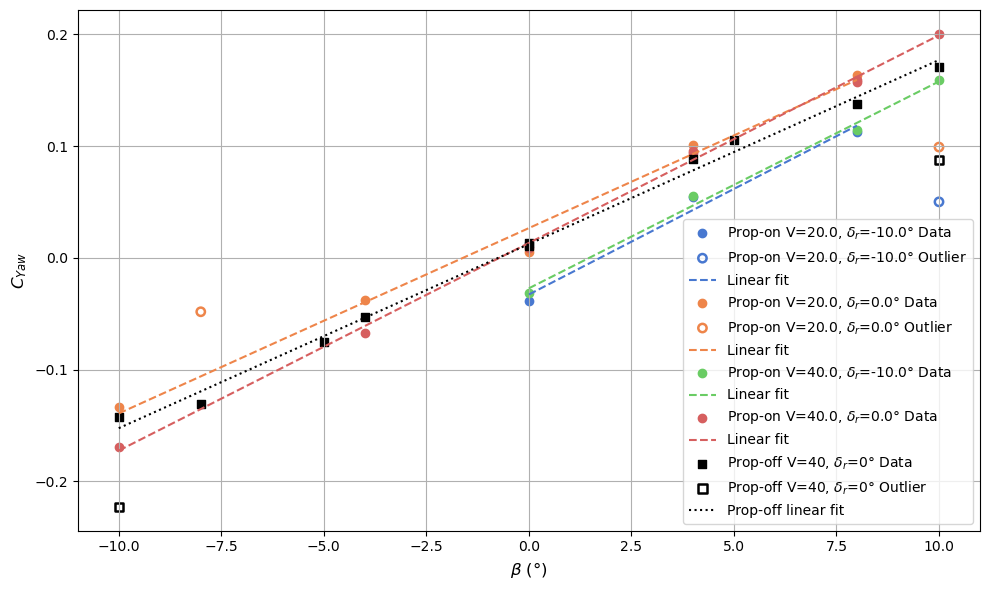

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CY_vs_AoS_with_propOff_V40_rudder0_J2_AoA2.5_linear_fit_outliers_marked.png


In [1490]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure rounded helper columns exist
if "V_round" not in df.columns:
    df["V_round"] = df["V"].round()
if "AoS_round" not in df.columns:
    df["AoS_round"] = df["AoS"].round()
if "AoA_round" not in df.columns:
    df["AoA_round"] = df["AoA"].round(1)

if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()
if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()
if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)

# Prop-on data (same as original cell conditions)
df_on_filtered = df[
    (df["V_round"].isin([20, 40])) &
    (df["dR"].isin([0, -10])) &
    (df["J_round"] == 2) &
    (df["AoA_round"] == 2.5)
]

# Prop-off data requested: same conditions where applicable, V=40 and rudder=0
df_off_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) &
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["dR"] == 0) &
    (df_prop_off["dE"] == 0)
]

def outlier_mask(x, y, case_name, v_val, rudder_val):
    """Return mask of points to exclude from fitting but still plot as hollow markers."""
    mask = np.zeros(len(x), dtype=bool)

    # User-requested outliers for prop-on
    if case_name == "prop_on" and np.isclose(v_val, 20.0) and np.isclose(rudder_val, 0.0):
        mask |= np.isclose(x, -8.0)
        mask |= np.isclose(x, 10.0)
    if case_name == "prop_on" and np.isclose(v_val, 20.0) and np.isclose(rudder_val, -10.0):
        mask |= np.isclose(x, 10.0)

    # User-requested outliers for prop-off: lowest y at beta=-10 and beta=10
    if case_name == "prop_off" and np.isclose(v_val, 40.0) and np.isclose(rudder_val, 0.0):
        for beta_target in (-10.0, 10.0):
            idx = np.where(np.isclose(x, beta_target))[0]
            if len(idx) > 0:
                lowest_idx = idx[np.argmin(y[idx])]
                mask[lowest_idx] = True

    return mask

fig, ax = plt.subplots(figsize=(10, 6))

# Store interpolation functions
cy_from_aos_funcs = {}

# Plot and fit prop-on groups
for (v_val, rudder_val), group in df_on_filtered.groupby(["V_round", "dR"]):
    group_sorted = group.sort_values("AoS_round")
    x = group_sorted["AoS_round"].to_numpy(dtype=float)
    y = group_sorted["CYaw_FINAL"].to_numpy(dtype=float)

    finite_mask = np.isfinite(x) & np.isfinite(y)
    x = x[finite_mask]
    y = y[finite_mask]
    if len(x) < 2:
        continue

    out_mask = outlier_mask(x, y, "prop_on", v_val, rudder_val)
    in_mask = ~out_mask

    if np.sum(in_mask) < 2:
        print(f"Prop-on | V={v_val}, dR={rudder_val}: not enough inlier points for fit.")
        continue

    x_in, y_in = x[in_mask], y[in_mask]

    slope, intercept = np.polyfit(x_in, y_in, 1)
    r_matrix = np.corrcoef(x_in, y_in)
    r_val = r_matrix[0, 1]
    r_squared = r_val**2

    key = ("prop_on", v_val, rudder_val)
    cy_from_aos_funcs[key] = lambda aos, m=slope, c=intercept: m * aos + c

    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0"])
    color = colors[(len(cy_from_aos_funcs) - 1) % len(colors)]

    # Inliers: filled markers
    ax.scatter(
        x_in, y_in,
        marker="o",
        color=color,
        label=fr"Prop-on V={v_val}, $\delta_r$={rudder_val}° Data",
    )

    # Outliers: hollow markers
    if np.any(out_mask):
        x_out, y_out = x[out_mask], y[out_mask]
        ax.scatter(
            x_out, y_out,
            marker="o",
            facecolors="none",
            edgecolors=color,
            linewidths=1.8,
            label=fr"Prop-on V={v_val}, $\delta_r$={rudder_val}° Outlier",
        )

    x_fit = np.linspace(x_in.min(), x_in.max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(
        x_fit, y_fit,
        linestyle="--",
        color=color,
        label=r"Linear fit",
    )

    print(
        f"Prop-on | V={v_val}, dR={rudder_val}: "
        f"y(beta) = {slope:.4f}*beta + {intercept:.4f} | r = {r_val:.4f}, R^2 = {r_squared:.4f}"
    )
    if np.any(out_mask):
        print(f"  Excluded outlier beta values: {x[out_mask].tolist()}")

# Plot and fit prop-off (V=40, dR=0, dE=0)
group_off = df_off_filtered.sort_values("AoS_round")
x_off = group_off["AoS_round"].to_numpy(dtype=float)
y_off = group_off["CYaw_FINAL"].to_numpy(dtype=float)
finite_off = np.isfinite(x_off) & np.isfinite(y_off)
x_off = x_off[finite_off]
y_off = y_off[finite_off]

out_mask_off = outlier_mask(x_off, y_off, "prop_off", 40.0, 0.0)
in_mask_off = ~out_mask_off

if np.sum(in_mask_off) >= 2:
    x_off_in, y_off_in = x_off[in_mask_off], y_off[in_mask_off]
    slope_off, intercept_off = np.polyfit(x_off_in, y_off_in, 1)
    r_matrix_off = np.corrcoef(x_off_in, y_off_in)
    r_val_off = r_matrix_off[0, 1]
    r_squared_off = r_val_off**2

    cy_from_aos_funcs[("prop_off", 40, 0)] = lambda aos, m=slope_off, c=intercept_off: m * aos + c

    # Inliers: filled markers
    ax.scatter(
        x_off_in, y_off_in,
        marker="s",
        color="black",
        label=r"Prop-off V=40, $\delta_r$=0° Data",
    )

    # Outliers: hollow markers
    if np.any(out_mask_off):
        x_off_out, y_off_out = x_off[out_mask_off], y_off[out_mask_off]
        ax.scatter(
            x_off_out, y_off_out,
            marker="s",
            facecolors="none",
            edgecolors="black",
            linewidths=1.8,
            label=r"Prop-off V=40, $\delta_r$=0° Outlier",
        )

    x_fit_off = np.linspace(x_off_in.min(), x_off_in.max(), 100)
    y_fit_off = slope_off * x_fit_off + intercept_off
    ax.plot(
        x_fit_off, y_fit_off,
        linestyle=":",
        color="black",
        label=r"Prop-off linear fit",
    )

    print(
        f"Prop-off | V=40, dR=0: "
        f"y(beta) = {slope_off:.4f}*beta + {intercept_off:.4f} | r = {r_val_off:.4f}, R^2 = {r_squared_off:.4f}"
    )
    if np.any(out_mask_off):
        print(f"  Excluded outlier beta values: {x_off[out_mask_off].tolist()}")
else:
    print("Prop-off | V=40, dR=0: not enough inlier points for linear fit.")

print("\n(Functions can be accessed via cy_from_aos_funcs[(case, V, dR)](aos))")

ax.set_xlabel(r"$\beta$ (°)")
ax.set_ylabel(r"$C_{Yaw}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{Yaw}$ vs $\beta$ ($J$ = 2, $\alpha$ = 2.5°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CY_vs_AoS_with_propOff_V40_rudder0_J2_AoA2.5_linear_fit_outliers_marked.png"), dpi=150)
plt.show()
print(f"Saved to {os.path.join(PLOT_DIR, 'CY_vs_AoS_with_propOff_V40_rudder0_J2_AoA2.5_linear_fit_outliers_marked.png')}")



=== CMpitch interpolation (degree 1) ===
Prop On ($J=1.6$, $\delta_r=0^\circ$): y(alpha) = -0.0219*x + 0.0306 | R^2 = 0.99981
Prop On ($J=2.4$, $\delta_r=0^\circ$): y(alpha) = -0.0176*x + 0.0391 | R^2 = 0.99937
Prop Off ($\delta_r=0^\circ$): y(alpha) = -0.0162*x + 0.0337 | R^2 = 0.98941


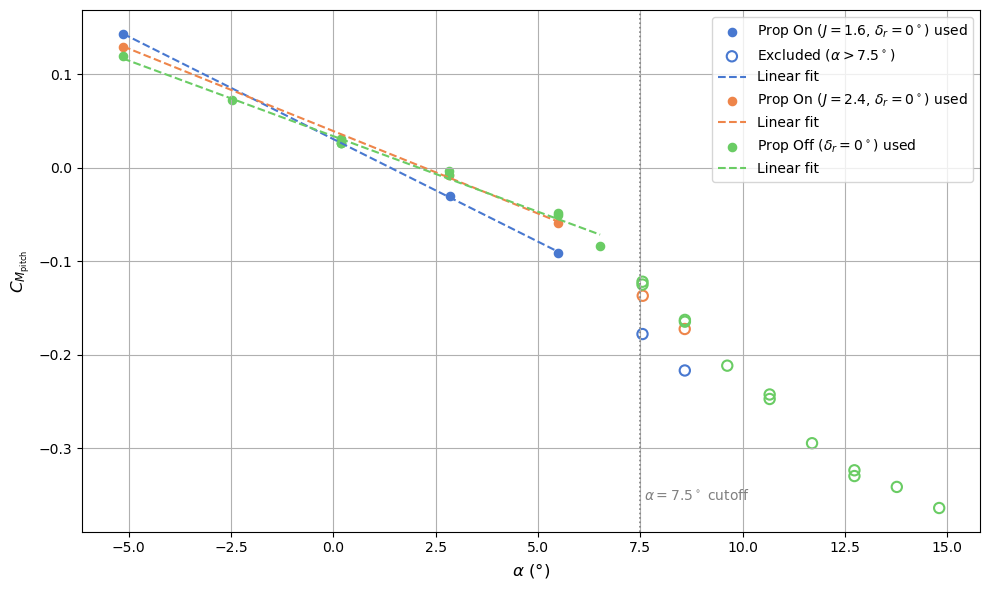

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CMpitch_vs_alpha_V40_AoS0_rudder0_linear_interp_upto7p5.png

Interpolation functions are stored in cm_from_alpha_funcs.
Example usage: cm_from_alpha_funcs[('prop_on', 1.6, 0.0)](4.0)


In [1491]:
import matplotlib.pyplot as plt
import numpy as np

CMPITCH_DEG = 1

# Ensure rounded helper columns exist
if "V_round" not in df.columns:
    df["V_round"] = df["V"].round()
if "AoS_round" not in df.columns:
    df["AoS_round"] = df["AoS"].round()
if "AoA_round" not in df.columns:
    df["AoA_round"] = df["AoA"].round(1)

if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()
if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()
if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)

# --- Conditions from original Cell 11 ---
series_specs = [
    ("prop_on", 1.6, 0.0),
    ("prop_on", 2.4, 0.0),
    ("prop_off", "off", 0.0),
]

alpha_fit_max = 7.5
degree = CMPITCH_DEG

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if np.isclose(ss_tot, 0.0):
        return np.nan
    return 1.0 - ss_res / ss_tot

def poly_eqn_string(coeffs):
    if len(coeffs) == 2:
        return f"{coeffs[0]:.4f}*x + {coeffs[1]:.4f}".replace("+ -", "- ")
    degree_local = len(coeffs) - 1
    terms = []
    for i, c in enumerate(coeffs):
        p = degree_local - i
        if p == 0:
            terms.append(f"{c:.4f}")
        elif p == 1:
            terms.append(f"{c:.4f}*x")
        else:
            terms.append(f"{c:.4f}*x^{p}")
    return " + ".join(terms).replace("+ -", "- ")

cm_from_alpha_funcs = {}
cm_from_alpha_coeffs = {}

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1", "C2"] * 3)
shown_excluded_label = False

print(f"\n=== CMpitch interpolation (degree {degree}) ===")

for idx, (case_name, j_val, rudder_val) in enumerate(series_specs):
    if case_name == "prop_on":
        group = df[
            (df["V_round"] == 40) &
            (df["AoS_round"] == 0) &
            (df["dR"] == rudder_val) &
            (df["J_round"] == j_val)
        ].copy()
        base_label = fr"Prop On ($J={j_val}$, $\delta_r={rudder_val:.0f}^\circ$)"
    else:
        group = df_prop_off[
            (df_prop_off["V_round"] == 40) &
            (df_prop_off["AoS_round"] == 0) &
            (df_prop_off["dE"] == 0) &
            (df_prop_off["dR"] == rudder_val)
        ].copy()
        base_label = r"Prop Off ($\delta_r=0^\circ$)"

    group = group.sort_values("AoA_round")
    x_all = group[AOA_COL].to_numpy(dtype=float)
    y_all = group["CMpitch_FINAL"].to_numpy(dtype=float)

    finite_mask = np.isfinite(x_all) & np.isfinite(y_all)
    x_all = x_all[finite_mask]
    y_all = y_all[finite_mask]
    if len(x_all) < degree + 1:
        print(f"{base_label}: skipped, insufficient valid points.")
        continue

    used_mask = x_all <= alpha_fit_max
    x_used, y_used = x_all[used_mask], y_all[used_mask]
    x_excl, y_excl = x_all[~used_mask], y_all[~used_mask]

    color = colors[idx % len(colors)]

    # Inlier/used points (filled) and excluded points (hollow), matching Cell 6 style
    ax.scatter(x_used, y_used, color=color, s=35, label=base_label + " used")
    if len(x_excl) > 0:
        excl_label = r"Excluded ($\alpha > 7.5^\circ$)" if not shown_excluded_label else None
        ax.scatter(
            x_excl, y_excl,
            facecolors="none",
            edgecolors=color,
            s=55,
            linewidths=1.5,
            label=excl_label,
        )
        shown_excluded_label = True

    if len(x_used) < degree + 1:
        print(
            f"{base_label}: skipped fit, need >= {degree + 1} points with "
            f"alpha <= {alpha_fit_max}"
        )
        continue

    coeffs = np.polyfit(x_used, y_used, degree)
    fit_fn = np.poly1d(coeffs)
    y_hat = fit_fn(x_used)
    r2 = compute_r2(y_used, y_hat)
    eqn = poly_eqn_string(coeffs)

    cm_from_alpha_coeffs[(case_name, j_val, rudder_val)] = coeffs
    cm_from_alpha_funcs[(case_name, j_val, rudder_val)] = (
        lambda alpha, c=coeffs: np.polyval(c, np.asarray(alpha, dtype=float))
    )

    if degree == 1:
        label_l = r"Linear fit"
    elif degree == 2:
        label_l = r"Quadratic fit"

    x_fit = np.linspace(x_used.min(), x_used.max(), 100)
    y_fit = fit_fn(x_fit)
    ax.plot(
        x_fit, y_fit,
        linestyle="--",
        color=color,
        label=label_l,
    )

    print(f"{base_label}: y(alpha) = {eqn} | R^2 = {r2:.5f}")

ax.axvline(alpha_fit_max, color="gray", linestyle=":", linewidth=1.2)
ax.text(
    alpha_fit_max + 0.1,
    ax.get_ylim()[0] + 0.06 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
    r"$\alpha=7.5^\circ$ cutoff",
    color="gray",
)

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{pitch}}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{M_\mathrm{pitch}}$ vs $\alpha$ (linear fit, V = 40 m/s, AoS = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CMpitch_vs_alpha_V40_AoS0_rudder0_linear_interp_upto7p5.png"), dpi=150)
plt.show()
print(f"Saved to {os.path.join(PLOT_DIR, 'CMpitch_vs_alpha_V40_AoS0_rudder0_linear_interp_upto7p5.png')}")

# Update interpolation_meta to confirm this cell used the same AOA_COL
interpolation_meta["AOA_COL_cm"] = AOA_COL

print("\nInterpolation functions are stored in cm_from_alpha_funcs.")
print("Example usage: cm_from_alpha_funcs[('prop_on', 1.6, 0.0)](4.0)")

T_avg   = 289.977 K
rho_avg = 1.215456 kg/m³
mu_avg  = 1.7981e-05 Pa·s
      V_round          V             Re  CL_FINAL
776      20.0  19.994741  223010.738613  0.472066
2177     30.0  29.982692  334411.051566  0.481340
3632     40.0  39.989745  446024.413384  0.484407


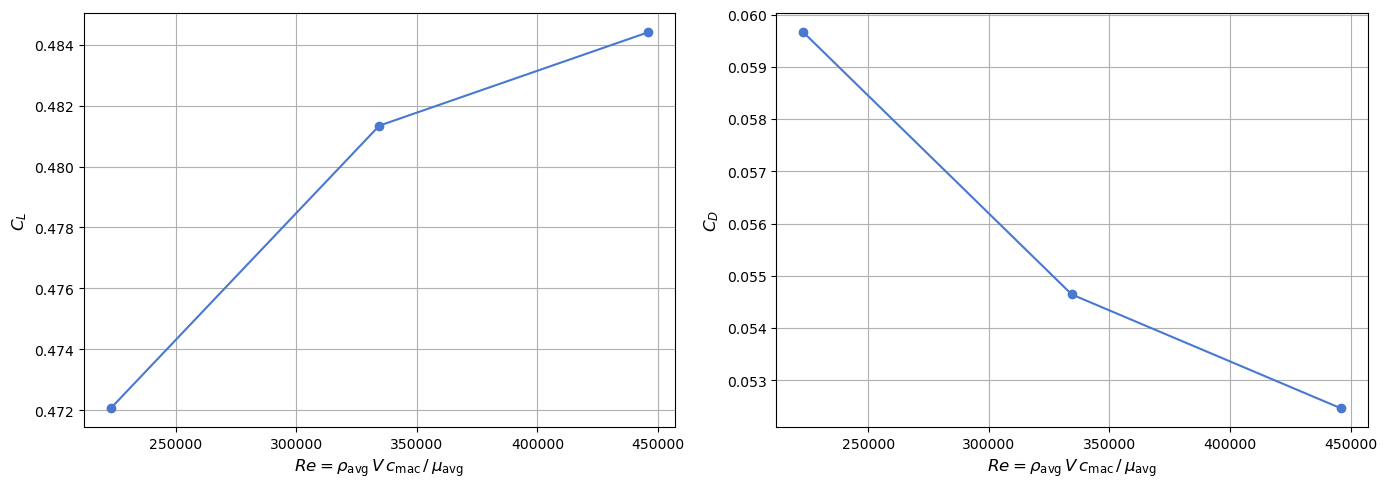

In [1492]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sutherland's law ---
mu_ref = 1.716e-5  # Pa·s
T_ref  = 273.15    # K
S      = 110.4     # K

def sutherland_viscosity(T):
    return mu_ref * (T / T_ref)**1.5 * (T_ref + S) / (T + S)

# --- Representative tunnel conditions (averaged from prop-on data) ---
temps = [
    290.81, 290.5, 290.63, 290.71, 290.45, 290.68, 290.57, 290.54, 290.56,
    290.77, 290.76, 290.54, 290.61, 290.53, 290.53, 290.38, 290.77, 290.42,
    290.82, 290.31, 290.83, 290.77, 290.83, 290.59, 290.69, 289.29, 289.89,
    289.33, 289.37, 289.75, 289.05, 289.33, 289.45, 289.41, 289.41, 289.39,
    289.18, 289.41, 289.48, 289.55, 289.09, 289.4,  289.11, 289.29, 289.24,
    289.39, 289.55, 289.31, 289.75, 289.81, 289.23, 289.71, 289.86, 289.23,
    289.85
]
rhos = [
    1.2111837665772662, 1.2124162911880931, 1.211909932667162,
    1.211564445727421,  1.2134526039979827, 1.2123845995887763,
    1.2128315782593753, 1.213028753275484,  1.2129332677003728,
    1.211985376693565,  1.2120390414597149, 1.2130047723183783,
    1.2127125926478157, 1.213034532873517,  1.2130705055473072,
    1.2136371492818563, 1.212021319675703,  1.2134939840084806,
    1.2117650239582876, 1.2139537833203915, 1.211735336730007,
    1.2113024600329465, 1.2110765180038419, 1.21206476484882,
    1.2116478035619338, 1.2185471305276716, 1.2160731113350067,
    1.2183907064735384, 1.2182343256648152, 1.2166486644737404,
    1.2197155774698278, 1.218474990839042,  1.2179096580800357,
    1.2180779880835713, 1.2180659507882505, 1.218162170535493,
    1.2191672579972812, 1.2181261372648537, 1.2178195442593014,
    1.2175010680190128, 1.219558861881395,  1.2181682287001427,
    1.2194624456700003, 1.2186675534126223, 1.2188902649715678,
    1.2182103230444081, 1.2175251309693753, 1.2184869752778251,
    1.2166486644737404, 1.216432841075817,  1.2187878701265824,
    1.216816646064224,  1.2162230099778601, 1.2187999149132185,
    1.2162289133388524
]

T_avg   = np.mean(temps)
rho_avg = np.mean(rhos)
mu_avg  = sutherland_viscosity(T_avg)

print(f"T_avg   = {T_avg:.3f} K")
print(f"rho_avg = {rho_avg:.6f} kg/m³")
print(f"mu_avg  = {mu_avg:.4e} Pa·s")

# --- Wing MAC from manual ---
c_mac = 0.165  # m

# --- Filter prop-off: alpha=2.5, beta=0, rudder=0, elevator=0 ---
df_re = df_prop_off[
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["AoS_round"] == 0)   &
    (df_prop_off["dR"]        == 0)   &
    (df_prop_off["dE"]        == 0)
].copy()


# Re varies through V; rho and mu are fixed representative averages
df_re["Re"] = rho_avg * df_re["V"] * c_mac / mu_avg
df_re = df_re.sort_values("Re")
# Keep only the lower CL point per velocity (one sweep)
df_re = df_re.loc[df_re.groupby("V_round")["CL_FINAL"].idxmin()]
df_re = df_re.sort_values("Re")

print(df_re[["V_round", "V", "Re", "CL_FINAL"]].to_string())

# --- Plot ---
# fig, ax = plt.subplots(figsize=(8, 5))
# ax.plot(df_re["Re"], df_re["CL_FINAL"], marker="o", linestyle="-")

# ax.set_xlabel(r"$Re = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
# ax.set_ylabel(r"$C_L$")
# ax.set_title(r"$C_L$ vs $Re$ (Prop-off, $\alpha=2.5°$, $\beta=0°$, $\delta_r=0°$, $\delta_e=0°$)")
# ax.grid(True)
# plt.tight_layout()
# plt.savefig(os.path.join(PLOT_DIR, "CL_vs_Re_propoff_AoA2.5.png"), dpi=150)
# plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_re["Re"], df_re["CL_FINAL"], marker="o", linestyle="-")
ax1.set_xlabel(r"$Re = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
ax1.set_ylabel(r"$C_L$")
if SHOW_TITLE:
    ax1.set_title(r"$C_L$ vs $Re$")
ax1.grid(True)

ax2.plot(df_re["Re"], df_re["CD_FINAL"], marker="o", linestyle="-")
ax2.set_xlabel(r"$Re = \rho_\mathrm{avg} \, V \, c_\mathrm{mac} \, / \, \mu_\mathrm{avg}$")
ax2.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax2.set_title(r"$C_D$ vs $Re$")
ax2.grid(True)

if SHOW_TITLE:
    fig.suptitle(r"Prop-off, $\alpha=2.5°$, $\beta=0°$, $\delta_r=0°$, $\delta_e=0°$")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CL_CD_vs_Re_propoff_AoA2.5.png"), dpi=SAVE_RES)
plt.show()


=== CMpitch interpolation per delta_e (degree 1, alpha <= 7.5°) ===
dE =   -20°: y(alpha) = -0.0213*x + 0.5762 | R^2 = 0.99574 | n_used=8, n_excl=8
dE =   -15°: y(alpha) = -0.0180*x + 0.4562 | R^2 = 0.99888 | n_used=8, n_excl=8
dE =   -10°: y(alpha) = -0.0201*x + 0.3217 | R^2 = 0.86142 | n_used=12, n_excl=12
dE =    -5°: y(alpha) = -0.0177*x + 0.1808 | R^2 = 0.99645 | n_used=8, n_excl=8
dE =     0°: y(alpha) = -0.0162*x + 0.0337 | R^2 = 0.98941 | n_used=12, n_excl=12
dE =     5°: y(alpha) = -0.0164*x - 0.1129 | R^2 = 0.99259 | n_used=8, n_excl=8
dE =    10°: y(alpha) = -0.0163*x - 0.2307 | R^2 = 0.97392 | n_used=12, n_excl=12
dE =    15°: y(alpha) = -0.0175*x - 0.3352 | R^2 = 0.99830 | n_used=8, n_excl=8
dE =    20°: y(alpha) = -0.0211*x - 0.4195 | R^2 = 0.99922 | n_used=8, n_excl=8


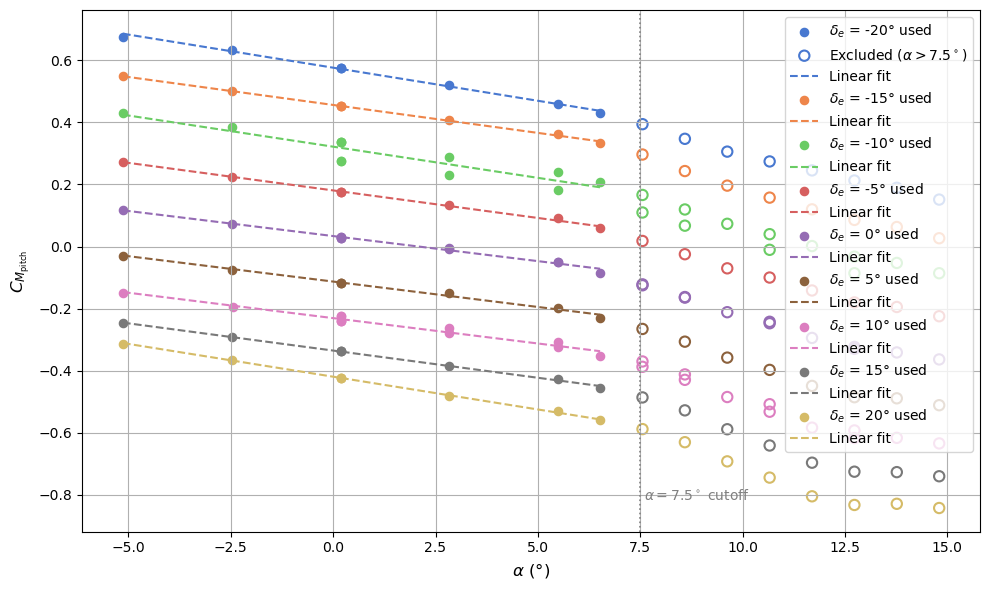


Interpolation functions stored in cm_from_alpha_funcs_de, keyed by delta_e.
Example usage: cm_from_alpha_funcs_de[-10](4.0) for delta_e=-10°


In [1493]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.makedirs(PLOT_DIR, exist_ok=True)

# Ensure rounded helper columns exist
if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()
if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()
if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)

# Base filter: Prop-off, V=40, AoS=0, dR=0
df_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0)
].copy()

alpha_fit_max = 7.5
degree = 1

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if np.isclose(ss_tot, 0.0):
        return np.nan
    return 1.0 - ss_res / ss_tot

def poly_eqn_string(coeffs):
    if len(coeffs) == 2:
        return f"{coeffs[0]:.4f}*x + {coeffs[1]:.4f}".replace("+ -", "- ")
    degree_local = len(coeffs) - 1
    terms = []
    for i, c in enumerate(coeffs):
        p = degree_local - i
        if p == 0:
            terms.append(f"{c:.4f}")
        elif p == 1:
            terms.append(f"{c:.4f}*x")
        else:
            terms.append(f"{c:.4f}*x^{p}")
    return " + ".join(terms).replace("+ -", "- ")

# Dictionaries to store interpolation functions and coefficients per delta_e
cm_from_alpha_funcs_de = {}
cm_from_alpha_coeffs_de = {}

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1", "C2", "C3", "C4", "C5"] * 2)
shown_excluded_label = False

print(f"\n=== CMpitch interpolation per delta_e (degree {degree}, alpha <= {alpha_fit_max}°) ===")

# Get unique elevator deflections sorted
unique_de = sorted(df_filtered["dE"].unique())

for idx, de in enumerate(unique_de):
    group = df_filtered[df_filtered["dE"] == de].copy()
    group = group.sort_values("AoA_round")
    
    x_all = group[AOA_COL].to_numpy(dtype=float)
    y_all = group["CMpitch_FINAL"].to_numpy(dtype=float)
    
    finite_mask = np.isfinite(x_all) & np.isfinite(y_all)
    x_all = x_all[finite_mask]
    y_all = y_all[finite_mask]
    
    if len(x_all) == 0:
        print(f"dE = {de:>5}°: No valid data.")
        continue
    
    base_label = fr"$\delta_e$ = {de}°"
    
    # Split into used (within alpha_fit_max) and excluded (beyond alpha_fit_max)
    used_mask = x_all <= alpha_fit_max
    x_used, y_used = x_all[used_mask], y_all[used_mask]
    x_excl, y_excl = x_all[~used_mask], y_all[~used_mask]
    
    color = colors[idx % len(colors)]
    
    # Plot used points (filled) and excluded points (hollow)
    ax.scatter(x_used, y_used, color=color, s=35, label=base_label + " used")
    if len(x_excl) > 0:
        excl_label = r"Excluded ($\alpha > 7.5^\circ$)" if not shown_excluded_label else None
        ax.scatter(
            x_excl, y_excl,
            facecolors="none",
            edgecolors=color,
            s=55,
            linewidths=1.5,
            label=excl_label,
        )
        shown_excluded_label = True
    
    if len(x_used) < degree + 1:
        print(
            f"dE = {de:>5}°: skipped fit, need >= {degree + 1} points with "
            f"alpha <= {alpha_fit_max}°. Available: {len(x_used)}"
        )
        continue
    
    # Fit using only used points
    coeffs = np.polyfit(x_used, y_used, degree)
    fit_fn = np.poly1d(coeffs)
    y_hat = fit_fn(x_used)
    r2 = compute_r2(y_used, y_hat)
    eqn = poly_eqn_string(coeffs)
    
    # Store functions and coefficients keyed by delta_e
    cm_from_alpha_coeffs_de[de] = coeffs
    cm_from_alpha_funcs_de[de] = (
        lambda alpha, c=coeffs: np.polyval(c, np.asarray(alpha, dtype=float))
    )
    
    # Plot fit line
    x_fit = np.linspace(x_used.min(), x_used.max(), 100)
    y_fit = fit_fn(x_fit)
    ax.plot(
        x_fit, y_fit,
        linestyle="--",
        color=color,
        label=r"Linear fit",
    )
    
    print(f"dE = {de:>5}°: y(alpha) = {eqn} | R^2 = {r2:.5f} | n_used={len(x_used)}, n_excl={len(x_excl)}")

ax.axvline(alpha_fit_max, color="gray", linestyle=":", linewidth=1.2)
ax.text(
    alpha_fit_max + 0.1,
    ax.get_ylim()[0] + 0.06 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
    r"$\alpha=7.5^\circ$ cutoff",
    color="gray",
)

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{pitch}}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{M_\mathrm{pitch}}$ vs $\alpha$ per $\delta_e$ (linear fit, Prop-off, V = 40 m/s, AoS = 0°)")
ax.legend(loc="best")
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CMpitch_vs_alpha_propoff_V40_AoS0_per_elevator_linear_interp_upto7p5.png"), dpi=SAVE_RES)
plt.show()

# Update interpolation_meta
interpolation_meta["AOA_COL_cm_de"] = AOA_COL

print("\nInterpolation functions stored in cm_from_alpha_funcs_de, keyed by delta_e.")
print("Example usage: cm_from_alpha_funcs_de[-10](4.0) for delta_e=-10°")



=== CD interpolation per delta_e (degree 2, alpha <= 7.5 deg) ===
dE =   -20 deg: y(alpha) = 0.0005*x^2 - 0.0011*x + 0.0592 | R^2 = 0.99883 | n_used=8, n_excl=8
dE =   -15 deg: y(alpha) = 0.0005*x^2 - 0.0007*x + 0.0531 | R^2 = 0.99865 | n_used=8, n_excl=8
dE =   -10 deg: y(alpha) = 0.0006*x^2 - 0.0002*x + 0.0489 | R^2 = 0.99567 | n_used=12, n_excl=12
dE =    -5 deg: y(alpha) = 0.0005*x^2 + 0.0004*x + 0.0467 | R^2 = 0.99932 | n_used=8, n_excl=8
dE =     0 deg: y(alpha) = 0.0005*x^2 + 0.0010*x + 0.0456 | R^2 = 0.99944 | n_used=12, n_excl=12
dE =     5 deg: y(alpha) = 0.0005*x^2 + 0.0015*x + 0.0463 | R^2 = 0.99957 | n_used=8, n_excl=8
dE =    10 deg: y(alpha) = 0.0005*x^2 + 0.0021*x + 0.0484 | R^2 = 0.99932 | n_used=12, n_excl=12
dE =    15 deg: y(alpha) = 0.0005*x^2 + 0.0025*x + 0.0513 | R^2 = 0.99964 | n_used=8, n_excl=8
dE =    20 deg: y(alpha) = 0.0005*x^2 + 0.0028*x + 0.0569 | R^2 = 0.99957 | n_used=8, n_excl=8


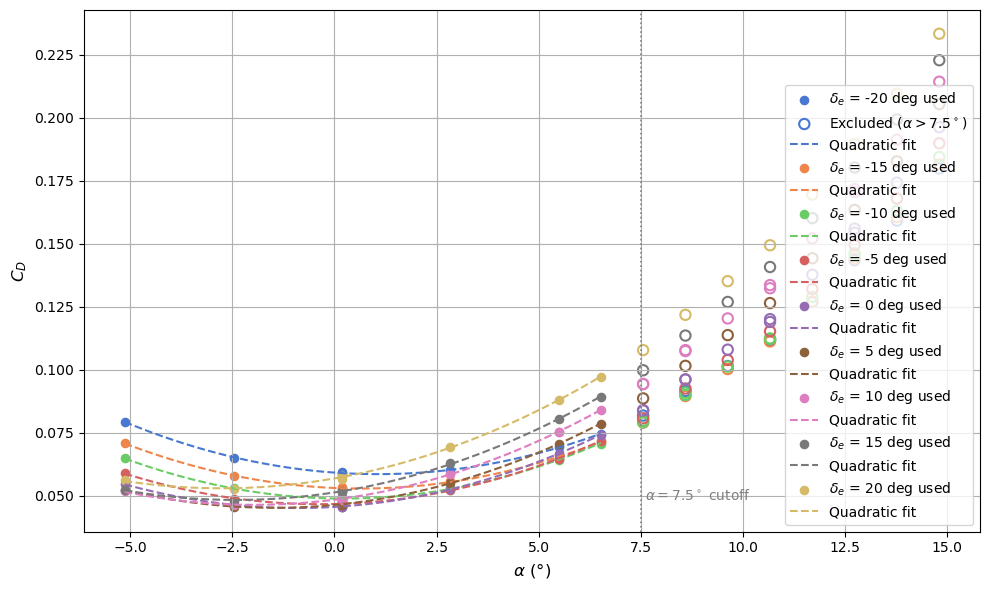


Interpolation functions stored in cd_from_alpha_funcs_de, keyed by delta_e.
Example usage: cd_from_alpha_funcs_de[-10](4.0) for delta_e=-10 deg


In [1494]:
import os
import matplotlib.pyplot as plt
import numpy as np

os.makedirs(PLOT_DIR, exist_ok=True)

# Ensure rounded helper columns exist
if "V_round" not in df_prop_off.columns:
    df_prop_off["V_round"] = df_prop_off["V"].round()
if "AoS_round" not in df_prop_off.columns:
    df_prop_off["AoS_round"] = df_prop_off["AoS"].round()
if "AoA_round" not in df_prop_off.columns:
    df_prop_off["AoA_round"] = df_prop_off["AoA"].round(1)

# Base filter: Prop-off, V=40, AoS=0, dR=0
df_cd_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0)
].copy()

alpha_fit_max = 7.5
degree = 2

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if np.isclose(ss_tot, 0.0):
        return np.nan
    return 1.0 - ss_res / ss_tot

def poly_eqn_string(coeffs):
    degree_local = len(coeffs) - 1
    terms = []
    for i, c in enumerate(coeffs):
        p = degree_local - i
        if p == 0:
            terms.append(f"{c:.4f}")
        elif p == 1:
            terms.append(f"{c:.4f}*x")
        else:
            terms.append(f"{c:.4f}*x^{p}")
    return " + ".join(terms).replace("+ -", "- ")

# Dictionaries to store interpolation functions and coefficients per delta_e
cd_from_alpha_funcs_de = {}
cd_from_alpha_coeffs_de = {}

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1", "C2", "C3", "C4", "C5"] * 2)
shown_excluded_label = False

print(f"\n=== CD interpolation per delta_e (degree {degree}, alpha <= {alpha_fit_max} deg) ===")

# Get unique elevator deflections sorted
unique_de = sorted(df_cd_filtered["dE"].unique())

for idx, de in enumerate(unique_de):
    group = df_cd_filtered[df_cd_filtered["dE"] == de].copy()
    group = group.sort_values("AoA_round")

    x_all = group[AOA_COL].to_numpy(dtype=float)
    y_all = group["CD_FINAL"].to_numpy(dtype=float)

    finite_mask = np.isfinite(x_all) & np.isfinite(y_all)
    x_all = x_all[finite_mask]
    y_all = y_all[finite_mask]

    if len(x_all) == 0:
        print(f"dE = {de:>5} deg: No valid data.")
        continue

    base_label = fr"$\delta_e$ = {de} deg"

    # Split into used (within alpha_fit_max) and excluded (beyond alpha_fit_max)
    used_mask = x_all <= alpha_fit_max
    x_used, y_used = x_all[used_mask], y_all[used_mask]
    x_excl, y_excl = x_all[~used_mask], y_all[~used_mask]

    color = colors[idx % len(colors)]

    # Plot used points (filled) and excluded points (hollow)
    ax.scatter(x_used, y_used, color=color, s=35, label=base_label + " used")
    if len(x_excl) > 0:
        excl_label = r"Excluded ($\alpha > 7.5^\circ$)" if not shown_excluded_label else None
        ax.scatter(
            x_excl, y_excl,
            facecolors="none",
            edgecolors=color,
            s=55,
            linewidths=1.5,
            label=excl_label,
        )
        shown_excluded_label = True

    if len(x_used) < degree + 1:
        print(
            f"dE = {de:>5} deg: skipped fit, need >= {degree + 1} points with "
            f"alpha <= {alpha_fit_max} deg. Available: {len(x_used)}"
        )
        continue

    # Quadratic fit using only used points
    coeffs = np.polyfit(x_used, y_used, degree)
    fit_fn = np.poly1d(coeffs)
    y_hat = fit_fn(x_used)
    r2 = compute_r2(y_used, y_hat)
    eqn = poly_eqn_string(coeffs)

    # Store functions and coefficients keyed by delta_e
    cd_from_alpha_coeffs_de[de] = coeffs
    cd_from_alpha_funcs_de[de] = (
        lambda alpha, c=coeffs: np.polyval(c, np.asarray(alpha, dtype=float))
    )

    # Plot fit line
    x_fit = np.linspace(x_used.min(), x_used.max(), 120)
    y_fit = fit_fn(x_fit)
    ax.plot(
        x_fit, y_fit,
        linestyle="--",
        color=color,
        label=r"Quadratic fit",
    )

    print(f"dE = {de:>5} deg: y(alpha) = {eqn} | R^2 = {r2:.5f} | n_used={len(x_used)}, n_excl={len(x_excl)}")

ax.axvline(alpha_fit_max, color="gray", linestyle=":", linewidth=1.2)
ax.text(
    alpha_fit_max + 0.1,
    ax.get_ylim()[0] + 0.06 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
    r"$\alpha=7.5^\circ$ cutoff",
    color="gray",
)

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(r"$C_D$ vs $\alpha$ per $\delta_e$ (quadratic fit, Prop-off, V = 40 m/s, $\beta$ = 0°)")
ax.legend(loc="best")
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CD_vs_alpha_propoff_V40_AoS0_per_elevator_quadratic_interp_upto7p5.png"), dpi=SAVE_RES)
plt.show()

# Update interpolation_meta
interpolation_meta["AOA_COL_cd_de"] = AOA_COL

print("\nInterpolation functions stored in cd_from_alpha_funcs_de, keyed by delta_e.")
print("Example usage: cd_from_alpha_funcs_de[-10](4.0) for delta_e=-10 deg")

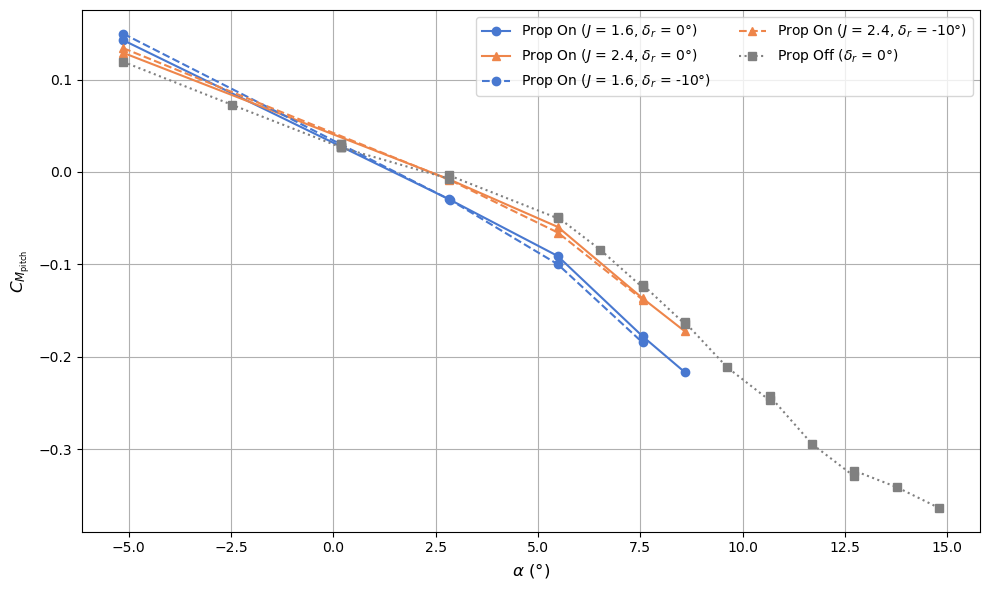

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CMpitch_vs_alpha_V40_AoS0_rudder0_m10.png


In [1495]:
import matplotlib.pyplot as plt

def select_best_sweep(group, gap_threshold=100):
    if group is None or group.empty:
        return group
    
    group = group.sort_index().copy()
    row_jump = group.index.to_series().diff().fillna(0)
    group["sweep_id"] = (row_jump > gap_threshold).cumsum()

    best_block = None
    best_range = -1
    best_npoints = -1

    for _, block in group.groupby("sweep_id"):
        aoa_range = block["AoA"].max() - block["AoA"].min()
        npoints = len(block)

        if (aoa_range > best_range) or (aoa_range == best_range and npoints > best_npoints):
            best_block = block.copy()
            best_range = aoa_range
            best_npoints = npoints

    return best_block

# Filter prop on J=1.6, dR=0
df_on_filtered_16_r0 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == 0) & 
    (df["J_round"] == 1.6)
]
df_on_filtered_16_r0 = select_best_sweep(df_on_filtered_16_r0)
if df_on_filtered_16_r0 is not None: df_on_filtered_16_r0 = df_on_filtered_16_r0.sort_values("AoA_round")

# Filter prop on J=2.4, dR=0
df_on_filtered_24_r0 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == 0) & 
    (df["J_round"] == 2.4)
]
df_on_filtered_24_r0 = select_best_sweep(df_on_filtered_24_r0)
if df_on_filtered_24_r0 is not None: df_on_filtered_24_r0 = df_on_filtered_24_r0.sort_values("AoA_round")

# Filter prop on J=1.6, dR=-10
df_on_filtered_16_rm10 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == -10) & 
    (df["J_round"] == 1.6)
]
df_on_filtered_16_rm10 = select_best_sweep(df_on_filtered_16_rm10)
if df_on_filtered_16_rm10 is not None: df_on_filtered_16_rm10 = df_on_filtered_16_rm10.sort_values("AoA_round")

# Filter prop on J=2.4, dR=-10
df_on_filtered_24_rm10 = df[
    (df["V_round"] == 40) & 
    (df["AoS_round"] == 0) & 
    (df["dR"] == -10) & 
    (df["J_round"] == 2.4)
]
df_on_filtered_24_rm10 = select_best_sweep(df_on_filtered_24_rm10)
if df_on_filtered_24_rm10 is not None: df_on_filtered_24_rm10 = df_on_filtered_24_rm10.sort_values("AoA_round")

# Filter prop off, dR=0
df_off_filtered = df_prop_off[
    (df_prop_off["V_round"] == 40) & 
    (df_prop_off["AoS_round"] == 0) & 
    (df_prop_off["dE"] == 0) &
    (df_prop_off["dR"] == 0)
]
df_off_filtered = select_best_sweep(df_off_filtered)
if df_off_filtered is not None: df_off_filtered = df_off_filtered.sort_values("AoA_round")

fig, ax = plt.subplots(figsize=(10, 6))

if df_on_filtered_16_r0 is not None and not df_on_filtered_16_r0.empty:
    ax.plot(
        df_on_filtered_16_r0[AOA_COL],
        df_on_filtered_16_r0["CMpitch_FINAL"],
        marker="o",
        linestyle="-",
        color=COLORS[0],
        label=r"Prop On ($J$ = 1.6, $\delta_r$ = 0°)"
    )

if df_on_filtered_24_r0 is not None and not df_on_filtered_24_r0.empty:
    ax.plot(
        df_on_filtered_24_r0[AOA_COL],
        df_on_filtered_24_r0["CMpitch_FINAL"],
        marker="^",
        linestyle="-",
        color=COLORS[1],
        label=r"Prop On ($J$ = 2.4, $\delta_r$ = 0°)"
    )

if df_on_filtered_16_rm10 is not None and not df_on_filtered_16_rm10.empty:
    ax.plot(
        df_on_filtered_16_rm10[AOA_COL],
        df_on_filtered_16_rm10["CMpitch_FINAL"],
        marker="o",
        linestyle="--",
        color=COLORS[0],
        label=r"Prop On ($J$ = 1.6, $\delta_r$ = -10°)"
    )

if df_on_filtered_24_rm10 is not None and not df_on_filtered_24_rm10.empty:
    ax.plot(
        df_on_filtered_24_rm10[AOA_COL],
        df_on_filtered_24_rm10["CMpitch_FINAL"],
        marker="^",
        linestyle="--",
        color=COLORS[1],
        label=r"Prop On ($J$ = 2.4, $\delta_r$ = -10°)"
    )

if df_off_filtered is not None and not df_off_filtered.empty:
    ax.plot(
        df_off_filtered[AOA_COL],
        df_off_filtered["CMpitch_FINAL"],
        marker="s",
        linestyle=":",
        color="gray",
        label=r"Prop Off ($\delta_r$ = 0°)"
    )

ax.set_xlabel(r"$\alpha$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{pitch}}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{M_\mathrm{pitch}}$ vs $\alpha$ (V = 40 m/s, AoS = 0°)")
ax.legend(ncol=2)
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CMpitch_vs_alpha_V40_AoS0_rudder0_m10.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved to {os.path.join(PLOT_DIR, 'CMpitch_vs_alpha_V40_AoS0_rudder0_m10.png')}")

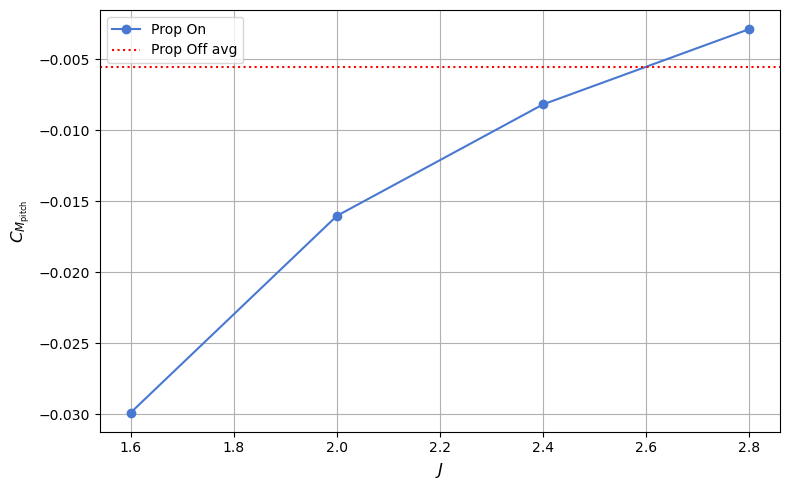

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CMpitch_vs_J_V40_AoS0_AoA2.5_rudder0.png


In [1496]:
import matplotlib.pyplot as plt

# Filter prop on
df_on_j = df[
    (df["V_round"] == 40) & 
    (df["AoA_round"] == 2.5) &
    (df["AoS_round"] == 0) &
    (df["dR"] == 0)
].sort_values("J_round")

# Filter prop off and average
df_off_j = df_prop_off[
    (df_prop_off["V_round"] == 40) & 
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["AoS_round"] == 0) &
    (df_prop_off["dR"] == 0) &
    (df_prop_off["dE"] == 0)
]

cmpitch_off_avg = df_off_j["CMpitch_FINAL"].mean() if not df_off_j.empty else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_on_j["J_round"],
    df_on_j["CMpitch_FINAL"],
    marker="o",
    linestyle="-",
    label="Prop On"
)

if cmpitch_off_avg is not None:
    ax.axhline(
        y=cmpitch_off_avg, 
        color='r', 
        linestyle=':', 
        label="Prop Off avg"
    )

ax.set_xlabel(r"$J$")
ax.set_ylabel(r"$C_{M_\mathrm{pitch}}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{M_\mathrm{pitch}}$ vs $J$ (V = 40 m/s, $\alpha$ = 2.5°, $\beta$ = 0°, $\delta_r$ = 0°)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CMpitch_vs_J_V40_AoS0_AoA2.5_rudder0.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved to {os.path.join(PLOT_DIR, 'CMpitch_vs_J_V40_AoS0_AoA2.5_rudder0.png')}")

# New trim computation

Uses CL = 0.488

## Cell P1 — Build prop-off interpolants

Must run before the prop-on trim chain. Builds `po_cd_dr_funcs`, `po_cm_de_funcs`, `po_cd_de_funcs`, `po_cmyaw_dr_funcs`.

Baseline fits using AOA_COL='AoA_FINAL' (dR=0, dE=0, V=40, AoS=0°, alpha <= 7.5°):
  CL(α):      linear,    R²=0.99948
  CD(α):      quadratic, R²=0.99992
  CMpitch(α): linear,    R²=0.99771

CMpitch(α) per dE built for dE = [-20.0, -15.0, -10.0, -5.0, 0.0, 5.0, 10.0, 15.0, 20.0]
CD(α)      per dE built for dE = [-20.0, -15.0, -10.0, -5.0, 0.0, 5.0, 10.0, 15.0, 20.0]

CMyaw(α)   per dR built for dR = [-20.0, -10.0, 0.0, 10.0, 20.0]
CD(α)      per dR built for dR = [-20.0, -10.0, 0.0, 10.0, 20.0]


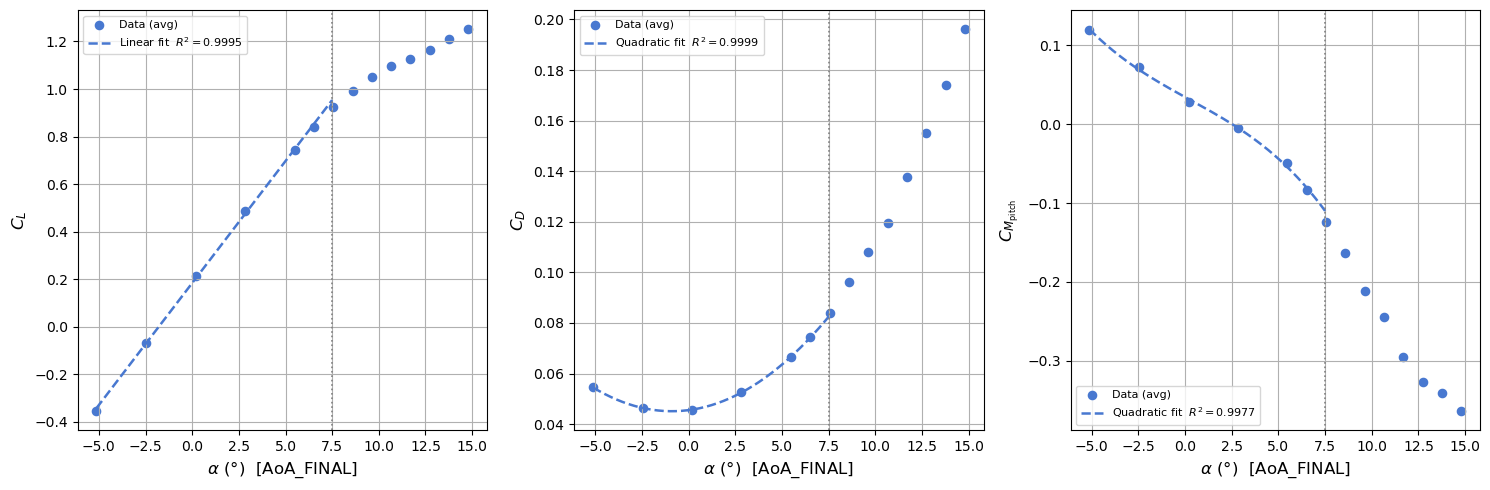

Saved propoff_trim_baseline_CL_CD_CMpitch_vs_alpha.png


In [1497]:
import numpy as np
import matplotlib.pyplot as plt

# ── Ensure rounded columns exist ─────────────────────────────────────────────
for col, src, rnd in [("V_round",   "V",   lambda x: x.round()),
                       ("AoS_round", "AoS", lambda x: x.round()),
                       ("AoA_round", "AoA", lambda x: x.round(1))]:
    if col not in df_prop_off.columns:
        df_prop_off[col] = rnd(df_prop_off[src])

ALPHA_FIT_MAX_PO = 7.5
PO_V    = 40
PO_AOS  = 0
PO_DR   = 0
PO_DE   = 0

# ── AOA_COL consistency check — must match what prop-on cells use ─────────────
if "AOA_COL" not in globals():
    raise RuntimeError("AOA_COL not defined. Run Cell 0 first.")
if AOA_COL not in df_prop_off.columns:
    raise RuntimeError(f"AOA_COL='{AOA_COL}' not found in df_prop_off columns.")

def _r2(y, yhat):
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    return np.nan if np.isclose(ss_tot, 0) else 1 - ss_res/ss_tot

def _fit(x_all, y_all, degree, alpha_max):
    finite = np.isfinite(x_all) & np.isfinite(y_all)
    x_all, y_all = x_all[finite], y_all[finite]
    used = x_all <= alpha_max
    x_u, y_u = x_all[used], y_all[used]
    if len(x_u) < degree + 1:
        return None, None, None
    coeffs = np.polyfit(x_u, y_u, degree)
    fn     = lambda a, c=coeffs: np.polyval(c, np.asarray(a, dtype=float))
    r2     = _r2(y_u, np.polyval(coeffs, x_u))
    return fn, coeffs, r2

# ── 1. Baseline: CL, CD, CMpitch vs AOA_COL at dR=0, dE=0 ───────────────────
df_po_base = df_prop_off[
    (df_prop_off["V_round"]   == PO_V)  &
    (df_prop_off["AoS_round"] == PO_AOS) &
    (df_prop_off["dR"]        == PO_DR) &
    (df_prop_off["dE"]        == PO_DE)
].sort_values("AoA_round")

# Average repeated AoA setpoints — include AOA_COL in the groupby aggregation
df_po_base_avg = df_po_base.groupby("AoA_round")[
    ["CL_FINAL", "CD_FINAL", "CMpitch_FINAL", "CMyaw_FINAL", AOA_COL]
].mean().reset_index()

# Use corrected alpha as x axis — consistent with prop-on Cell 10
x_base = df_po_base_avg[AOA_COL].to_numpy(dtype=float)

po_cl_func,  po_cl_coeffs,  r2_cl = _fit(x_base, df_po_base_avg["CL_FINAL"].to_numpy(),       1, ALPHA_FIT_MAX_PO)
po_cd_func,  po_cd_coeffs,  r2_cd = _fit(x_base, df_po_base_avg["CD_FINAL"].to_numpy(),       2, ALPHA_FIT_MAX_PO)
po_cm_func,  po_cm_coeffs,  r2_cm = _fit(x_base, df_po_base_avg["CMpitch_FINAL"].to_numpy(),  3, ALPHA_FIT_MAX_PO)

print(f"Baseline fits using AOA_COL='{AOA_COL}' "
      f"(dR=0, dE=0, V={PO_V}, AoS={PO_AOS}°, alpha <= {ALPHA_FIT_MAX_PO}°):")
print(f"  CL(α):      linear,    R²={r2_cl:.5f}")
print(f"  CD(α):      quadratic, R²={r2_cd:.5f}")
print(f"  CMpitch(α): linear,    R²={r2_cm:.5f}")

# ── 2. CMpitch and CD vs AOA_COL per dE (dR=0) ───────────────────────────────
df_po_de = df_prop_off[
    (df_prop_off["V_round"]   == PO_V)  &
    (df_prop_off["AoS_round"] == PO_AOS) &
    (df_prop_off["dR"]        == PO_DR)
].copy()

po_cm_de_funcs = {}
po_cd_de_funcs = {}

for de in sorted(df_po_de["dE"].unique()):
    grp = df_po_de[df_po_de["dE"] == de].groupby("AoA_round")[
        ["CMpitch_FINAL", "CD_FINAL", AOA_COL]
    ].mean().reset_index()
    xa = grp[AOA_COL].to_numpy(dtype=float)

    fn_cm, _, _ = _fit(xa, grp["CMpitch_FINAL"].to_numpy(), 1, ALPHA_FIT_MAX_PO)
    fn_cd, _, _ = _fit(xa, grp["CD_FINAL"].to_numpy(),      2, ALPHA_FIT_MAX_PO)
    if fn_cm is not None:
        po_cm_de_funcs[float(de)] = fn_cm
    if fn_cd is not None:
        po_cd_de_funcs[float(de)] = fn_cd

print(f"\nCMpitch(α) per dE built for dE = {sorted(po_cm_de_funcs.keys())}")
print(f"CD(α)      per dE built for dE = {sorted(po_cd_de_funcs.keys())}")

# ── 3. CMyaw and CD vs AOA_COL per dR (dE=0) ─────────────────────────────────
df_po_dr = df_prop_off[
    (df_prop_off["V_round"]   == PO_V)  &
    (df_prop_off["AoS_round"] == PO_AOS) &
    (df_prop_off["dE"]        == PO_DE)
].copy()

po_cmyaw_dr_funcs = {}
po_cd_dr_funcs    = {}

for dr in sorted(df_po_dr["dR"].unique()):
    grp = df_po_dr[df_po_dr["dR"] == dr].groupby("AoA_round")[
        ["CMyaw_FINAL", "CD_FINAL", AOA_COL]
    ].mean().reset_index()
    xa = grp[AOA_COL].to_numpy(dtype=float)

    fn_cy, _, _ = _fit(xa, grp["CMyaw_FINAL"].to_numpy(), 1, ALPHA_FIT_MAX_PO)
    fn_cd, _, _ = _fit(xa, grp["CD_FINAL"].to_numpy(),    2, ALPHA_FIT_MAX_PO)
    if fn_cy is not None:
        po_cmyaw_dr_funcs[float(dr)] = fn_cy
    if fn_cd is not None:
        po_cd_dr_funcs[float(dr)] = fn_cd

print(f"\nCMyaw(α)   per dR built for dR = {sorted(po_cmyaw_dr_funcs.keys())}")
print(f"CD(α)      per dR built for dR = {sorted(po_cd_dr_funcs.keys())}")

# ── Baseline plot: CL, CD, CMpitch vs AOA_COL ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [
    ("CL_FINAL",      po_cl_func, po_cl_coeffs, r2_cl, r"$C_L$",                   1),
    ("CD_FINAL",      po_cd_func, po_cd_coeffs, r2_cd, r"$C_D$",                   2),
    ("CMpitch_FINAL", po_cm_func, po_cm_coeffs, r2_cm, r"$C_{M_\mathrm{pitch}}$",  3),
]
for ax, (col, fn, co, r2, ylabel, deg) in zip(axes, pairs):
    y_base = df_po_base_avg[col].to_numpy(dtype=float)
    ax.scatter(x_base, y_base, s=35, color=COLORS[0], label="Data (avg)")
    x_fit = np.linspace(x_base[x_base <= ALPHA_FIT_MAX_PO].min(),
                        ALPHA_FIT_MAX_PO, 200)
    ax.plot(x_fit, fn(x_fit), "--", color=COLORS[0], lw=1.8,
            label=f"{'Linear' if deg==1 else 'Quadratic'} fit  $R^2={r2:.4f}$")
    ax.axvline(ALPHA_FIT_MAX_PO, color="gray", ls=":", lw=1.2)
    ax.set_xlabel(fr"$\alpha$ (°)  [{AOA_COL}]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend(fontsize=8)

if SHOW_TITLE:
    fig.suptitle(fr"Prop-off baseline: $V={PO_V}$ m/s, AoS=0°, dR=0°, dE=0°  (x-axis: {AOA_COL})")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_trim_baseline_CL_CD_CMpitch_vs_alpha.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved propoff_trim_baseline_CL_CD_CMpitch_vs_alpha.png")

## Prop-on trim

Self-consistent iterative trim: CL target → α → CD_aero → J* → CMpitch → δ_e → refined J* → δ_r

### Cell A — Iterative trim solver

Finds α_trim, CD_aero, J* and CMpitch self-consistently by blending J=1.6 and J=2.4 prop-on sweeps.

Iter        J*   alpha (°)    CD_aero       CT*       Δ J*
──────────────────────────────────────────────────────────
   1    1.8241      2.8073°   0.051988    0.2275   1.76e-01
   2    1.8255      2.7802°   0.051773    0.2269   1.46e-03
   3    1.8255      2.7804°   0.051775    0.2269   1.20e-05
   4    1.8255      2.7804°   0.051775    0.2269   9.80e-08

Converged after 4 iterations.

── Converged aerodynamic trim state ─────────────────────────────────
  CL target     = 0.488
  V             = 40 m/s
  J*            = 1.8255  (blend weight w=0.282 towards J=2.4)
  alpha_trim    = 2.7804°
  CD_aero       = 0.051775  (prop-on, J-blended, no elevator)
  CT*           = 0.2269
  n*            = 107.83 rps  = 6470.0 rpm
  CMpitch       = -0.024608  (prop-on, J-blended)
  target CMpitch (elevator must deliver) = +0.024608
─────────────────────────────────────────────────────────────────────


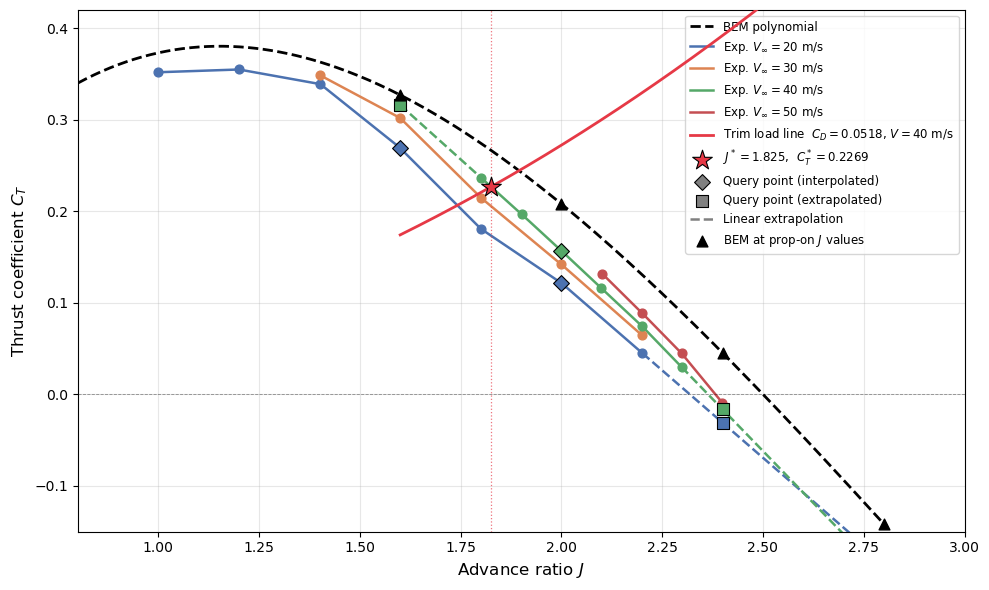

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\CT_trim_intersection_CL0.488_V40.png


In [1498]:
import numpy as np
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# ── Guards ────────────────────────────────────────────────────────────────────
if "interpolation_functions" not in globals():
    raise RuntimeError("interpolation_functions not found. Run Cell 4 first.")
if "cm_from_alpha_funcs" not in globals():
    raise RuntimeError("cm_from_alpha_funcs not found. Run Cell 10 first.")

# ── Inputs ────────────────────────────────────────────────────────────────────
CL_TARGET = 0.488
TRIM_V    = 40
J_LO, J_HI = 1.6, 2.4      # only J values with full alpha sweeps at V=40, dR=0

# ── Geometry constants ────────────────────────────────────────────────────────
WING_AREA = 0.2172
PROP_DIAM = 0.2032
K_LL      = WING_AREA / (4 * PROP_DIAM**2)   # ~1.3151

# ── Experimental CT(J) data ───────────────────────────────────────────────────
_EXP_CT = {
    20: {"J":  [1.000, 1.200, 1.402, 1.598, 1.800, 2.002, 2.201],
         "CT": [0.352, 0.355, 0.339, 0.270, 0.181, 0.121, 0.045]},
    40: {"J":  [1.800, 1.901, 2.000, 2.099, 2.199, 2.298],
         "CT": [0.237, 0.197, 0.157, 0.116, 0.075, 0.030]},
}
J_EXT_MIN, J_EXT_MAX = 1.6, 2.8

def _lin_extrap(Jq, Ja, CTa):
    if Jq <= Ja[0]:
        s = (CTa[1]-CTa[0])/(Ja[1]-Ja[0]); return CTa[0]+s*(Jq-Ja[0])
    elif Jq >= Ja[-1]:
        s = (CTa[-1]-CTa[-2])/(Ja[-1]-Ja[-2]); return CTa[-1]+s*(Jq-Ja[-1])
    return float(np.interp(Jq, Ja, CTa))

def _build_ct_interp(V):
    d  = _EXP_CT[V]
    Ja = np.array(d["J"]); CTa = np.array(d["CT"])
    Jd  = np.linspace(J_EXT_MIN, J_EXT_MAX, 2000)
    CTd = np.array([_lin_extrap(j, Ja, CTa) for j in Jd])
    return interp1d(Jd, CTd, kind="linear", bounds_error=False, fill_value="extrapolate")

def find_J_trim(CD, V):
    ct_fn = _build_ct_interp(V)
    def res(J): return ct_fn(J) - K_LL * CD * J**2
    flo, fhi = res(J_EXT_MIN), res(J_EXT_MAX)
    if flo * fhi > 0:
        return np.nan, np.nan, False
    Js = brentq(res, J_EXT_MIN, J_EXT_MAX, xtol=1e-8)
    return Js, float(ct_fn(Js)), True

# ── Blending helpers (linear between J_LO and J_HI sweeps) ───────────────────
cl_lo = interpolation_functions["CL_FINAL"][(J_LO, 0)]
cl_hi = interpolation_functions["CL_FINAL"][(J_HI, 0)]
cd_lo = interpolation_functions["CD_FINAL"][(J_LO, 0)]
cd_hi = interpolation_functions["CD_FINAL"][(J_HI, 0)]
cm_lo = cm_from_alpha_funcs[("prop_on", J_LO, 0.0)]
cm_hi = cm_from_alpha_funcs[("prop_on", J_HI, 0.0)]

def blend(J_star, f_lo, f_hi, alpha):
    w = (J_star - J_LO) / (J_HI - J_LO)
    return (1 - w) * float(f_lo(alpha)) + w * float(f_hi(alpha))

# ── Iterative solver ──────────────────────────────────────────────────────────
J_star   = 2.0      # initial guess
MAX_ITER = 15
TOL      = 1e-6

print(f"{'Iter':>4}  {'J*':>8}  {'alpha (°)':>10}  {'CD_aero':>9}  {'CT*':>8}  {'Δ J*':>9}")
print("─" * 58)

for i in range(MAX_ITER):
    J_prev = J_star

    # Step 1: invert blended CL(alpha) for trim alpha
    def cl_residual(alpha):
        return blend(J_star, cl_lo, cl_hi, alpha) - CL_TARGET
    alpha_trim = brentq(cl_residual, -10, 12)

    # Step 2: blended CD at trim alpha
    cd_aero = blend(J_star, cd_lo, cd_hi, alpha_trim)

    # Step 3: CT load-line intersection → new J*
    J_new, CT_star, converged = find_J_trim(cd_aero, TRIM_V)
    if not converged:
        print(f"  Iter {i+1}: no CT intersection — CD={cd_aero:.5f} out of prop range.")
        J_star = np.nan
        break

    J_star = float(np.clip(J_new, J_EXT_MIN, J_EXT_MAX))
    delta  = abs(J_star - J_prev)

    print(f"{i+1:>4}  {J_star:>8.4f}  {alpha_trim:>10.4f}°  {cd_aero:>9.6f}  {CT_star:>8.4f}  {delta:>9.2e}")

    if delta < TOL:
        print(f"\nConverged after {i+1} iterations.")
        break
else:
    print("\nWarning: max iterations reached without convergence.")

if J_new < J_LO or J_new > J_HI:
    print(f"Note: J*={J_star:.4f} is outside the measured sweep bracket "
          f"[{J_LO}, {J_HI}] — blending is extrapolated.")

# Step 4: blended CMpitch at converged state
cmpitch_result = blend(J_star, cm_lo, cm_hi, alpha_trim)
target_cmpitch = -cmpitch_result     # elevator must cancel this moment
w_blend        = (J_star - J_LO) / (J_HI - J_LO)

# Expose with original variable names so downstream cells are unchanged
alpha_result   = alpha_trim

print(f"\n── Converged aerodynamic trim state ─────────────────────────────────")
print(f"  CL target     = {CL_TARGET}")
print(f"  V             = {TRIM_V} m/s")
print(f"  J*            = {J_star:.4f}  (blend weight w={w_blend:.3f} towards J={J_HI})")
print(f"  alpha_trim    = {alpha_trim:.4f}°")
print(f"  CD_aero       = {cd_aero:.6f}  (prop-on, J-blended, no elevator)")
print(f"  CT*           = {CT_star:.4f}")
print(f"  n*            = {TRIM_V/(J_star*PROP_DIAM):.2f} rps  "
      f"= {TRIM_V/(J_star*PROP_DIAM)*60:.1f} rpm")
print(f"  CMpitch       = {cmpitch_result:.6f}  (prop-on, J-blended)")
print(f"  target CMpitch (elevator must deliver) = {target_cmpitch:+.6f}")
print(f"─────────────────────────────────────────────────────────────────────")

# ── CT intersection plot (full CT_PLOT.py style) ─────────────────────────────
import matplotlib.pyplot as plt

_EXP_CT_FULL = {
    20: {"J":  [1.000, 1.200, 1.402, 1.598, 1.800, 2.002, 2.201],
         "CT": [0.352, 0.355, 0.339, 0.270, 0.181, 0.121, 0.045]},
    30: {"J":  [1.400, 1.600, 1.800, 2.000, 2.199],
         "CT": [0.349, 0.302, 0.215, 0.142, 0.065]},
    40: {"J":  [1.800, 1.901, 2.000, 2.099, 2.199, 2.298],
         "CT": [0.237, 0.197, 0.157, 0.116, 0.075, 0.030]},
    50: {"J":  [2.101, 2.200, 2.298, 2.399],
         "CT": [0.132, 0.089, 0.045, -0.009]},
}
_CT_COLORS  = {20: "#4C72B0", 30: "#DD8452", 40: "#55A868", 50: "#C44E52"}
_EXTRAP_VS  = {20, 40}
_J_PROPON   = np.array([1.6, 2.0, 2.4, 2.8])

def CT_bem(J):
    return -0.0051*J**4 + 0.0959*J**3 - 0.5888*J**2 + 1.0065*J - 0.1353

fig, ax = plt.subplots(figsize=(10, 6))

# BEM polynomial
J_bem_plot = np.linspace(0.8, J_EXT_MAX, 300)
ax.plot(J_bem_plot, CT_bem(J_bem_plot), "k--", lw=2, label="BEM polynomial", zorder=5)

# All four experimental curves
from scipy.interpolate import interp1d as _interp1d
for V_exp, d in _EXP_CT_FULL.items():
    Ja  = np.array(d["J"]);  CTa = np.array(d["CT"])
    c   = _CT_COLORS[V_exp]
    ax.scatter(Ja, CTa, color=c, s=40, zorder=6)
    Ji  = np.linspace(Ja.min(), Ja.max(), 200)
    ax.plot(Ji, _interp1d(Ja, CTa)(Ji), color=c, lw=1.8,
            label=fr"Exp. $V_\infty={V_exp}$ m/s")
    if V_exp in _EXTRAP_VS:
        ct_fn_v = _build_ct_interp(V_exp)
        if Ja.min() > J_EXT_MIN:
            Jl = np.linspace(J_EXT_MIN, Ja.min(), 80)
            ax.plot(Jl, ct_fn_v(Jl), color=c, lw=1.8, ls="--")
        if Ja.max() < J_EXT_MAX:
            Jr = np.linspace(Ja.max(), J_EXT_MAX, 80)
            ax.plot(Jr, ct_fn_v(Jr), color=c, lw=1.8, ls="--")
        for Jq in _J_PROPON:
            in_raw = Ja.min() <= Jq <= Ja.max()
            in_ext = J_EXT_MIN <= Jq <= J_EXT_MAX
            if in_raw:
                CT_q, mk = float(_interp1d(Ja, CTa)(Jq)), "D"
            elif in_ext:
                CT_q, mk = _lin_extrap(Jq, Ja, CTa), "s"
            else:
                continue
            ax.scatter(Jq, CT_q, color=c, marker=mk, s=65,
                       edgecolors="k", linewidths=0.8, zorder=8)

# BEM at prop-on J points
for Jq in _J_PROPON:
    ax.scatter(Jq, CT_bem(Jq), color="k", marker="^", s=60, edgecolors="k", zorder=9)

# Trim load line
J_ll   = np.linspace(J_EXT_MIN, J_EXT_MAX, 400)
CT_ll  = K_LL * cd_aero * J_ll**2
ax.plot(J_ll, CT_ll, color="#E63946", lw=2, ls="-", zorder=7,
        label=fr"Trim load line  $C_D={cd_aero:.4f}$, $V={TRIM_V}$ m/s")

# Intersection star
ax.scatter(J_star, CT_star, color="#E63946", marker="*", s=220,
           edgecolors="k", linewidths=0.8, zorder=10,
           label=fr"$J^*={J_star:.3f}$,  $C_T^*={CT_star:.4f}$")
ax.axvline(J_star, color="#E63946", lw=0.9, ls=":", alpha=0.7)

# Proxy legend handles
ax.scatter([], [], color="grey", marker="D", s=65, edgecolors="k",
           linewidths=0.8, label="Query point (interpolated)")
ax.scatter([], [], color="grey", marker="s", s=65, edgecolors="k",
           linewidths=0.8, label="Query point (extrapolated)")
ax.plot([], [], color="grey", lw=1.8, ls="--", label="Linear extrapolation")
ax.scatter([], [], color="k", marker="^", s=60, label=r"BEM at prop-on $J$ values")

ax.axhline(0, color="k", lw=0.6, ls="--", alpha=0.4)
ax.set_xlabel(r"Advance ratio $J$", fontsize=12)
ax.set_ylabel(r"Thrust coefficient $C_T$", fontsize=12)
if SHOW_TITLE:
    ax.set_title(
        fr"Powered trim: $C_L={CL_TARGET}$, $V={TRIM_V}$ m/s, "
        fr"$\alpha={alpha_trim:.2f}°$  →  $J^*={J_star:.3f}$"
    )
ax.legend(fontsize=8.5, loc="upper right")
ax.set_xlim(0.8, 3.0)
ax.set_ylim(-0.15, 0.42)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, f"CT_trim_intersection_CL{CL_TARGET}_V{TRIM_V}.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved to {os.path.join(PLOT_DIR, f'CT_trim_intersection_CL{CL_TARGET}_V{TRIM_V}.png')}")



### Cell B — Elevator deflection for pitch trim

Inverts prop-off CMpitch(dE) at α_trim to find δ_e* that delivers target CMpitch.

Trim alpha: 2.7804°
Target CMpitch (from prop-on at J*): +0.024608

Prop-off CMpitch at trim alpha per elevator deflection:
  dE= -20.0°  ->  CMpitch=+0.516921
  dE= -15.0°  ->  CMpitch=+0.406082
  dE= -10.0°  ->  CMpitch=+0.265839
  dE=  -5.0°  ->  CMpitch=+0.131416
  dE=   0.0°  ->  CMpitch=-0.011223
  dE=   5.0°  ->  CMpitch=-0.158433
  dE=  10.0°  ->  CMpitch=-0.276148
  dE=  15.0°  ->  CMpitch=-0.383988
  dE=  20.0°  ->  CMpitch=-0.478168

Linear fit: CMpitch = -0.025748·dE + 0.001366  |  R²=0.99682


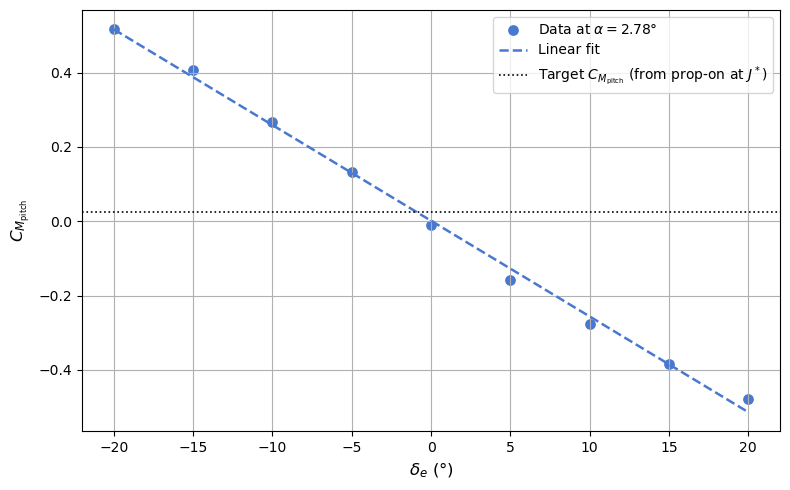

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\delta_e_vs_CMpitch_at_trim_alpha_propon.png

Trim elevator:  dE_trim = -0.9026°
Check: CMpitch(dE_trim) = +0.024608  (target: +0.024608)


In [1499]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

if "alpha_result" not in globals():
    raise RuntimeError("alpha_result not defined. Run Cell E first.")
if "target_cmpitch" not in globals():
    raise RuntimeError("target_cmpitch not defined. Run Cell E first.")
if "cm_from_alpha_funcs_de" not in globals() or len(cm_from_alpha_funcs_de) == 0:
    raise RuntimeError("cm_from_alpha_funcs_de empty. Run Cell 12 first.")

trim_alpha = float(alpha_result)

# Evaluate prop-off CMpitch(alpha) for each elevator deflection at trim alpha
delta_e_values, cmpitch_values = [], []
for de in sorted(cm_from_alpha_funcs_de.keys()):
    delta_e_values.append(float(de))
    cmpitch_values.append(float(cm_from_alpha_funcs_de[de](trim_alpha)))

x_de = np.asarray(delta_e_values, dtype=float)
y_cm = np.asarray(cmpitch_values,  dtype=float)

print(f"Trim alpha: {trim_alpha:.4f}°")
print(f"Target CMpitch (from prop-on at J*): {target_cmpitch:+.6f}")
print("\nProp-off CMpitch at trim alpha per elevator deflection:")
for de, cm in zip(x_de, y_cm):
    print(f"  dE={de:>6.1f}°  ->  CMpitch={cm:+.6f}")

# Linear fit: CMpitch(dE)
coeffs_de_cm = np.polyfit(x_de, y_cm, 1)
fit_de_to_cm = np.poly1d(coeffs_de_cm)
a_de_cm, b_de_cm = coeffs_de_cm
y_hat   = fit_de_to_cm(x_de)
ss_res  = np.sum((y_cm - y_hat)**2)
ss_tot  = np.sum((y_cm - y_cm.mean())**2)
r2_de_cm = np.nan if np.isclose(ss_tot, 0) else 1 - ss_res/ss_tot
print(f"\nLinear fit: CMpitch = {a_de_cm:.6f}·dE + {b_de_cm:.6f}  |  R²={r2_de_cm:.5f}")

# Plot
x_plot = np.linspace(x_de.min(), x_de.max(), 300)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_de, y_cm, s=45, label=fr"Data at $\alpha={trim_alpha:.2f}°$")
ax.plot(x_plot, fit_de_to_cm(x_plot), "--", lw=1.8, label="Linear fit")
ax.axhline(target_cmpitch, color="black", ls=":", lw=1.2,
           label=r"Target $C_{M_\mathrm{pitch}}$ (from prop-on at $J^*$)")
ax.set_xlabel(r"$\delta_e$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{pitch}}$")
if SHOW_TITLE:
    ax.set_title(fr"$\delta_e$ vs $C_{{M_\mathrm{{pitch}}}}$ at $\alpha={trim_alpha:.2f}°$ (prop-off elevator effectiveness)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "delta_e_vs_CMpitch_at_trim_alpha_propon.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved to {os.path.join(PLOT_DIR, 'delta_e_vs_CMpitch_at_trim_alpha_propon.png')}")

# Invert to find trim elevator
def f_root(de): return fit_de_to_cm(de) - target_cmpitch
de_min, de_max = float(x_de.min()), float(x_de.max())
flo, fhi = f_root(de_min), f_root(de_max)

if   np.isclose(flo, 0): delta_e_trim = de_min
elif np.isclose(fhi, 0): delta_e_trim = de_max
elif flo * fhi < 0:       delta_e_trim = brentq(f_root, de_min, de_max)
else:
    delta_e_trim = (target_cmpitch - b_de_cm) / a_de_cm if not np.isclose(a_de_cm, 0) else np.nan

cmpitch_check = float(fit_de_to_cm(delta_e_trim)) if np.isfinite(delta_e_trim) else np.nan
print(f"\nTrim elevator:  dE_trim = {delta_e_trim:+.4f}°")
print(f"Check: CMpitch(dE_trim) = {cmpitch_check:+.6f}  (target: {target_cmpitch:+.6f})")
if np.isfinite(delta_e_trim) and (delta_e_trim < de_min or delta_e_trim > de_max):
    print(f"Warning: dE_trim outside data range [{de_min:.1f}, {de_max:.1f}]° — extrapolated.")

### Cell C — CD vs elevator at trim alpha (diagnostic)

Shows prop-off CD(dE) at α_trim. Diagnostic only — used to compute ΔCD_elevator.

Alpha used: 2.7804°

Prop-off CD at trim alpha per elevator deflection:
  dE= -20.0°  ->  CD=0.060146
  dE= -15.0°  ->  CD=0.055294
  dE= -10.0°  ->  CD=0.052518
  dE=  -5.0°  ->  CD=0.051860
  dE=   0.0°  ->  CD=0.052298
  dE=   5.0°  ->  CD=0.054676
  dE=  10.0°  ->  CD=0.058194
  dE=  15.0°  ->  CD=0.062205
  dE=  20.0°  ->  CD=0.068758


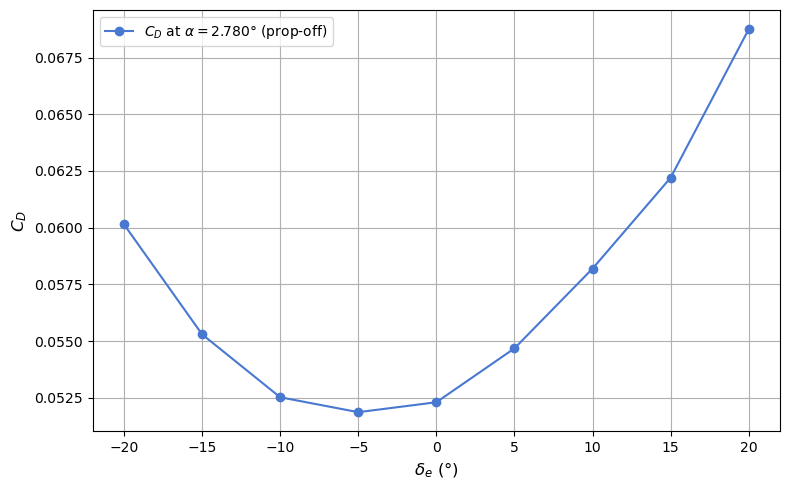

Saved to c:\Users\douwe\AE4115-23_EXPERIMENTAL SIMULATIONS\Group_15_Redo_BAL\new_plot_images\delta_e_vs_CD_at_alpha_result_propon.png


In [1500]:
import numpy as np
import matplotlib.pyplot as plt

if "alpha_result" not in globals():
    raise RuntimeError("alpha_result not defined. Run Cell E first.")
if "cd_from_alpha_funcs_de" not in globals() or len(cd_from_alpha_funcs_de) == 0:
    raise RuntimeError("cd_from_alpha_funcs_de empty. Run Cell 13 first.")

alpha_for_cd = float(alpha_result)

de_values, cd_values = [], []
for de in sorted(cd_from_alpha_funcs_de.keys()):
    de_values.append(float(de))
    cd_values.append(float(cd_from_alpha_funcs_de[de](alpha_for_cd)))

x_de = np.asarray(de_values, dtype=float)
y_cd = np.asarray(cd_values, dtype=float)

print(f"Alpha used: {alpha_for_cd:.4f}°")
print("\nProp-off CD at trim alpha per elevator deflection:")
for de, cd in zip(x_de, y_cd):
    print(f"  dE={de:>6.1f}°  ->  CD={cd:.6f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_de, y_cd, marker="o", ls="-",
        label=fr"$C_D$ at $\alpha={alpha_for_cd:.3f}°$ (prop-off)")
ax.set_xlabel(r"$\delta_e$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(fr"$\delta_e$ vs $C_D$ at $\alpha={alpha_for_cd:.3f}°$ (prop-off)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "delta_e_vs_CD_at_alpha_result_propon.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved to {os.path.join(PLOT_DIR, 'delta_e_vs_CD_at_alpha_result_propon.png')}")

### Cell D — Trim CD with elevator penalty and refined J*

Adds ΔCD_elevator to CD_aero and re-solves J* with CD_total.

Alpha used:     2.7804°
Quadratic fit:  CD(dE) = 0.00002983·dE² + 0.00023116·dE + 0.05235636  |  R²=0.995258
dE_trim:        -0.9026°
CD at dE_trim:  0.052172
CD at dE=0:     0.052356
ΔCD (elevator): -0.000184


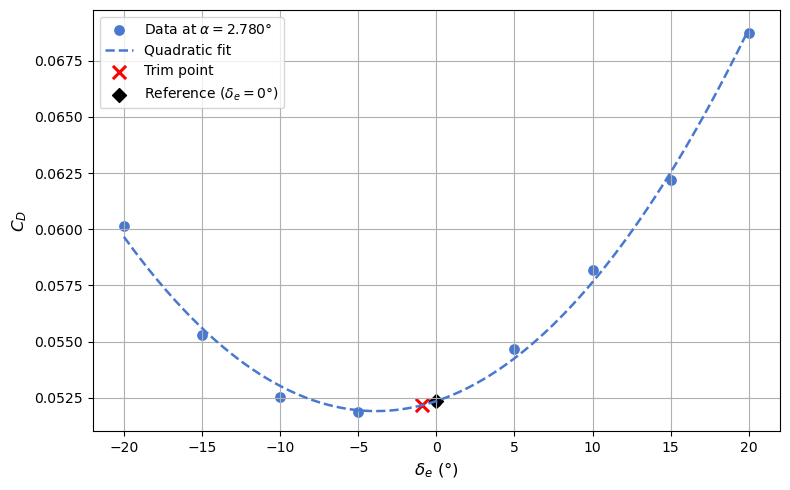

Saved delta_e_vs_CD_quadratic_at_alpha_result_with_trim_point.png

── Total trim CD and refined J* ──────────────────────────────────────
  CD_aero       (prop-on, J-blended)  = 0.051775
  ΔCD_elevator  (prop-off, dE=-0.90°) = -0.000184
  CD_total_trim                        = 0.051591
  J* refined    (incl. elevator drag)  = 1.8268
  CT* refined                          = 0.2264
  n* refined    = 107.76 rps  = 6465.6 rpm
─────────────────────────────────────────────────────────────────────


In [1501]:
import numpy as np
import matplotlib.pyplot as plt

if "alpha_result" not in globals():
    raise RuntimeError("alpha_result not defined. Run Cell A first.")
if "delta_e_trim" not in globals() or not np.isfinite(delta_e_trim):
    raise RuntimeError("delta_e_trim invalid. Run Cell B first.")
if "cd_aero" not in globals():
    raise RuntimeError("cd_aero not defined. Run Cell A first.")
if "cd_from_alpha_funcs_de" not in globals() or len(cd_from_alpha_funcs_de) == 0:
    raise RuntimeError("cd_from_alpha_funcs_de empty. Run Cell 13 first.")

alpha_for_cd = float(alpha_result)
de_trim      = float(delta_e_trim)
de_ref       = 0.0

# Prop-off CD(dE) at trim alpha — quadratic fit
de_vals = np.asarray(sorted(cd_from_alpha_funcs_de.keys()), dtype=float)
cd_vals = np.asarray([float(cd_from_alpha_funcs_de[de](alpha_for_cd)) for de in de_vals])

coeffs_cd_de  = np.polyfit(de_vals, cd_vals, 2)
fit_cd_from_de = np.poly1d(coeffs_cd_de)
cd_at_de_trim  = float(fit_cd_from_de(de_trim))
cd_at_de0      = float(fit_cd_from_de(de_ref))
delta_cd_elev  = cd_at_de_trim - cd_at_de0

cd_hat  = fit_cd_from_de(de_vals)
ss_res  = np.sum((cd_vals - cd_hat)**2)
ss_tot  = np.sum((cd_vals - cd_vals.mean())**2)
r2_cd_de = np.nan if np.isclose(ss_tot, 0) else 1 - ss_res/ss_tot

a_cd, b_cd, c_cd = coeffs_cd_de
print(f"Alpha used:     {alpha_for_cd:.4f}°")
print(f"Quadratic fit:  CD(dE) = {a_cd:.8f}·dE² + {b_cd:.8f}·dE + {c_cd:.8f}  |  R²={r2_cd_de:.6f}")
print(f"dE_trim:        {de_trim:+.4f}°")
print(f"CD at dE_trim:  {cd_at_de_trim:.6f}")
print(f"CD at dE=0:     {cd_at_de0:.6f}")
print(f"ΔCD (elevator): {delta_cd_elev:+.6f}")

# Plot
x_fit = np.linspace(de_vals.min(), de_vals.max(), 300)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(de_vals, cd_vals, s=45, label=fr"Data at $\alpha={alpha_for_cd:.3f}°$")
ax.plot(x_fit, fit_cd_from_de(x_fit), "--", lw=1.8, label="Quadratic fit")
ax.scatter([de_trim], [cd_at_de_trim], marker="x", s=90, lw=2.2,
           color="red",   label="Trim point")
ax.scatter([de_ref],  [cd_at_de0],    marker="D", s=50,
           color="black", label=r"Reference ($\delta_e=0°$)")
ax.set_xlabel(r"$\delta_e$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(fr"Quadratic $\delta_e$–$C_D$ at $\alpha={alpha_for_cd:.3f}°$ (prop-off)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "delta_e_vs_CD_quadratic_at_alpha_result_with_trim_point.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved delta_e_vs_CD_quadratic_at_alpha_result_with_trim_point.png")

# Total trim CD and refined J*
cd_total_trim = cd_aero + delta_cd_elev
J_star_refined, CT_star_refined, conv = find_J_trim(cd_total_trim, TRIM_V)

print(f"\n── Total trim CD and refined J* ──────────────────────────────────────")
print(f"  CD_aero       (prop-on, J-blended)  = {cd_aero:.6f}")
print(f"  ΔCD_elevator  (prop-off, dE={de_trim:+.2f}°) = {delta_cd_elev:+.6f}")
print(f"  CD_total_trim                        = {cd_total_trim:.6f}")
if conv:
    print(f"  J* refined    (incl. elevator drag)  = {J_star_refined:.4f}")
    print(f"  CT* refined                          = {CT_star_refined:.4f}")
    print(f"  n* refined    = {TRIM_V/(J_star_refined*PROP_DIAM):.2f} rps"
          f"  = {TRIM_V/(J_star_refined*PROP_DIAM)*60:.1f} rpm")
    J_star = J_star_refined
else:
    print("  Warning: no CT intersection for CD_total — J_star not updated.")
print(f"─────────────────────────────────────────────────────────────────────")


### Cell E — Yaw trim: find δ_r*

Evaluates CMyaw at J* for dR=0 and dR=−10 (prop-on data, AoA=2.5°), interpolates to find dR that zeros CMyaw.

In [1502]:
import numpy as np

if "J_star" not in globals() or not np.isfinite(J_star):
    raise RuntimeError("J_star not defined. Run Cell H first.")
if "cmyaw_from_j_funcs" not in globals() or len(cmyaw_from_j_funcs) == 0:
    raise RuntimeError("cmyaw_from_j_funcs not available. Run Cell 5 first.")

rudder_values = [-10.0, 0.0]
cmyaw_at_j    = {dr: float(cmyaw_from_j_funcs[dr](J_star)) for dr in rudder_values}
cm_rm10       = cmyaw_at_j[-10.0]
cm_r0         = cmyaw_at_j[0.0]

if np.isclose(cm_r0 - cm_rm10, 0.0):
    raise RuntimeError("CMyaw values identical across rudder range — cannot interpolate.")

dr_for_cmyaw_zero = -10.0 + (0.0 - cm_rm10) * (0.0 - (-10.0)) / (cm_r0 - cm_rm10)

print(f"Using J* = {J_star:.4f} (self-consistent trim, incl. elevator drag)")
print(f"\nCMyaw at J* from linear J-interpolation:")
print(f"  dR = -10.0°  ->  CMyaw = {cm_rm10:+.6f}")
print(f"  dR =   0.0°  ->  CMyaw = {cm_r0:+.6f}")
print(f"\nTrim rudder for CMyaw = 0:")
print(f"  dR_trim = {dr_for_cmyaw_zero:+.4f}°")

Using J* = 1.8268 (self-consistent trim, incl. elevator drag)

CMyaw at J* from linear J-interpolation:
  dR = -10.0°  ->  CMyaw = +0.013139
  dR =   0.0°  ->  CMyaw = -0.004624

Trim rudder for CMyaw = 0:
  dR_trim = -2.6032°


### Cell F — Rudder CD penalty

Uses prop-off CD(dR) at α_trim (same source as prop-off case) so ΔCD_rudder differences reflect only different dR_trim.

J=1.6: CD(dR) = -0.000282·dR + 0.051872
  CD at dR=0:     0.051872
  CD at dR_trim:  0.052606
  ΔCD:            +0.000734
J=2.0: CD(dR) = -0.000284·dR + 0.050654
  CD at dR=0:     0.050654
  CD at dR_trim:  0.051394
  ΔCD:            +0.000740

Blend weight w=0.567 at J*=1.8268
CD at dR=0    (J-blended): 0.051181
CD at dR_trim (J-blended): 0.051919
ΔCD_rudder (prop-on):      +0.000737


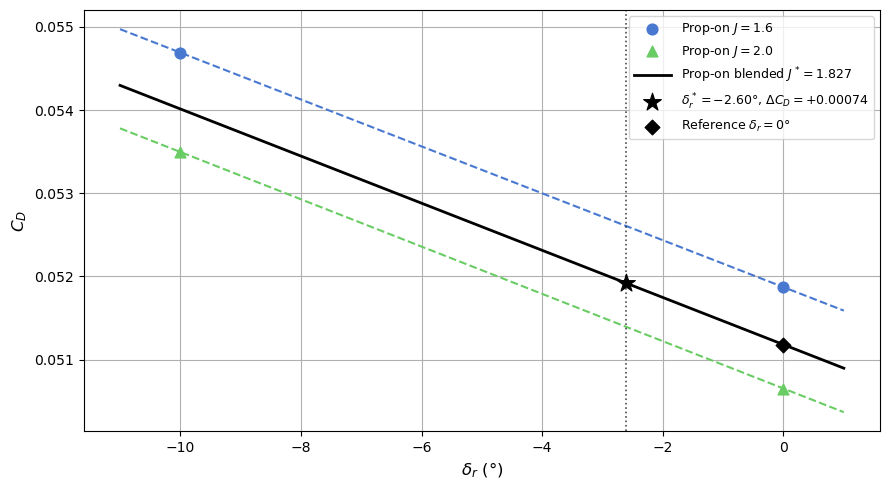

Saved propon_trim_dR_vs_CD_Jblended.png

── Full trim CD budget ───────────────────────────────────────────────
  CD_aero       (prop-on, J-blended)              = 0.051775
  ΔCD_elevator  (dE=-0.90°)                    = -0.000184
  ΔCD_rudder    (dR=-2.60°, prop-on J-blended)   = +0.000737
  CD_grand_total                                   = 0.052328
─────────────────────────────────────────────────────────────────────


In [1503]:
import numpy as np
import matplotlib.pyplot as plt

if "dr_for_cmyaw_zero" not in globals() or not np.isfinite(dr_for_cmyaw_zero):
    raise RuntimeError("dr_for_cmyaw_zero not available. Run Cell E first.")
if "J_star" not in globals() or not np.isfinite(J_star):
    raise RuntimeError("J_star not defined. Run Cell D first.")
if "alpha_result" not in globals():
    raise RuntimeError("alpha_result not defined. Run Cell A first.")

# ── Prop-on CD(dR) at AoA=2.5, dR=-10 and 0, V=40, AoS=0 ───────────────────
# Use J=1.6 and J=2.4 (full alpha sweeps available) — same bracket as trim solver
DR_BRACKET = [-10.0, 0.0]
J_LO_DR, J_HI_DR = 1.6, 2.0

df_on_dr = df[
    (df["V_round"]   == 40) &
    (df["AoS_round"] == 0)  &
    (df["AoA_round"] == 2.5) &
    (df["dR"].isin(DR_BRACKET)) &
    (df["J_round"].isin([J_LO_DR, J_HI_DR]))
][["dR", "J_round", "CD_FINAL"]].sort_values(["J_round", "dR"])

dR_trim = float(dr_for_cmyaw_zero)

# Linear fit CD(dR) per J and evaluate at dR_trim and dR=0
cd_results = {}   # {J: {"slope": , "intercept": , "cd_trim": , "cd_0": , "dcd": }}
for j_val, grp in df_on_dr.groupby("J_round"):
    x = grp["dR"].to_numpy(dtype=float)
    y = grp["CD_FINAL"].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    cd_trim_j = slope * dR_trim + intercept
    cd_0_j    = intercept                      # at dR=0, intercept = CD(0)
    cd_results[j_val] = {
        "slope": slope, "intercept": intercept,
        "cd_trim": cd_trim_j, "cd_0": cd_0_j,
        "dcd": cd_trim_j - cd_0_j
    }
    print(f"J={j_val}: CD(dR) = {slope:.6f}·dR + {intercept:.6f}")
    print(f"  CD at dR=0:     {cd_0_j:.6f}")
    print(f"  CD at dR_trim:  {cd_trim_j:.6f}")
    print(f"  ΔCD:            {cd_trim_j - cd_0_j:+.6f}")

# Blend between J=1.6 and J=2.4 at J*
w = (J_star - J_LO_DR) / (J_HI_DR - J_LO_DR)
cd_0_on    = (1 - w) * cd_results[J_LO_DR]["cd_0"]    + w * cd_results[J_HI_DR]["cd_0"]
cd_trim_on = (1 - w) * cd_results[J_LO_DR]["cd_trim"] + w * cd_results[J_HI_DR]["cd_trim"]
delta_cd_rudder = cd_trim_on - cd_0_on

print(f"\nBlend weight w={w:.3f} at J*={J_star:.4f}")
print(f"CD at dR=0    (J-blended): {cd_0_on:.6f}")
print(f"CD at dR_trim (J-blended): {cd_trim_on:.6f}")
print(f"ΔCD_rudder (prop-on):      {delta_cd_rudder:+.6f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
x_fit = np.linspace(-11, 1, 300)
j_colors  = {J_LO_DR: COLORS[0], J_HI_DR: COLORS[2]}
j_markers = {J_LO_DR: "o",       J_HI_DR: "^"}

fig, ax = plt.subplots(figsize=(9, 5))

for j_val, res in cd_results.items():
    c  = j_colors[j_val]
    mk = j_markers[j_val]
    grp = df_on_dr[df_on_dr["J_round"] == j_val]
    ax.scatter(grp["dR"], grp["CD_FINAL"], color=c, marker=mk, s=60, zorder=6,
               label=fr"Prop-on $J={j_val}$")
    ax.plot(x_fit, res["slope"] * x_fit + res["intercept"],
            color=c, ls="--", lw=1.5)

# Blended J* line
slope_blend     = (1-w)*cd_results[J_LO_DR]["slope"]     + w*cd_results[J_HI_DR]["slope"]
intercept_blend = (1-w)*cd_results[J_LO_DR]["intercept"] + w*cd_results[J_HI_DR]["intercept"]
ax.plot(x_fit, slope_blend * x_fit + intercept_blend,
        color="k", ls="-", lw=2,
        label=fr"Prop-on blended $J^*={J_star:.3f}$")

# Trim intersection
ax.scatter([dR_trim], [cd_trim_on], color="k", marker="*", s=180,
           edgecolors="k", linewidths=0.8, zorder=9,
           label=fr"$\delta_r^*={dR_trim:+.2f}°$, $\Delta C_D={delta_cd_rudder:+.5f}$")
ax.scatter([0.0], [cd_0_on], color="k", marker="D", s=55, zorder=8,
           label=r"Reference $\delta_r=0°$")
ax.axvline(dR_trim, color="k", ls=":", lw=1.2, alpha=0.7)

ax.set_xlabel(r"$\delta_r$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(
        fr"Prop-on $\Delta C_D$ (rudder): J-blended at $J^*={J_star:.3f}$"
        "\n"
        r"($V=40$ m/s, AoS=0°, AoA=2.5°, $\delta_r=-10°$ and $0°$)"
    )
ax.legend(fontsize=9, handlelength=3)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propon_trim_dR_vs_CD_Jblended.png"), dpi=SAVE_RES)
plt.show()
print("Saved propon_trim_dR_vs_CD_Jblended.png")

# Budget summary
if "cd_total_trim" in globals():
    cd_grand_total = cd_total_trim + delta_cd_rudder
    print(f"\n── Full trim CD budget ───────────────────────────────────────────────")
    print(f"  CD_aero       (prop-on, J-blended)              = {cd_aero:.6f}")
    print(f"  ΔCD_elevator  (dE={delta_e_trim:+.2f}°)                    = {delta_cd_elev:+.6f}")
    print(f"  ΔCD_rudder    (dR={dR_trim:+.2f}°, prop-on J-blended)   = {delta_cd_rudder:+.6f}")
    print(f"  CD_grand_total                                   = {cd_grand_total:.6f}")
    print(f"─────────────────────────────────────────────────────────────────────")

## Prop-off trim

Full trim for the unpowered case: α from CL (or specified directly), CMpitch balance → δ_e, CMyaw balance → δ_r. All from prop-off data at V=40, AoS=0.

### Cell P2 — Find α_trim, CD and CMpitch at baseline

Set `TRIM_MODE_PO = 'CL'` to invert from CL target, or `'alpha'` to specify α directly.

In [1504]:
import numpy as np

if "po_cl_func" not in globals():
    raise RuntimeError("Run Cell P1 first.")

# ── Input mode — choose ONE ───────────────────────────────────────────────────
TRIM_MODE_PO  = "CL"    # "CL" → specify CL_TARGET_PO
                           # "alpha" → specify ALPHA_TARGET_PO

CL_TARGET_PO    = 0.488    # used when TRIM_MODE_PO == "CL"
ALPHA_TARGET_PO = 2.7804     # used when TRIM_MODE_PO == "alpha"

# ── Resolve alpha_trim_po ─────────────────────────────────────────────────────
if TRIM_MODE_PO == "CL":
    a_cl, b_cl = po_cl_coeffs
    if np.isclose(a_cl, 0):
        raise RuntimeError("CL slope is zero — cannot invert.")
    alpha_trim_po = (CL_TARGET_PO - b_cl) / a_cl
    cl_achieved   = float(po_cl_func(alpha_trim_po))
    print(f"Mode: CL → alpha")
    print(f"  CL target   = {CL_TARGET_PO}")
    print(f"  alpha_trim  = {alpha_trim_po:.4f}°")
    print(f"  Check CL    = {cl_achieved:.5f}")

elif TRIM_MODE_PO == "alpha":
    alpha_trim_po = float(ALPHA_TARGET_PO)
    cl_achieved   = float(po_cl_func(alpha_trim_po))
    print(f"Mode: alpha specified directly")
    print(f"  alpha_trim  = {alpha_trim_po:.4f}°")
    print(f"  CL at alpha = {cl_achieved:.5f}")

else:
    raise ValueError(f"TRIM_MODE_PO must be 'CL' or 'alpha', got '{TRIM_MODE_PO}'.")

# ── Evaluate baseline aero quantities at trim alpha ───────────────────────────
cd_trim_po_base    = float(po_cd_func(alpha_trim_po))
cm_trim_po_base    = float(po_cm_func(alpha_trim_po))
target_cmpitch_po  = -cm_trim_po_base
target_cmyaw_po    = 0.0    # always trim to zero yaw moment

print(f"\nBaseline (dR=0, dE=0):")
print(f"  CD          = {cd_trim_po_base:.6f}")
print(f"  CMpitch     = {cm_trim_po_base:.6f}  → elevator must deliver {target_cmpitch_po:+.6f}")
print(f"  CL          = {cl_achieved:.5f}")

Mode: CL → alpha
  CL target   = 0.488
  alpha_trim  = 2.9621°
  Check CL    = 0.48800

Baseline (dR=0, dE=0):
  CD          = 0.053005
  CMpitch     = -0.006806  → elevator must deliver +0.006806
  CL          = 0.48800


### Cell P3 — Elevator trim: find δ_e*

Inverts prop-off CMpitch(dE) at α_trim_po to find the elevator deflection that zeros CMpitch.

CMpitch at alpha=2.9621° per elevator deflection:
  dE=-20.0°  ->  CMpitch=+0.512029
  dE=-15.0°  ->  CMpitch=+0.403076
  dE=-10.0°  ->  CMpitch=+0.266625
  dE= -5.0°  ->  CMpitch=+0.128864
  dE=  0.0°  ->  CMpitch=-0.015150
  dE=  5.0°  ->  CMpitch=-0.161054
  dE= 10.0°  ->  CMpitch=-0.281699
  dE= 15.0°  ->  CMpitch=-0.387366
  dE= 20.0°  ->  CMpitch=-0.481992

Linear fit: CMpitch = -0.025780·dE + -0.001852  |  R²=0.99671

Target CMpitch (elevator must deliver): +0.006806
Trim elevator: dE_trim = -0.3358°


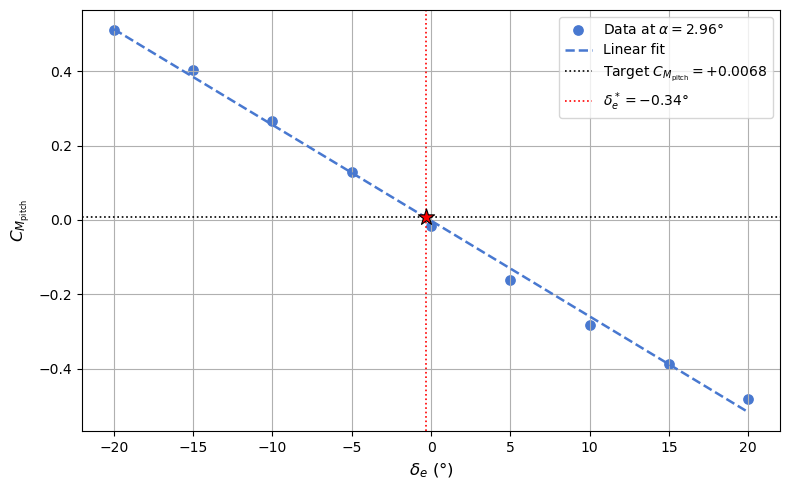

Saved propoff_trim_dE_vs_CMpitch.png


In [1505]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

if "alpha_trim_po" not in globals():
    raise RuntimeError("Run Cell P2 first.")

# Evaluate CMpitch at trim alpha for each dE
de_vals_po = np.array(sorted(po_cm_de_funcs.keys()), dtype=float)
cm_at_de   = np.array([po_cm_de_funcs[de](alpha_trim_po) for de in de_vals_po])

print(f"CMpitch at alpha={alpha_trim_po:.4f}° per elevator deflection:")
for de, cm in zip(de_vals_po, cm_at_de):
    print(f"  dE={de:>5.1f}°  ->  CMpitch={cm:+.6f}")

# Linear fit CMpitch(dE)
coeffs_cm_de_po = np.polyfit(de_vals_po, cm_at_de, 1)
fit_cm_de_po    = np.poly1d(coeffs_cm_de_po)
a_cm, b_cm      = coeffs_cm_de_po
r2_cm_de        = _r2(cm_at_de, fit_cm_de_po(de_vals_po))
print(f"\nLinear fit: CMpitch = {a_cm:.6f}·dE + {b_cm:.6f}  |  R²={r2_cm_de:.5f}")

# Invert for trim dE
def f_de(de): return fit_cm_de_po(de) - target_cmpitch_po
de_min, de_max = float(de_vals_po.min()), float(de_vals_po.max())
flo, fhi = f_de(de_min), f_de(de_max)
if   np.isclose(flo, 0):    dE_trim_po = de_min
elif np.isclose(fhi, 0):    dE_trim_po = de_max
elif flo * fhi < 0:         dE_trim_po = brentq(f_de, de_min, de_max)
else:                        dE_trim_po = (target_cmpitch_po - b_cm) / a_cm

print(f"\nTarget CMpitch (elevator must deliver): {target_cmpitch_po:+.6f}")
print(f"Trim elevator: dE_trim = {dE_trim_po:+.4f}°")
if dE_trim_po < de_min or dE_trim_po > de_max:
    print(f"Warning: outside data range [{de_min:.1f}, {de_max:.1f}]° — extrapolated.")

# Plot
x_plot = np.linspace(de_min, de_max, 300)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(de_vals_po, cm_at_de, s=45, color=COLORS[0],
           label=fr"Data at $\alpha={alpha_trim_po:.2f}°$")
ax.plot(x_plot, fit_cm_de_po(x_plot), "--", lw=1.8, color=COLORS[0],
        label="Linear fit")
ax.axhline(target_cmpitch_po, color="black", ls=":", lw=1.2,
           label=fr"Target $C_{{M_\mathrm{{pitch}}}}={target_cmpitch_po:+.4f}$")
ax.axvline(dE_trim_po, color="red", ls=":", lw=1.2,
           label=fr"$\delta_e^*={dE_trim_po:+.2f}°$")
ax.scatter([dE_trim_po], [target_cmpitch_po], color="red", marker="*",
           s=150, zorder=9, edgecolors="k", linewidths=0.8)
ax.set_xlabel(r"$\delta_e$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{pitch}}$")
if SHOW_TITLE:
    ax.set_title(fr"Prop-off pitch trim: $\alpha={alpha_trim_po:.2f}°$, $V={PO_V}$ m/s")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_trim_dE_vs_CMpitch.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved propoff_trim_dE_vs_CMpitch.png")

### Cell P4 — CD penalty from elevator deflection

Evaluates prop-off CD(dE) at α_trim_po at dE* and dE=0. ΔCD_elevator = CD(dE*) − CD(0).

Quadratic fit CD(dE): R²=0.99580
CD at dE=0:           0.053094
CD at dE_trim=-0.34°: 0.053014
ΔCD (elevator):       -0.000080


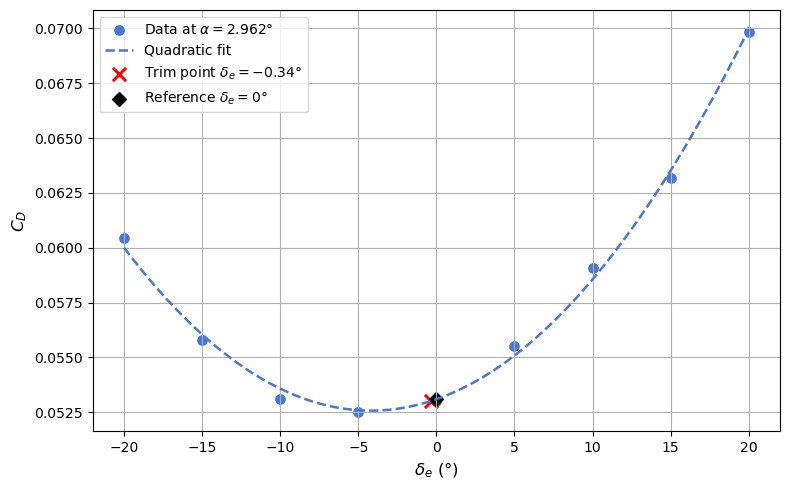

Saved propoff_trim_dE_vs_CD.png


In [1506]:
import numpy as np
import matplotlib.pyplot as plt

if "dE_trim_po" not in globals():
    raise RuntimeError("Run Cell P3 first.")

# CD at trim alpha per dE — quadratic fit
de_vals_cd  = np.array(sorted(po_cd_de_funcs.keys()), dtype=float)
cd_at_de    = np.array([po_cd_de_funcs[de](alpha_trim_po) for de in de_vals_cd])

coeffs_cd_de_po = np.polyfit(de_vals_cd, cd_at_de, 2)
fit_cd_de_po    = np.poly1d(coeffs_cd_de_po)
r2_cd_de_po     = _r2(cd_at_de, fit_cd_de_po(de_vals_cd))

cd_at_de_trim_po = float(fit_cd_de_po(dE_trim_po))
cd_at_de0_po     = float(fit_cd_de_po(0.0))
delta_cd_elev_po = cd_at_de_trim_po - cd_at_de0_po

print(f"Quadratic fit CD(dE): R²={r2_cd_de_po:.5f}")
print(f"CD at dE=0:           {cd_at_de0_po:.6f}")
print(f"CD at dE_trim={dE_trim_po:+.2f}°: {cd_at_de_trim_po:.6f}")
print(f"ΔCD (elevator):       {delta_cd_elev_po:+.6f}")

# Plot
x_fit = np.linspace(de_vals_cd.min(), de_vals_cd.max(), 300)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(de_vals_cd, cd_at_de, s=45, color=COLORS[0],
           label=fr"Data at $\alpha={alpha_trim_po:.3f}°$")
ax.plot(x_fit, fit_cd_de_po(x_fit), "--", lw=1.8, color=COLORS[0],
        label="Quadratic fit")
ax.scatter([dE_trim_po], [cd_at_de_trim_po], color="red", marker="x",
           s=90, lw=2.2, label=fr"Trim point $\delta_e={dE_trim_po:+.2f}°$")
ax.scatter([0.0], [cd_at_de0_po], color="black", marker="D",
           s=50, label=r"Reference $\delta_e=0°$")
ax.set_xlabel(r"$\delta_e$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(fr"Prop-off $C_D$ vs $\delta_e$ at $\alpha={alpha_trim_po:.2f}°$, $V={PO_V}$ m/s")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_trim_dE_vs_CD.png"), dpi=150)
plt.show()
print(f"Saved propoff_trim_dE_vs_CD.png")

### Cell P5 — Rudder trim: find δ_r*

Uses prop-off CMyaw(α) at dR=−10 and dR=0 to find the rudder deflection that zeros CMyaw. Same two-point interpolation method as prop-on Cell E.

CMyaw at alpha=2.9621° (bracketing points only):
  dR=-10.0°  ->  CMyaw=+0.009083
  dR=  0.0°  ->  CMyaw=-0.005878

Local linear interpolation: CMyaw = -0.001496·dR + -0.005878
Trim rudder: dR_trim = -3.9290°

All dR values for context:
  dR=-20.0°  ->  CMyaw=+0.005485
  dR=-10.0°  ->  CMyaw=+0.009083
  dR=  0.0°  ->  CMyaw=-0.005878
  dR= 10.0°  ->  CMyaw=-0.019694
  dR= 20.0°  ->  CMyaw=-0.035798


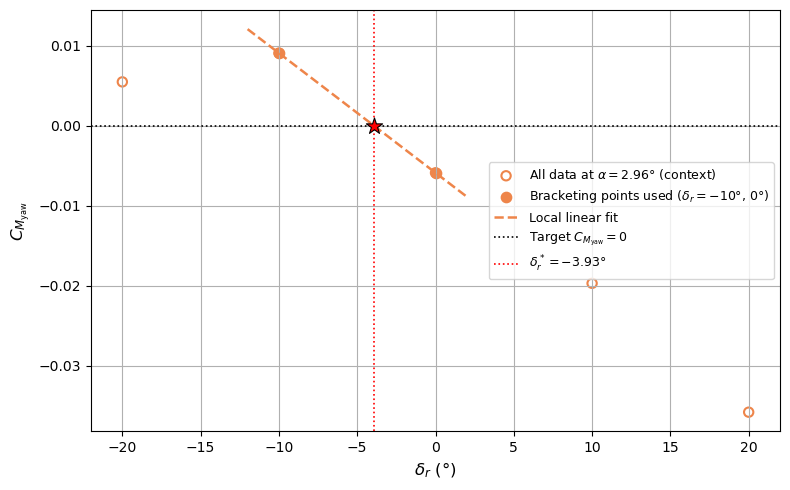

Saved propoff_trim_dR_vs_CMyaw.png


In [1507]:
import numpy as np
import matplotlib.pyplot as plt

if "alpha_trim_po" not in globals():
    raise RuntimeError("Run Cell P2 first.")

# ── Use only dR=-10 and dR=0 to bracket the zero crossing ────────────────────
# (same approach as prop-on Cell I — local linear interpolation between the
#  two points that bracket CMyaw=0, avoids nonlinearity at large dR values)
dr_bracket = np.array([-10.0, 0.0])
cy_bracket  = np.array([po_cmyaw_dr_funcs[dr](alpha_trim_po) for dr in dr_bracket])

a_cy       = (cy_bracket[1] - cy_bracket[0]) / (dr_bracket[1] - dr_bracket[0])
b_cy       = cy_bracket[0] - a_cy * dr_bracket[0]
dR_trim_po = -b_cy / a_cy

print(f"CMyaw at alpha={alpha_trim_po:.4f}° (bracketing points only):")
for dr, cy in zip(dr_bracket, cy_bracket):
    print(f"  dR={dr:>5.1f}°  ->  CMyaw={cy:+.6f}")
print(f"\nLocal linear interpolation: CMyaw = {a_cy:.6f}·dR + {b_cy:.6f}")
print(f"Trim rudder: dR_trim = {dR_trim_po:+.4f}°")

# ── Also compute for all dR values (for plotting context only) ────────────────
dr_vals_po = np.array(sorted(po_cmyaw_dr_funcs.keys()), dtype=float)
cy_at_dr   = np.array([po_cmyaw_dr_funcs[dr](alpha_trim_po) for dr in dr_vals_po])

print(f"\nAll dR values for context:")
for dr, cy in zip(dr_vals_po, cy_at_dr):
    print(f"  dR={dr:>5.1f}°  ->  CMyaw={cy:+.6f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
x_bracket = np.linspace(-12, 2, 300)
fit_line   = a_cy * x_bracket + b_cy

fig, ax = plt.subplots(figsize=(8, 5))

# All data points for context (hollow)
ax.scatter(dr_vals_po, cy_at_dr, s=45, color=COLORS[1],
           facecolors="none", edgecolors=COLORS[1], linewidths=1.5,
           label=fr"All data at $\alpha={alpha_trim_po:.2f}°$ (context)")

# Bracketing points used for fit (filled)
ax.scatter(dr_bracket, cy_bracket, s=55, color=COLORS[1],
           label=r"Bracketing points used ($\delta_r=-10°$, $0°$)")

# Local linear fit through bracketing points only
ax.plot(x_bracket, fit_line, "--", lw=1.8, color=COLORS[1],
        label="Local linear fit")

ax.axhline(0, color="black", ls=":", lw=1.2, label=r"Target $C_{M_\mathrm{yaw}}=0$")
ax.axvline(dR_trim_po, color="red", ls=":", lw=1.2,
           label=fr"$\delta_r^*={dR_trim_po:+.2f}°$")
ax.scatter([dR_trim_po], [0.0], color="red", marker="*",
           s=150, zorder=9, edgecolors="k", linewidths=0.8)

ax.set_xlabel(r"$\delta_r$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{yaw}}$")
if SHOW_TITLE:
    ax.set_title(fr"Prop-off yaw trim: $\alpha={alpha_trim_po:.2f}°$, $V={PO_V}$ m/s")
ax.grid(True)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_trim_dR_vs_CMyaw.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved propoff_trim_dR_vs_CMyaw.png")

### Cell P6 — Rudder CD penalty and full trim budget

Evaluates prop-off CD(dR) at α_trim_po at dR* and dR=0. Prints full CD budget.

Prop-off CD(dR) linear fit (dR=-10° and 0°, averaged): R²=1.00000
  dR=-10°  ->  CD=0.054348
  dR=  0°  ->  CD=0.052613

dR_trim:        -3.9290°
CD at dR=0:     0.052613
CD at dR_trim:  0.053295
ΔCD_rudder:     +0.000681


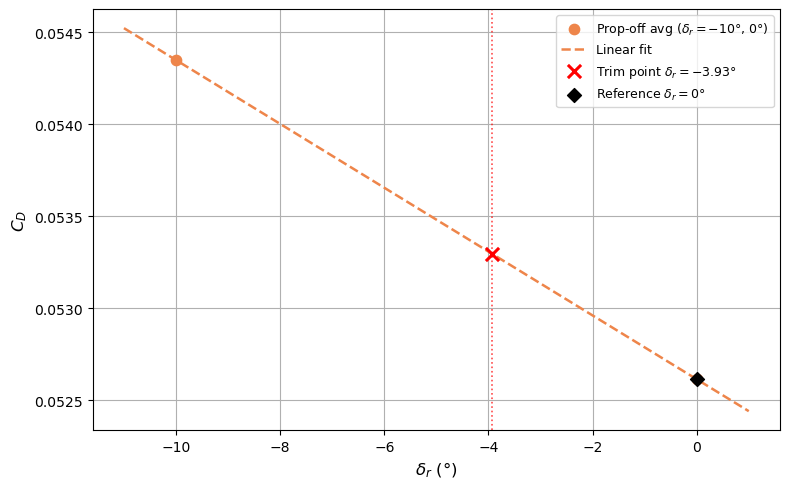

Saved propoff_trim_dR_vs_CD.png

── Prop-off full trim state ──────────────────────────────────────────
  CL target             = 0.488
  V                     = 40 m/s
  alpha_trim            = 2.9621°
  dE_trim               = -0.3358°
  dR_trim               = -3.9290°

  CD_base  (dR=0, dE=0) = 0.053005
  ΔCD_elevator          = -0.000080
  ΔCD_rudder            = +0.000681
  CD_total_trim         = 0.053606
─────────────────────────────────────────────────────────────────────


In [1508]:
import numpy as np
import matplotlib.pyplot as plt

if "dR_trim_po" not in globals():
    raise RuntimeError("Run Cell P5 first.")

# ── Prop-off CD(dR): average repeated points, use dR=-10 and 0 only ──────────
DR_BRACKET_PO = [-10.0, 0.0]

df_off_bracket = df_prop_off[
    (df_prop_off["V_round"]   == PO_V)   &
    (df_prop_off["AoS_round"] == PO_AOS) &
    (df_prop_off["AoA_round"] == 2.5)    &
    (df_prop_off["dE"]        == PO_DE)  &
    (df_prop_off["dR"].isin(DR_BRACKET_PO))
].groupby("dR")["CD_FINAL"].mean().reset_index()

x_off_br = df_off_bracket["dR"].to_numpy(dtype=float)
y_off_br  = df_off_bracket["CD_FINAL"].to_numpy(dtype=float)

coeffs_off_lin   = np.polyfit(x_off_br, y_off_br, 1)
fit_off_lin      = np.poly1d(coeffs_off_lin)
r2_cd_dr_po      = _r2(y_off_br, fit_off_lin(x_off_br))

cd_at_dr0_po     = float(fit_off_lin(0.0))
cd_at_dr_trim_po = float(fit_off_lin(dR_trim_po))
delta_cd_rudder_po = cd_at_dr_trim_po - cd_at_dr0_po

print(f"Prop-off CD(dR) linear fit (dR=-10° and 0°, averaged): R²={r2_cd_dr_po:.5f}")
print(f"  dR=-10°  ->  CD={y_off_br[x_off_br == -10][0]:.6f}")
print(f"  dR=  0°  ->  CD={y_off_br[x_off_br ==  0][0]:.6f}")
print(f"\ndR_trim:        {dR_trim_po:+.4f}°")
print(f"CD at dR=0:     {cd_at_dr0_po:.6f}")
print(f"CD at dR_trim:  {cd_at_dr_trim_po:.6f}")
print(f"ΔCD_rudder:     {delta_cd_rudder_po:+.6f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
x_fit = np.linspace(-11, 1, 300)

fig, ax = plt.subplots(figsize=(8, 5))

# Bracket points (filled)
ax.scatter(x_off_br, y_off_br, s=55, color=COLORS[1], zorder=6,
           label=fr"Prop-off avg ($\delta_r=-10°$, $0°$)")

# Linear fit through bracket points
ax.plot(x_fit, fit_off_lin(x_fit), "--", lw=1.8, color=COLORS[1],
        label="Linear fit")

# Trim and reference markers
ax.scatter([dR_trim_po], [cd_at_dr_trim_po], color="red", marker="x",
           s=90, linewidths=2.2, zorder=9,
           label=fr"Trim point $\delta_r={dR_trim_po:+.2f}°$")
ax.scatter([0.0], [cd_at_dr0_po], color="black", marker="D", s=50, zorder=8,
           label=r"Reference $\delta_r=0°$")

ax.axvline(dR_trim_po, color="red", ls=":", lw=1.2, alpha=0.7)
ax.set_xlabel(r"$\delta_r$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(
        fr"Prop-off $C_D$ vs $\delta_r$ (linear, bracket only)"
        "\n"
        fr"$\alpha={alpha_trim_po:.2f}°$, $V={PO_V}$ m/s, AoA=2.5°"
    )
ax.grid(True)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "propoff_trim_dR_vs_CD.png"), dpi=SAVE_RES)
plt.show()
print(f"Saved propoff_trim_dR_vs_CD.png")

# ── Full trim budget ──────────────────────────────────────────────────────────
cd_total_trim_po = cd_trim_po_base + delta_cd_elev_po + delta_cd_rudder_po

print(f"\n── Prop-off full trim state ──────────────────────────────────────────")
print(f"  CL target             = {CL_TARGET_PO}")
print(f"  V                     = {PO_V} m/s")
print(f"  alpha_trim            = {alpha_trim_po:.4f}°")
print(f"  dE_trim               = {dE_trim_po:+.4f}°")
print(f"  dR_trim               = {dR_trim_po:+.4f}°")
print(f"")
print(f"  CD_base  (dR=0, dE=0) = {cd_trim_po_base:.6f}")
print(f"  ΔCD_elevator          = {delta_cd_elev_po:+.6f}")
print(f"  ΔCD_rudder            = {delta_cd_rudder_po:+.6f}")
print(f"  CD_total_trim         = {cd_total_trim_po:.6f}")
print(f"─────────────────────────────────────────────────────────────────────")

## Trim comparison: prop-on vs prop-off

Compares elevator and rudder trim states side by side. Plots CMpitch vs dE, CD vs dE, and CD vs dR using the same prop-off data source for both cases.

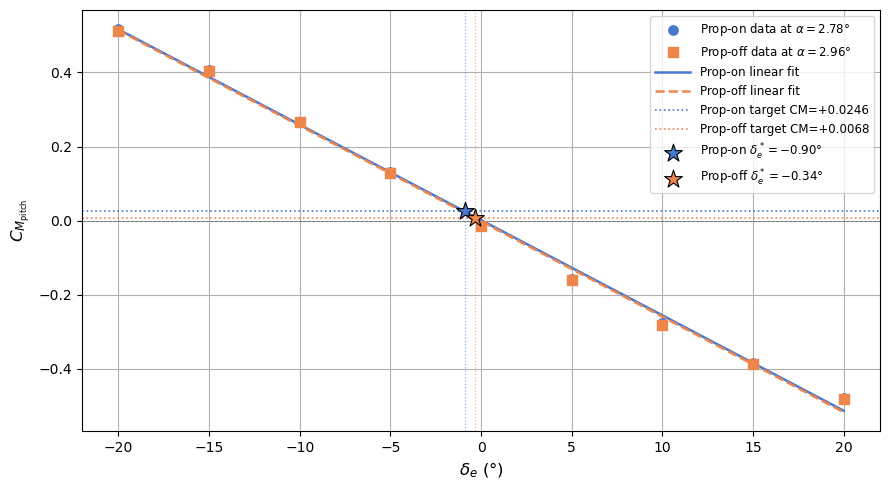

Saved trim_elev_CMpitch_vs_dE_comparison.png


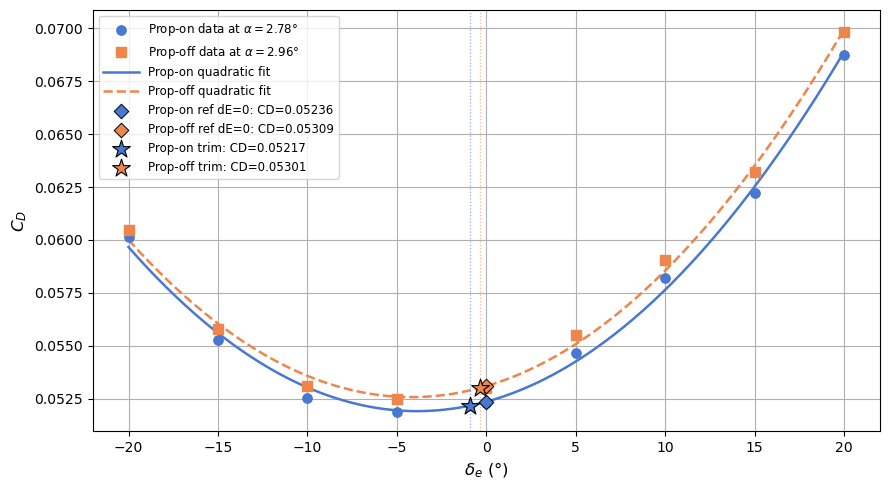

Saved trim_elev_CD_vs_dE_comparison.png


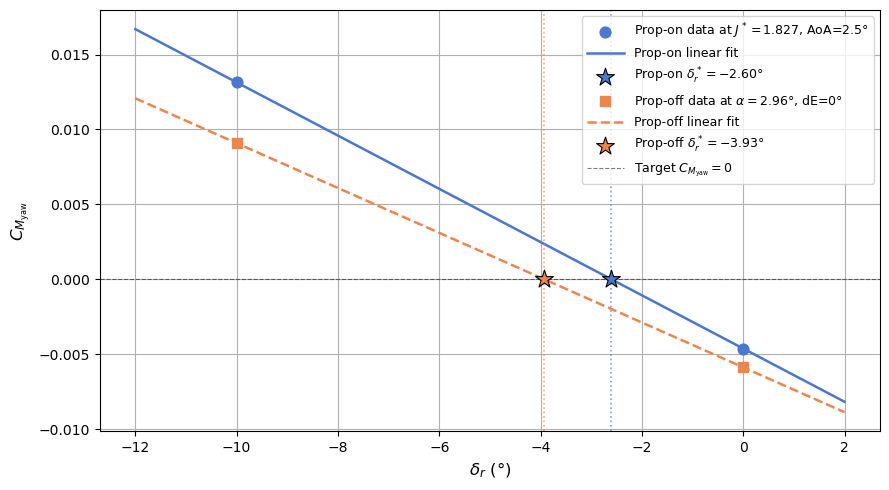

Saved trim_comparison_CMyaw_vs_dR.png


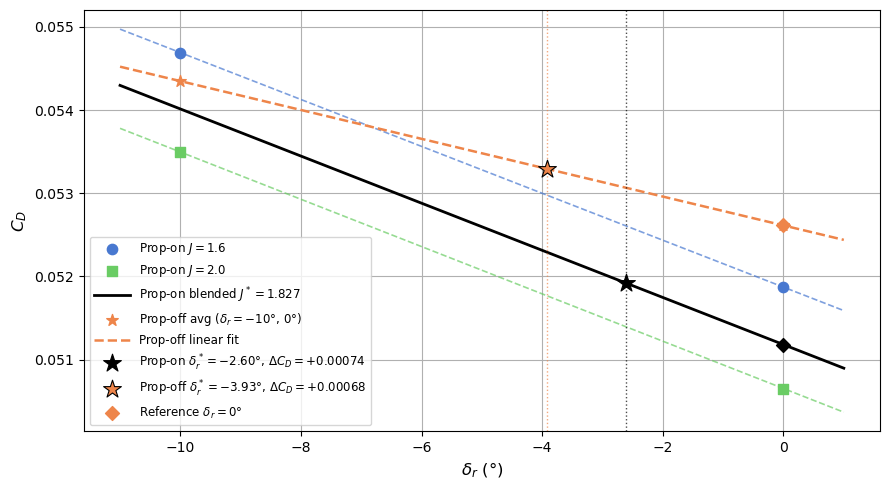

Saved trim_comparison_CD_vs_dR.png

                     ELEVATOR TRIM COMPARISON                     
Quantity                                   Prop-on      Prop-off
------------------------------------------------------------------
alpha_trim (°)                             +2.7804       +2.9621
                                        
CMpitch to cancel                        +0.024608     +0.006806
dCMpitch/ddE slope                       -0.025748     -0.025780
CMpitch at dE=0                          +0.001366     -0.001852
dE_trim (°)                                -0.9026       -0.3358
                                        
CD at dE=0                                0.052356      0.053094
CD at dE_trim                             0.052172      0.053014
ΔCD_elevator                             -0.000184     -0.000080

                      RUDDER TRIM COMPARISON                      
Quantity                                   Prop-on      Prop-off
------------------------------

In [1509]:
import numpy as np
import matplotlib.pyplot as plt

# ── Guards ────────────────────────────────────────────────────────────────────
for var in ["alpha_result", "alpha_trim_po", "delta_e_trim", "dE_trim_po",
            "target_cmpitch", "target_cmpitch_po",
            "cm_from_alpha_funcs_de", "po_cm_de_funcs",
            "cd_from_alpha_funcs_de", "po_cd_de_funcs",
            "delta_cd_elev", "delta_cd_elev_po",
            "delta_cd_rudder", "delta_cd_rudder_po",
            "dr_for_cmyaw_zero", "dR_trim_po",
            "cd_grand_total", "cd_total_trim_po",
            "J_star", "J_LO_DR", "J_HI_DR"]:
    if var not in globals():
        raise RuntimeError(f"'{var}' not found — run all trim cells first.")

alpha_on  = float(alpha_result)
alpha_off = float(alpha_trim_po)

# ── Shared dE axis ────────────────────────────────────────────────────────────
de_common = sorted(set(cm_from_alpha_funcs_de.keys()) & set(po_cm_de_funcs.keys()))
de_arr    = np.array(de_common, dtype=float)

cm_on  = np.array([cm_from_alpha_funcs_de[de](alpha_on)  for de in de_arr])
cm_off = np.array([po_cm_de_funcs[de](alpha_off)          for de in de_arr])
cd_on  = np.array([cd_from_alpha_funcs_de[de](alpha_on)  for de in de_arr])
cd_off = np.array([po_cd_de_funcs[de](alpha_off)          for de in de_arr])

coeffs_cm_on  = np.polyfit(de_arr, cm_on,  1);  fit_cm_on  = np.poly1d(coeffs_cm_on)
coeffs_cm_off = np.polyfit(de_arr, cm_off, 1);  fit_cm_off = np.poly1d(coeffs_cm_off)
coeffs_cd_on  = np.polyfit(de_arr, cd_on,  2);  fit_cd_on  = np.poly1d(coeffs_cd_on)
coeffs_cd_off = np.polyfit(de_arr, cd_off, 2);  fit_cd_off = np.poly1d(coeffs_cd_off)
de_plot = np.linspace(de_arr.min(), de_arr.max(), 300)

# ── Plot 1: CMpitch vs dE ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(de_arr, cm_on,  color=COLORS[0], marker="o", s=45, zorder=6,
           label=fr"Prop-on data at $\alpha={alpha_on:.2f}°$")
ax.scatter(de_arr, cm_off, color=COLORS[1], marker="s", s=45, zorder=6,
           label=fr"Prop-off data at $\alpha={alpha_off:.2f}°$")
ax.plot(de_plot, fit_cm_on(de_plot),  color=COLORS[0], ls="-",  lw=1.8, label="Prop-on linear fit")
ax.plot(de_plot, fit_cm_off(de_plot), color=COLORS[1], ls="--", lw=1.8, label="Prop-off linear fit")
ax.axhline(target_cmpitch,    color=COLORS[0], ls=":", lw=1.2,
           label=fr"Prop-on target CM={target_cmpitch:+.4f}")
ax.axhline(target_cmpitch_po, color=COLORS[1], ls=":", lw=1.2,
           label=fr"Prop-off target CM={target_cmpitch_po:+.4f}")
ax.scatter([delta_e_trim], [target_cmpitch],    color=COLORS[0], marker="*",
           s=180, edgecolors="k", linewidths=0.8, zorder=9,
           label=fr"Prop-on $\delta_e^*={delta_e_trim:+.2f}°$")
ax.scatter([dE_trim_po],   [target_cmpitch_po], color=COLORS[1], marker="*",
           s=180, edgecolors="k", linewidths=0.8, zorder=9,
           label=fr"Prop-off $\delta_e^*={dE_trim_po:+.2f}°$")
ax.axvline(delta_e_trim, color=COLORS[0], ls=":", lw=0.9, alpha=0.6)
ax.axvline(dE_trim_po,   color=COLORS[1], ls=":", lw=0.9, alpha=0.6)
ax.axhline(0, color="k", lw=0.6, ls="--", alpha=0.4)
ax.set_xlabel(r"$\delta_e$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{pitch}}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{M_\mathrm{pitch}}$ vs $\delta_e$: prop-on vs prop-off trim")
ax.legend(fontsize=8.5, handlelength=3)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "trim_elev_CMpitch_vs_dE_comparison.png"), dpi=SAVE_RES)
plt.show()
print("Saved trim_elev_CMpitch_vs_dE_comparison.png")

# ── Plot 2: CD vs dE ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(de_arr, cd_on,  color=COLORS[0], marker="o", s=45, zorder=6,
           label=fr"Prop-on data at $\alpha={alpha_on:.2f}°$")
ax.scatter(de_arr, cd_off, color=COLORS[1], marker="s", s=45, zorder=6,
           label=fr"Prop-off data at $\alpha={alpha_off:.2f}°$")
ax.plot(de_plot, fit_cd_on(de_plot),  color=COLORS[0], ls="-",  lw=1.8, label="Prop-on quadratic fit")
ax.plot(de_plot, fit_cd_off(de_plot), color=COLORS[1], ls="--", lw=1.8, label="Prop-off quadratic fit")
ax.scatter([0], [fit_cd_on(0)],  color=COLORS[0], marker="D", s=55, edgecolors="k",
           linewidths=0.7, zorder=8, label=fr"Prop-on ref dE=0: CD={fit_cd_on(0):.5f}")
ax.scatter([0], [fit_cd_off(0)], color=COLORS[1], marker="D", s=55, edgecolors="k",
           linewidths=0.7, zorder=8, label=fr"Prop-off ref dE=0: CD={fit_cd_off(0):.5f}")
ax.scatter([delta_e_trim], [fit_cd_on(delta_e_trim)],  color=COLORS[0], marker="*",
           s=180, edgecolors="k", linewidths=0.8, zorder=9,
           label=fr"Prop-on trim: CD={fit_cd_on(delta_e_trim):.5f}")
ax.scatter([dE_trim_po],   [fit_cd_off(dE_trim_po)],   color=COLORS[1], marker="*",
           s=180, edgecolors="k", linewidths=0.8, zorder=9,
           label=fr"Prop-off trim: CD={fit_cd_off(dE_trim_po):.5f}")
ax.axvline(delta_e_trim, color=COLORS[0], ls=":", lw=0.9, alpha=0.6)
ax.axvline(dE_trim_po,   color=COLORS[1], ls=":", lw=0.9, alpha=0.6)
ax.set_xlabel(r"$\delta_e$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(r"$C_D$ vs $\delta_e$: prop-on vs prop-off trim")
ax.legend(fontsize=8.5, handlelength=3)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "trim_elev_CD_vs_dE_comparison.png"), dpi=SAVE_RES)
plt.show()
print("Saved trim_elev_CD_vs_dE_comparison.png")

# ── Plot 3: CMyaw vs dR — how dR_trim is found for both cases ────────────────
# Prop-on: two points at J*, linear interpolation
cm_on_dr0   = float(cmyaw_from_j_funcs[0.0](J_star))
cm_on_drm10 = float(cmyaw_from_j_funcs[-10.0](J_star))
dr_on_pts   = np.array([-10.0, 0.0])
cy_on_pts   = np.array([cm_on_drm10, cm_on_dr0])
coeffs_cy_on = np.polyfit(dr_on_pts, cy_on_pts, 1)
fit_cy_on    = np.poly1d(coeffs_cy_on)

# Prop-off: two bracket points at alpha_trim_po
cy_off_m10 = float(po_cmyaw_dr_funcs[-10.0](alpha_off))
cy_off_0   = float(po_cmyaw_dr_funcs[0.0](alpha_off))
dr_off_pts = np.array([-10.0, 0.0])
cy_off_pts = np.array([cy_off_m10, cy_off_0])
coeffs_cy_off = np.polyfit(dr_off_pts, cy_off_pts, 1)
fit_cy_off    = np.poly1d(coeffs_cy_off)

x_cy = np.linspace(-12, 2, 300)

fig, ax = plt.subplots(figsize=(9, 5))
# Prop-on
ax.scatter(dr_on_pts, cy_on_pts, color=COLORS[0], marker="o", s=60, zorder=6,
           label=fr"Prop-on data at $J^*={J_star:.3f}$, AoA=2.5°")
ax.plot(x_cy, fit_cy_on(x_cy), color=COLORS[0], ls="-", lw=1.8,
        label="Prop-on linear fit")
ax.scatter([dr_for_cmyaw_zero], [0], color=COLORS[0], marker="*",
           s=180, edgecolors="k", linewidths=0.8, zorder=9,
           label=fr"Prop-on $\delta_r^*={dr_for_cmyaw_zero:+.2f}°$")
ax.axvline(dr_for_cmyaw_zero, color=COLORS[0], ls=":", lw=1.2, alpha=0.7)

# Prop-off
ax.scatter(dr_off_pts, cy_off_pts, color=COLORS[1], marker="s", s=60, zorder=6,
           label=fr"Prop-off data at $\alpha={alpha_off:.2f}°$, dE=0°")
ax.plot(x_cy, fit_cy_off(x_cy), color=COLORS[1], ls="--", lw=1.8,
        label="Prop-off linear fit")
ax.scatter([dR_trim_po], [0], color=COLORS[1], marker="*",
           s=180, edgecolors="k", linewidths=0.8, zorder=9,
           label=fr"Prop-off $\delta_r^*={dR_trim_po:+.2f}°$")
ax.axvline(dR_trim_po, color=COLORS[1], ls=":", lw=1.2, alpha=0.7)

ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5, label=r"Target $C_{M_\mathrm{yaw}}=0$")
ax.set_xlabel(r"$\delta_r$ (°)")
ax.set_ylabel(r"$C_{M_\mathrm{yaw}}$")
if SHOW_TITLE:
    ax.set_title(r"$C_{M_\mathrm{yaw}}$ vs $\delta_r$: prop-on vs prop-off yaw trim")
ax.legend(fontsize=9, handlelength=3)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "trim_comparison_CMyaw_vs_dR.png"), dpi=SAVE_RES)
plt.show()
print("Saved trim_comparison_CMyaw_vs_dR.png")

# ── Plot 4: CD vs dR — new method (prop-on J-blended, prop-off linear bracket)
DR_VALS   = [-10.0, 0.0]
j_markers = {J_LO_DR: "o", J_HI_DR: "s"}
j_colors  = {J_LO_DR: COLORS[0], J_HI_DR: COLORS[2]}

# Prop-on raw points per J
df_on_dr = df[
    (df["V_round"]   == 40) &
    (df["AoS_round"] == 0)  &
    (df["AoA_round"] == 2.5) &
    (df["dR"].isin(DR_VALS)) &
    (df["J_round"].isin([J_LO_DR, J_HI_DR]))
][["dR", "J_round", "CD_FINAL"]].sort_values(["J_round", "dR"])

# Prop-off bracket averaged
df_off_br = df_prop_off[
    (df_prop_off["V_round"]   == 40)  &
    (df_prop_off["AoS_round"] == 0)   &
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["dE"]        == 0)   &
    (df_prop_off["dR"].isin(DR_VALS))
].groupby("dR")["CD_FINAL"].mean().reset_index()
x_off_br = df_off_br["dR"].to_numpy(dtype=float)
y_off_br  = df_off_br["CD_FINAL"].to_numpy(dtype=float)
coeffs_off_br = np.polyfit(x_off_br, y_off_br, 1)
fit_off_br    = np.poly1d(coeffs_off_br)

# Prop-on J-blended line
w = (J_star - J_LO_DR) / (J_HI_DR - J_LO_DR)
cd_results_dr = {}
for j_val, grp in df_on_dr.groupby("J_round"):
    x = grp["dR"].to_numpy(dtype=float)
    y = grp["CD_FINAL"].to_numpy(dtype=float)
    c = np.polyfit(x, y, 1)
    cd_results_dr[j_val] = c

slope_blend     = (1-w)*cd_results_dr[J_LO_DR][0] + w*cd_results_dr[J_HI_DR][0]
intercept_blend = (1-w)*cd_results_dr[J_LO_DR][1] + w*cd_results_dr[J_HI_DR][1]

x_fit = np.linspace(-11, 1, 300)

# CD values at trim points
cd_on_trim  = slope_blend * dr_for_cmyaw_zero + intercept_blend
cd_on_ref   = intercept_blend
cd_off_trim = float(fit_off_br(dR_trim_po))
cd_off_ref  = float(fit_off_br(0.0))

fig, ax = plt.subplots(figsize=(9, 5))

# Per-J scatter and fits
for j_val, grp in df_on_dr.groupby("J_round"):
    c_line = j_colors[j_val]
    mk     = j_markers[j_val]
    x = grp["dR"].to_numpy(dtype=float)
    y = grp["CD_FINAL"].to_numpy(dtype=float)
    ax.scatter(x, y, color=c_line, marker=mk, s=55, zorder=6,
               label=fr"Prop-on $J={j_val}$")
    coeffs_j = cd_results_dr[j_val]
    ax.plot(x_fit, np.polyval(coeffs_j, x_fit), color=c_line, ls="--", lw=1.2, alpha=0.7)

# Blended J* line
ax.plot(x_fit, slope_blend * x_fit + intercept_blend,
        color="k", ls="-", lw=2,
        label=fr"Prop-on blended $J^*={J_star:.3f}$")

# Prop-off bracket points and fit
ax.scatter(x_off_br, y_off_br, color=COLORS[1], marker="*", s=75, zorder=6,
           label=r"Prop-off avg ($\delta_r=-10°$, $0°$)")
ax.plot(x_fit, fit_off_br(x_fit), color=COLORS[1], ls="--", lw=1.8,
        label="Prop-off linear fit")

# Trim points
ax.scatter([dr_for_cmyaw_zero], [cd_on_trim], color="k", marker="*",
           s=180, edgecolors="k", linewidths=0.8, zorder=9,
           label=fr"Prop-on $\delta_r^*={dr_for_cmyaw_zero:+.2f}°$, $\Delta C_D={delta_cd_rudder:+.5f}$")
ax.scatter([dR_trim_po], [cd_off_trim], color=COLORS[1], marker="*",
           s=180, edgecolors="k", linewidths=0.8, zorder=9,
           label=fr"Prop-off $\delta_r^*={dR_trim_po:+.2f}°$, $\Delta C_D={delta_cd_rudder_po:+.5f}$")
ax.scatter([0], [cd_on_ref],  color="k",        marker="D", s=50, zorder=8)
ax.scatter([0], [cd_off_ref], color=COLORS[1],  marker="D", s=50, zorder=8,
           label=r"Reference $\delta_r=0°$")

ax.axvline(dr_for_cmyaw_zero, color="k",       ls=":", lw=1.0, alpha=0.7)
ax.axvline(dR_trim_po,        color=COLORS[1], ls=":", lw=1.0, alpha=0.7)
ax.set_xlabel(r"$\delta_r$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(
        r"$C_D$ vs $\delta_r$: prop-on (J-blended) and prop-off (bracket linear)"
        "\n"
        r"AoA=2.5°, $V=40$ m/s, AoS=0°, dE=0°"
    )
ax.legend(fontsize=8.5, handlelength=3)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "trim_comparison_CD_vs_dR.png"), dpi=SAVE_RES)
plt.show()
print("Saved trim_comparison_CD_vs_dR.png")

# ── Print summaries ───────────────────────────────────────────────────────────
print()
print("=" * 66)
print(f"{'ELEVATOR TRIM COMPARISON':^66}")
print("=" * 66)
print(f"{'Quantity':<36}  {'Prop-on':>12}  {'Prop-off':>12}")
print("-" * 66)
rows = [
    ("alpha_trim (°)",            f"{alpha_on:>+12.4f}",              f"{alpha_off:>+12.4f}"),
    ("",                          "",                                   ""),
    ("CMpitch to cancel",         f"{target_cmpitch:>+12.6f}",         f"{target_cmpitch_po:>+12.6f}"),
    ("dCMpitch/ddE slope",        f"{coeffs_cm_on[0]:>+12.6f}",       f"{coeffs_cm_off[0]:>+12.6f}"),
    ("CMpitch at dE=0",           f"{fit_cm_on(0):>+12.6f}",           f"{fit_cm_off(0):>+12.6f}"),
    ("dE_trim (°)",               f"{delta_e_trim:>+12.4f}",           f"{dE_trim_po:>+12.4f}"),
    ("",                          "",                                   ""),
    ("CD at dE=0",                f"{fit_cd_on(0):>12.6f}",            f"{fit_cd_off(0):>12.6f}"),
    ("CD at dE_trim",             f"{fit_cd_on(delta_e_trim):>12.6f}", f"{fit_cd_off(dE_trim_po):>12.6f}"),
    ("ΔCD_elevator",              f"{delta_cd_elev:>+12.6f}",          f"{delta_cd_elev_po:>+12.6f}"),
]
for label, v_on, v_off in rows:
    print(f"{label:<36}  {v_on}  {v_off}")
print("=" * 66)

print()
print("=" * 66)
print(f"{'RUDDER TRIM COMPARISON':^66}")
print("=" * 66)
print(f"{'Quantity':<36}  {'Prop-on':>12}  {'Prop-off':>12}")
print("-" * 66)
rudder_rows = [
    ("CMyaw to cancel",
     f"{-cm_on_dr0:>+12.6f}",
     f"{-cy_off_0:>+12.6f}"),
    ("dR_trim (°)",
     f"{dr_for_cmyaw_zero:>+12.4f}",
     f"{dR_trim_po:>+12.4f}"),
    ("CD source",
     f"{'prop-on J-blend':>12}",
     f"{'prop-off lin':>12}"),
    ("ΔCD_rudder",
     f"{delta_cd_rudder:>+12.6f}",
     f"{delta_cd_rudder_po:>+12.6f}"),
]
for label, v_on, v_off in rudder_rows:
    print(f"{label:<36}  {v_on}  {v_off}")
print("=" * 66)

# ── Full side-by-side budget ───────────────────────────────────────────────────
def row(label, v_on, v_off, fmt_on, fmt_off):
    return f"{label:<38}  {fmt_on.format(v_on):>13}  {fmt_off.format(v_off):>13}"

def sep():
    print(f"{'':38}  {'':13}  {'':13}")

print()
print("=" * 70)
print(f"{'FULL TRIM SUMMARY':^70}")
print(f"{'CL = ' + str(CL_TARGET) + '   V = ' + str(TRIM_V) + ' m/s   AoS = 0°':^70}")
print("=" * 70)
print(f"{'Quantity':<38}  {'Prop-on':>13}  {'Prop-off':>13}")
print("-" * 70)

print(f"  {'--- Trim state ---':<36}")
print(row("alpha_trim (°)",     alpha_on,       alpha_off,       "{:+.4f}°", "{:+.4f}°"))
print(f"  {'J*':<38}  {J_star:>13.4f}  {'N/A':>13}")
sep()

print(f"  {'--- Baseline CD (dR=0, dE=0) ---':<36}")
print(row("CD_base",            cd_aero,        cd_trim_po_base, "{:.6f}", "{:.6f}"))
sep()

print(f"  {'--- Elevator trim ---':<36}")
print(row("CMpitch to cancel",  target_cmpitch, target_cmpitch_po, "{:+.6f}", "{:+.6f}"))
print(row("dE_trim (°)",        delta_e_trim,   dE_trim_po,      "{:+.4f}°", "{:+.4f}°"))
print(row("ΔCD_elevator",       delta_cd_elev,  delta_cd_elev_po, "{:+.6f}", "{:+.6f}"))
sep()

print(f"  {'--- Rudder trim ---':<36}")
print(row("CMyaw to cancel",    -cm_on_dr0,     -cy_off_0,       "{:+.6f}", "{:+.6f}"))
print(row("dR_trim (°)",        dr_for_cmyaw_zero, dR_trim_po,   "{:+.4f}°", "{:+.4f}°"))
print(row("ΔCD_rudder",         delta_cd_rudder, delta_cd_rudder_po, "{:+.6f}", "{:+.6f}"))
sep()

print(f"  {'--- CD budget ---':<36}")
print(row("CD_base",            cd_aero,        cd_trim_po_base, "{:.6f}", "{:.6f}"))
print(row("ΔCD_elevator",       delta_cd_elev,  delta_cd_elev_po, "{:+.6f}", "{:+.6f}"))
print(row("ΔCD_rudder",         delta_cd_rudder, delta_cd_rudder_po, "{:+.6f}", "{:+.6f}"))
print("-" * 70)
print(row("ΔCD_total",
          cd_grand_total - cd_aero,
          cd_total_trim_po - cd_trim_po_base,
          "{:+.6f}", "{:+.6f}"))
print(row("CD_final",           cd_grand_total, cd_total_trim_po, "{:.6f}", "{:.6f}"))
print("=" * 70)


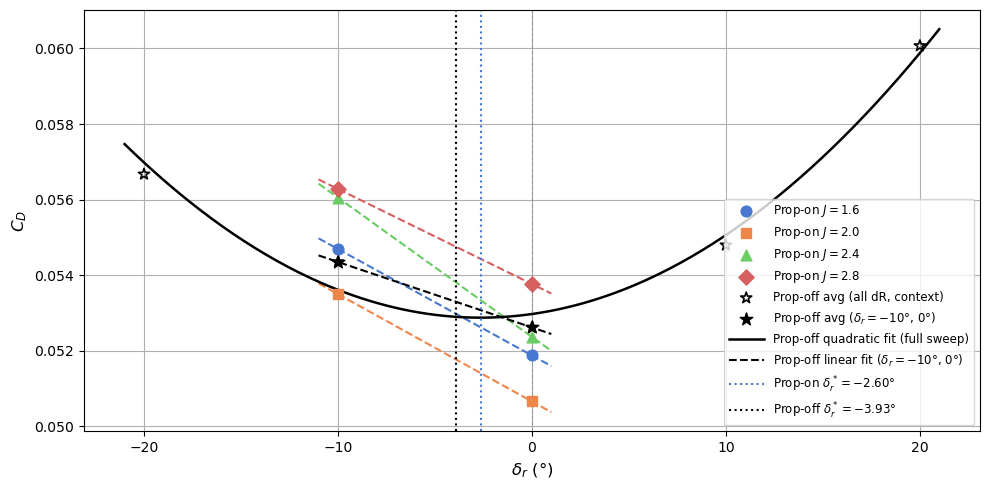

Saved CD_vs_dR_propon_propoff_bracket_and_quad_AoA2p5.png


In [1510]:
import numpy as np
import matplotlib.pyplot as plt

# ── Filter to dR = -10 and 0 only ────────────────────────────────────────────
DR_VALS = [-10.0, 0.0]

df_on_dr = df[
    (df["V_round"]   == 40) &
    (df["AoS_round"] == 0)  &
    (df["AoA_round"] == 2.5) &
    (df["dR"].isin(DR_VALS))
][["dR", "J_round", "CD_FINAL"]].sort_values(["J_round", "dR"])

# Prop-off: full dR sweep for quadratic fit (dE=0, AoA=2.5)
df_off_full = df_prop_off[
    (df_prop_off["V_round"]   == 40)  &
    (df_prop_off["AoS_round"] == 0)   &
    (df_prop_off["AoA_round"] == 2.5) &
    (df_prop_off["dE"]        == 0)
][["dR", "CD_FINAL"]].sort_values("dR")

# Average repeated dR points for prop-off
df_off_avg = df_off_full.groupby("dR")["CD_FINAL"].mean().reset_index()

# Prop-off bracket points (dR=-10, 0) averaged
df_off_bracket = df_off_avg[df_off_avg["dR"].isin(DR_VALS)]
x_off_br = df_off_bracket["dR"].to_numpy(dtype=float)
y_off_br = df_off_bracket["CD_FINAL"].to_numpy(dtype=float)

# Prop-off quadratic fit (full dR sweep, averaged)
x_off_full = df_off_avg["dR"].to_numpy(dtype=float)
y_off_full = df_off_avg["CD_FINAL"].to_numpy(dtype=float)
coeffs_off_quad = np.polyfit(x_off_full, y_off_full, 2)
fit_off_quad = np.poly1d(coeffs_off_quad)

# Prop-off linear fit (bracket only, averaged)
coeffs_off_lin = np.polyfit(x_off_br, y_off_br, 1)
fit_off_lin = np.poly1d(coeffs_off_lin)

x_fit = np.linspace(-11, 1, 300)
x_fit_quad = np.linspace(df_off_avg["dR"].min() - 1, df_off_avg["dR"].max() + 1, 300)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

j_markers = {1.6: "o", 2.0: "s", 2.4: "^", 2.8: "D"}

# Prop-on: scatter + linear fit per J (dR=-10 and 0 only, single points so no averaging needed)
for idx, (j_val, grp) in enumerate(df_on_dr.groupby("J_round")):
    x = grp["dR"].to_numpy(dtype=float)
    y = grp["CD_FINAL"].to_numpy(dtype=float)
    c = COLORS[idx % len(COLORS)]
    mk = j_markers.get(j_val, "o")

    ax.scatter(x, y, color=c, marker=mk, s=60, zorder=6,
               label=fr"Prop-on $J={j_val}$")

    if len(x) == 2:
        coeffs = np.polyfit(x, y, 1)
        ax.plot(x_fit, np.polyval(coeffs, x_fit),
                color=c, ls="--", lw=1.5)

# Prop-off: all averaged scatter points (context, hollow)
ax.scatter(x_off_full, y_off_full, color="k", marker="*", s=70,
           facecolors="none", edgecolors="k", linewidths=1.2,
           zorder=5, label="Prop-off avg (all dR, context)")

# Prop-off: bracket points filled
ax.scatter(x_off_br, y_off_br, color="k", marker="*", s=90,
           zorder=7, label=r"Prop-off avg ($\delta_r=-10°$, $0°$)")

# Prop-off: quadratic fit through full sweep
ax.plot(x_fit_quad, fit_off_quad(x_fit_quad),
        color="k", ls="-", lw=1.8,
        label="Prop-off quadratic fit (full sweep)")

# Prop-off: linear fit through bracket points only
ax.plot(x_fit, fit_off_lin(x_fit),
        color="k", ls="--", lw=1.5,
        label=r"Prop-off linear fit ($\delta_r=-10°$, $0°$)")

# Trim dR markers
if "dr_for_cmyaw_zero" in globals() and np.isfinite(dr_for_cmyaw_zero):
    ax.axvline(dr_for_cmyaw_zero, color=COLORS[0], ls=":", lw=1.5,
               label=fr"Prop-on $\delta_r^*={dr_for_cmyaw_zero:+.2f}°$")
if "dR_trim_po" in globals() and np.isfinite(dR_trim_po):
    ax.axvline(dR_trim_po, color="k", ls=":", lw=1.5,
               label=fr"Prop-off $\delta_r^*={dR_trim_po:+.2f}°$")

ax.axvline(0, color="grey", ls="--", lw=0.8, alpha=0.5)
ax.set_xlabel(r"$\delta_r$ (°)")
ax.set_ylabel(r"$C_D$")
if SHOW_TITLE:
    ax.set_title(
        r"$C_D$ vs $\delta_r$: prop-on (bracket only) and prop-off (full sweep + bracket)"
        "\n"
        r"($V=40$ m/s, AoS=0°, AoA=2.5°, dE=0°)"
    )
ax.legend(fontsize=8.5, handlelength=3)
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "CD_vs_dR_propon_propoff_bracket_and_quad_AoA2p5.png"), dpi=SAVE_RES)
plt.show()
print("Saved CD_vs_dR_propon_propoff_bracket_and_quad_AoA2p5.png")